# Statistics for Michel electron candidate

# beam DATA 28891

### Created by Shu, 202510---

### Based on new20251205; the main difference is #opWVF>=3 instead of 4

### Beam events removed

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import os

# ------------------------------------------------------------
# 1️⃣ Define which dates to include
# ------------------------------------------------------------
dates = ["202602"]  # ✅ modify as needed

coinNum = []     # waveform coincidence numbers


# ------------------------------------------------------------
# 2️⃣ Read waveform coincidence counts
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_wvfCoin_count{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split(":")
            if len(parts) >= 2:
                try:
                    number = int(parts[1].strip())
                    coinNum.append(number)
                except ValueError:
                    print(f"[WARN] Could not convert '{parts[1].strip()}' in {fname} to an integer.")








# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------


print("Track candidates (TPC cut)  : 34472")
print("Track candidates with NO wvf: 5000")
print("Number of track candidates  :", len(coinNum))

coinNum.extend([0] * (5000))



Track candidates (TPC cut)  : 34472
Track candidates with NO wvf: 5000
Number of track candidates  : 31625



Candidates with #opWvf>=3:  25843 / 36625 (70.56%)


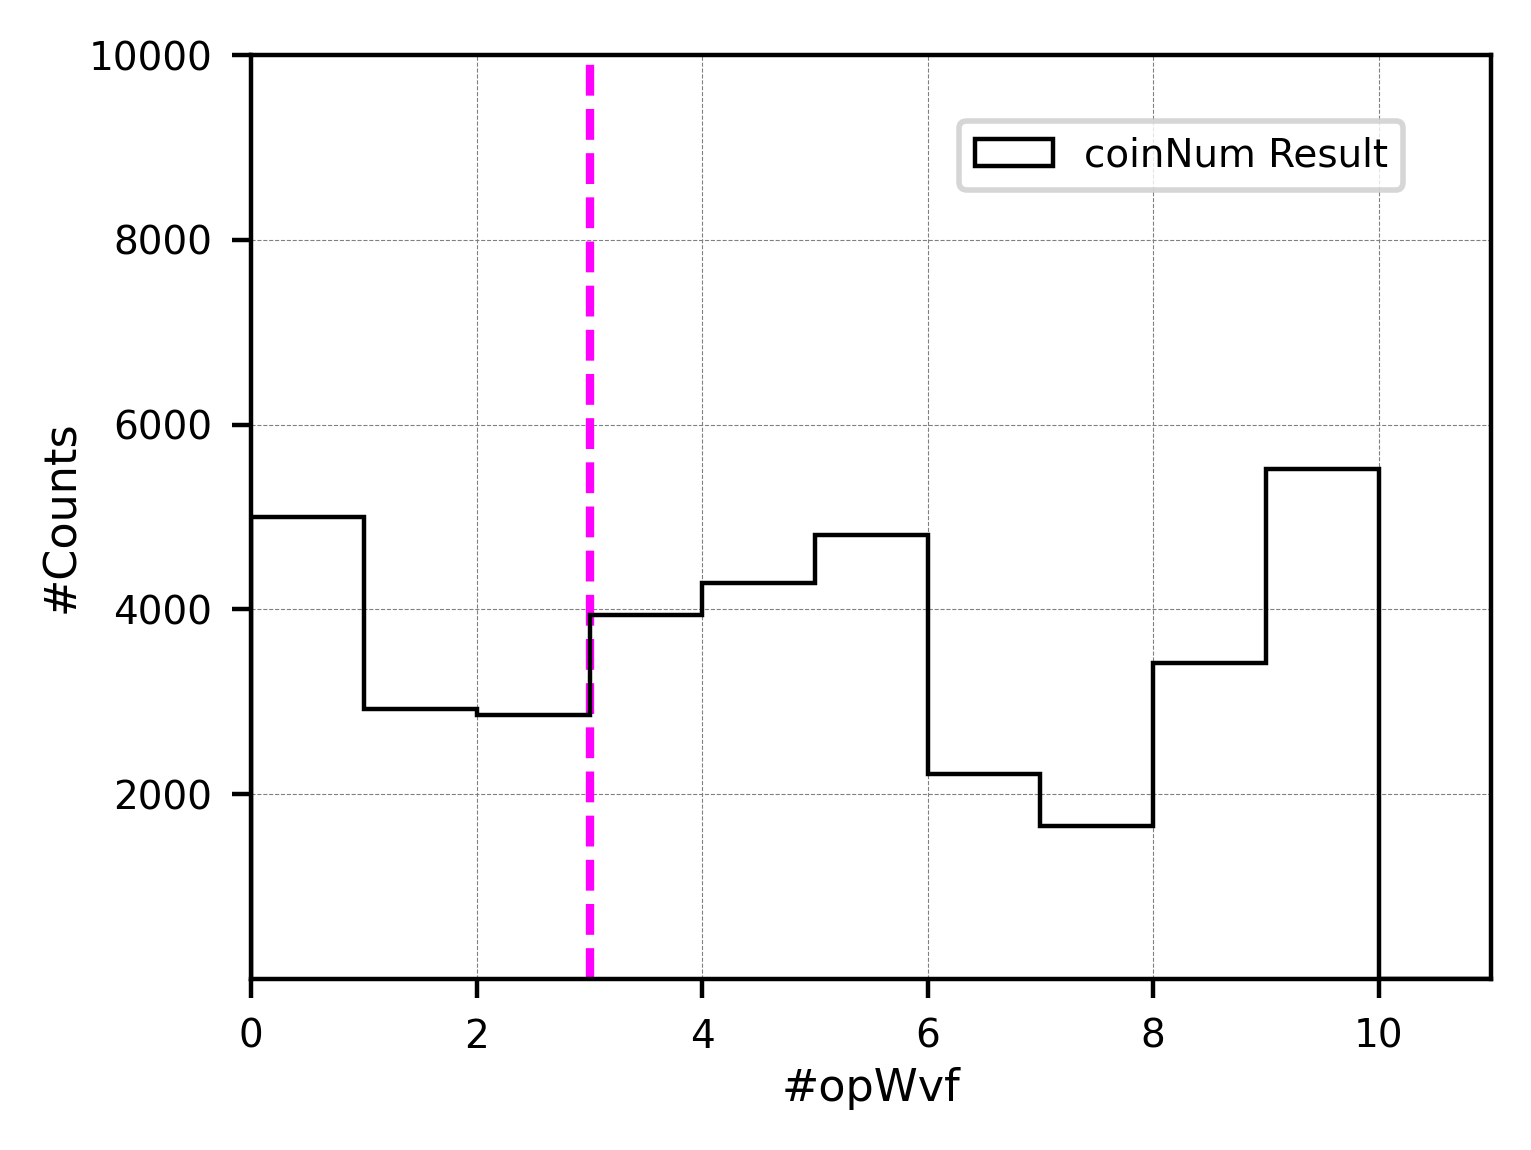

In [67]:
#Apply preliminary cut #opWvf >=3:=====================
coinNum_cut4 = []
coinNum_trueE_cut4 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]

    if coin >=3:
        coinNum_cut4.append(coin)

print("\nCandidates with #opWvf>=3: ", len(coinNum_cut4), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut4)/len(coinNum)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 15000], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 3) (This can be taken as "PDS Cut 1")

In [68]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": int(date)}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------
#dates = ["20251205"]

muon_files   = [f"./statResult_pds/muon_total_{d}.txt" for d in dates]
michel_files = [f"./statResult_pds/michel_total_{d}.txt" for d in dates]
third_files  = [f"./statResult_pds/third_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, kind="muon")
michel_records = read_total_files(michel_files, dates, kind="michel")
third_records  = read_total_files(third_files, dates, kind="third")

# --- plain text attributes ---
posX     = read_plain_files([f"./statResult_pds/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./statResult_pds/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./statResult_pds/posZ_extract_{d}.txt" for d in dates])
miScore  = read_plain_files([f"./statResult_pds/michelScore_extract_{d}.txt" for d in dates])
miHits   = read_plain_files([f"./statResult_pds/michelHits_extract_{d}.txt" for d in dates], cast_type=int)



# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity

    ms = ev.michel_score
    mh = ev.michel_hits

    if muIntensity > 0.3  and miIntensity > -0.1 and ms > 0.3 and mh > 3:#mu & mi are cuts in following block already!
        events_reco_initial.append(ev)


print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))






Very initial dataset: 24618

Example Event (index 0):
  muon_time           : 60
  michel_time         : 175
  third_time          : 0
  muon_intensity      : 4.48688
  michel_intensity    : 0.527097
  third_intensity     : 0.0
  posX                : -107.516
  posY                : 40.4398
  posZ                : 421.835
  eventID             : 100013
  trackID             : 3
  date                : 202602
  mu_leftTurn         : 34
  mu_rightTurn        : 79
  mu_leftHeight       : 6.16863
  mu_rightHeight      : 4.48688
  mi_leftTurn         : 146
  mi_rightTurn        : 194
  mi_leftHeight       : 0.613875
  mi_rightHeight      : 0.527097
  th_leftTurn         : 0
  th_rightTurn        : 0
  th_leftHeight       : 0.0
  th_rightHeight      : 0.0
  michel_score        : 0.846951
  michel_hits         : 15

Dataset after initial intensity-cut----------------------
Michel initial dataset   :  19929


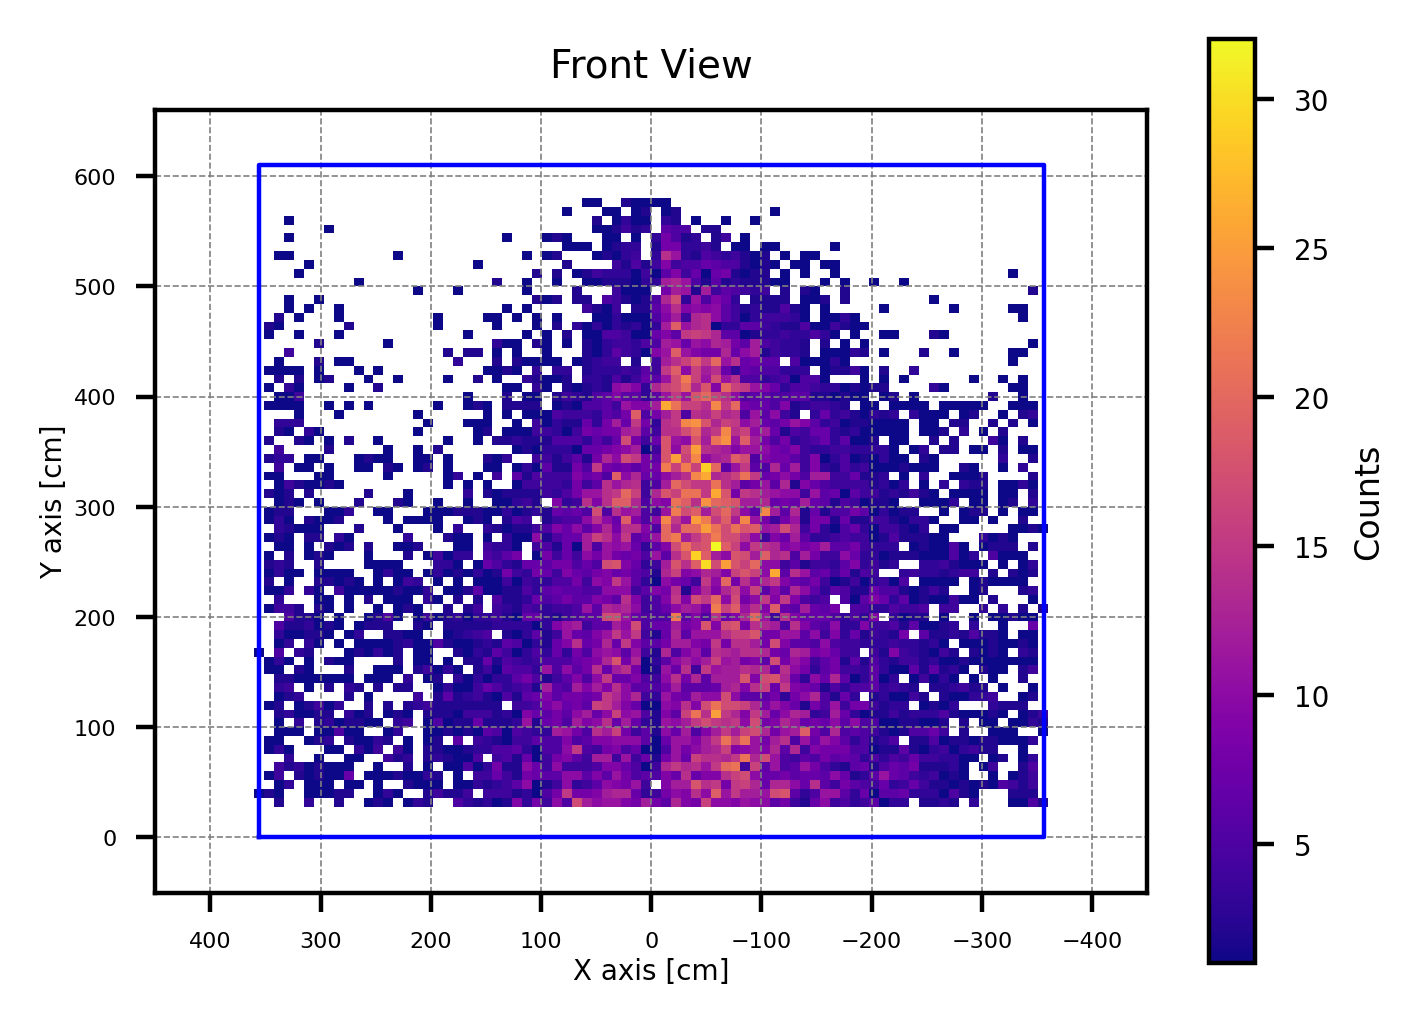

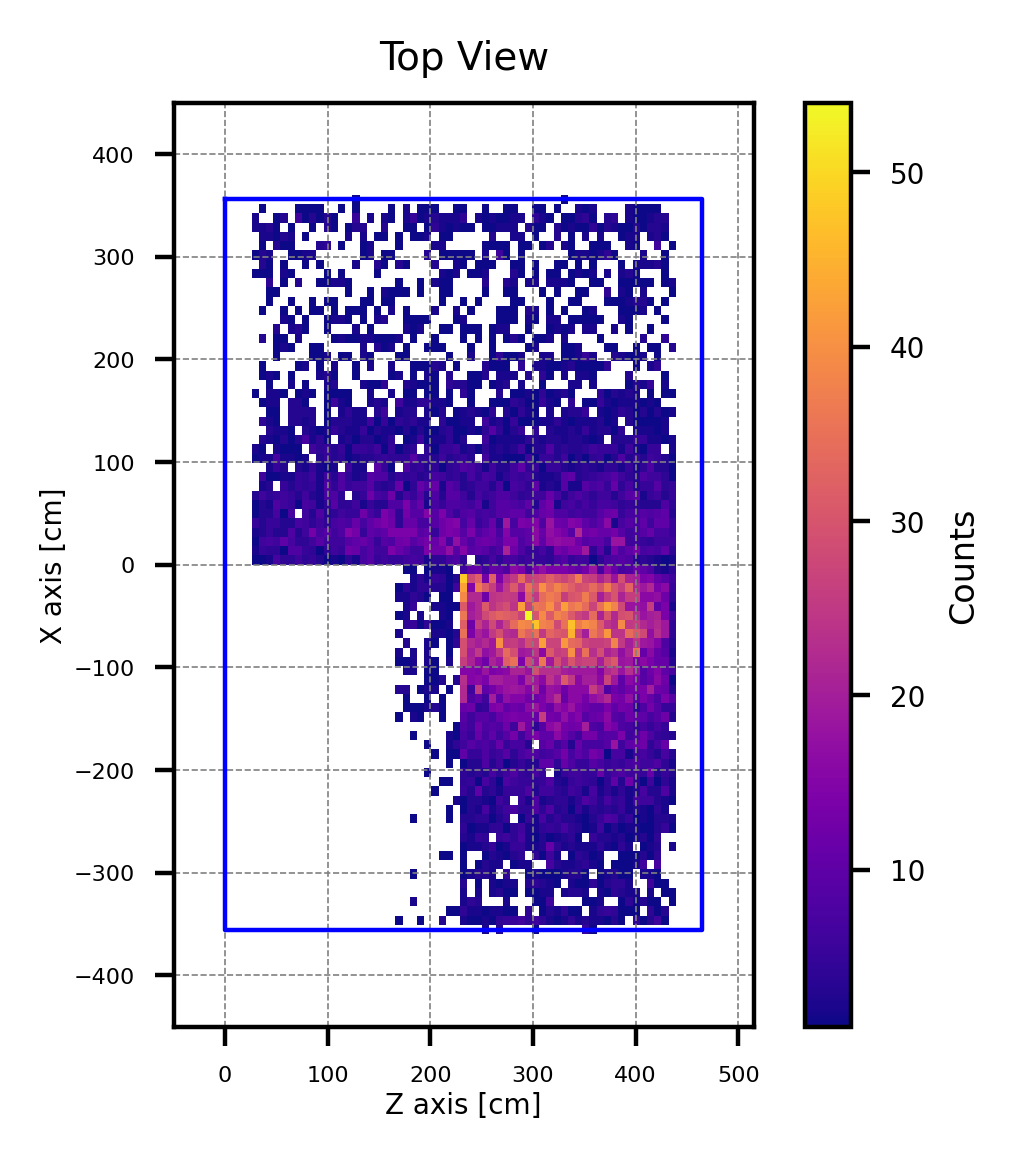


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  13518 (67.83%)
# of X >= 0:  6411 (32.17%)


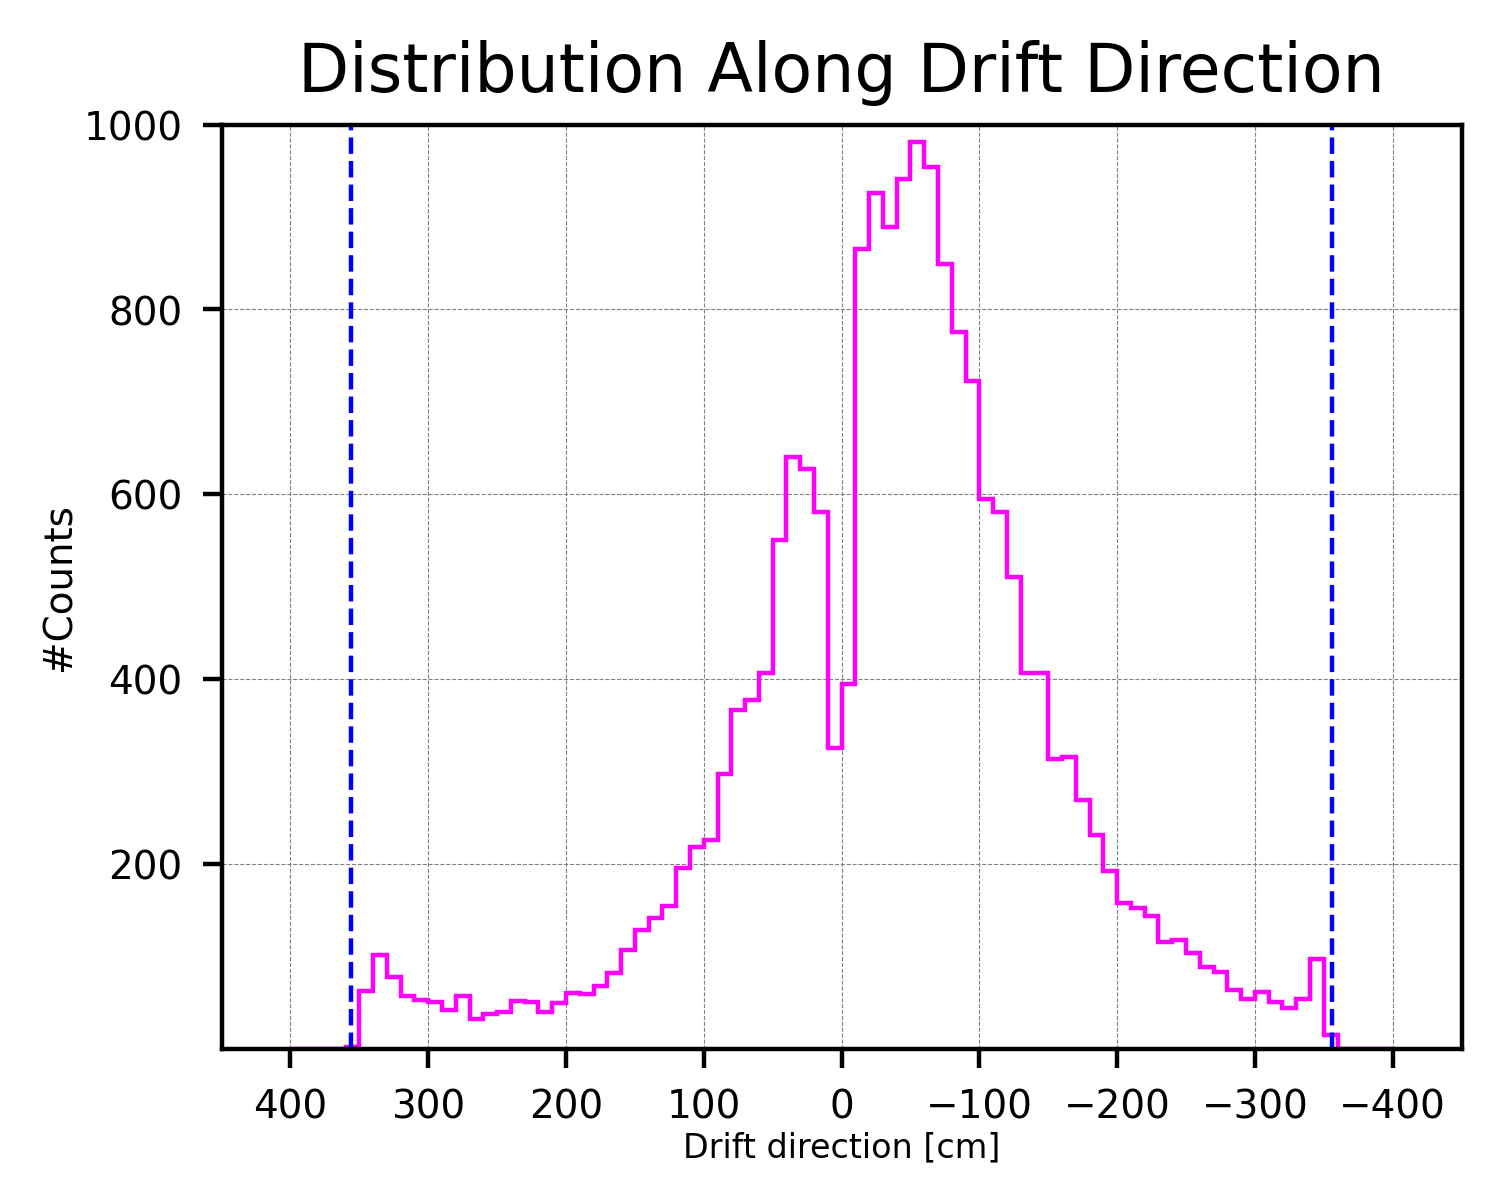

In [69]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))      




#============================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(posX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


plt.xlim(-450, 450)
plt.xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylabel('#Counts', labelpad=1, fontsize=7)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution Along Drift Direction', fontsize=12)
plt.show()  






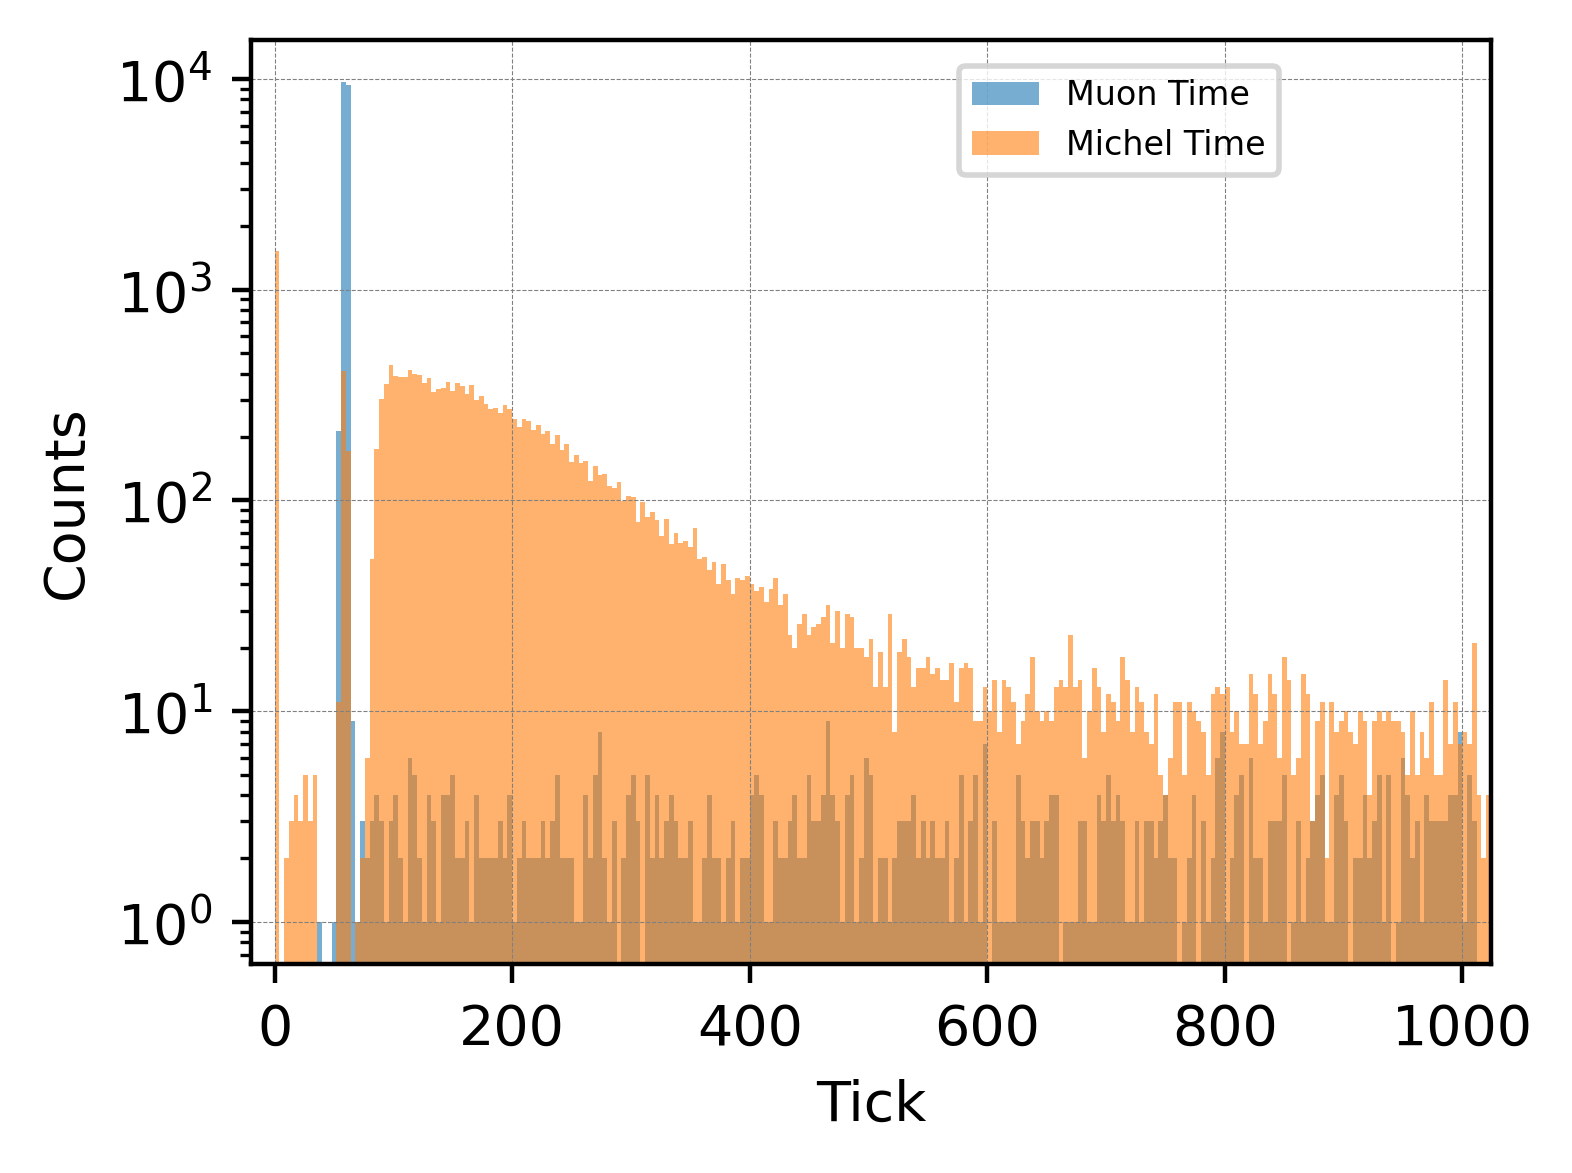

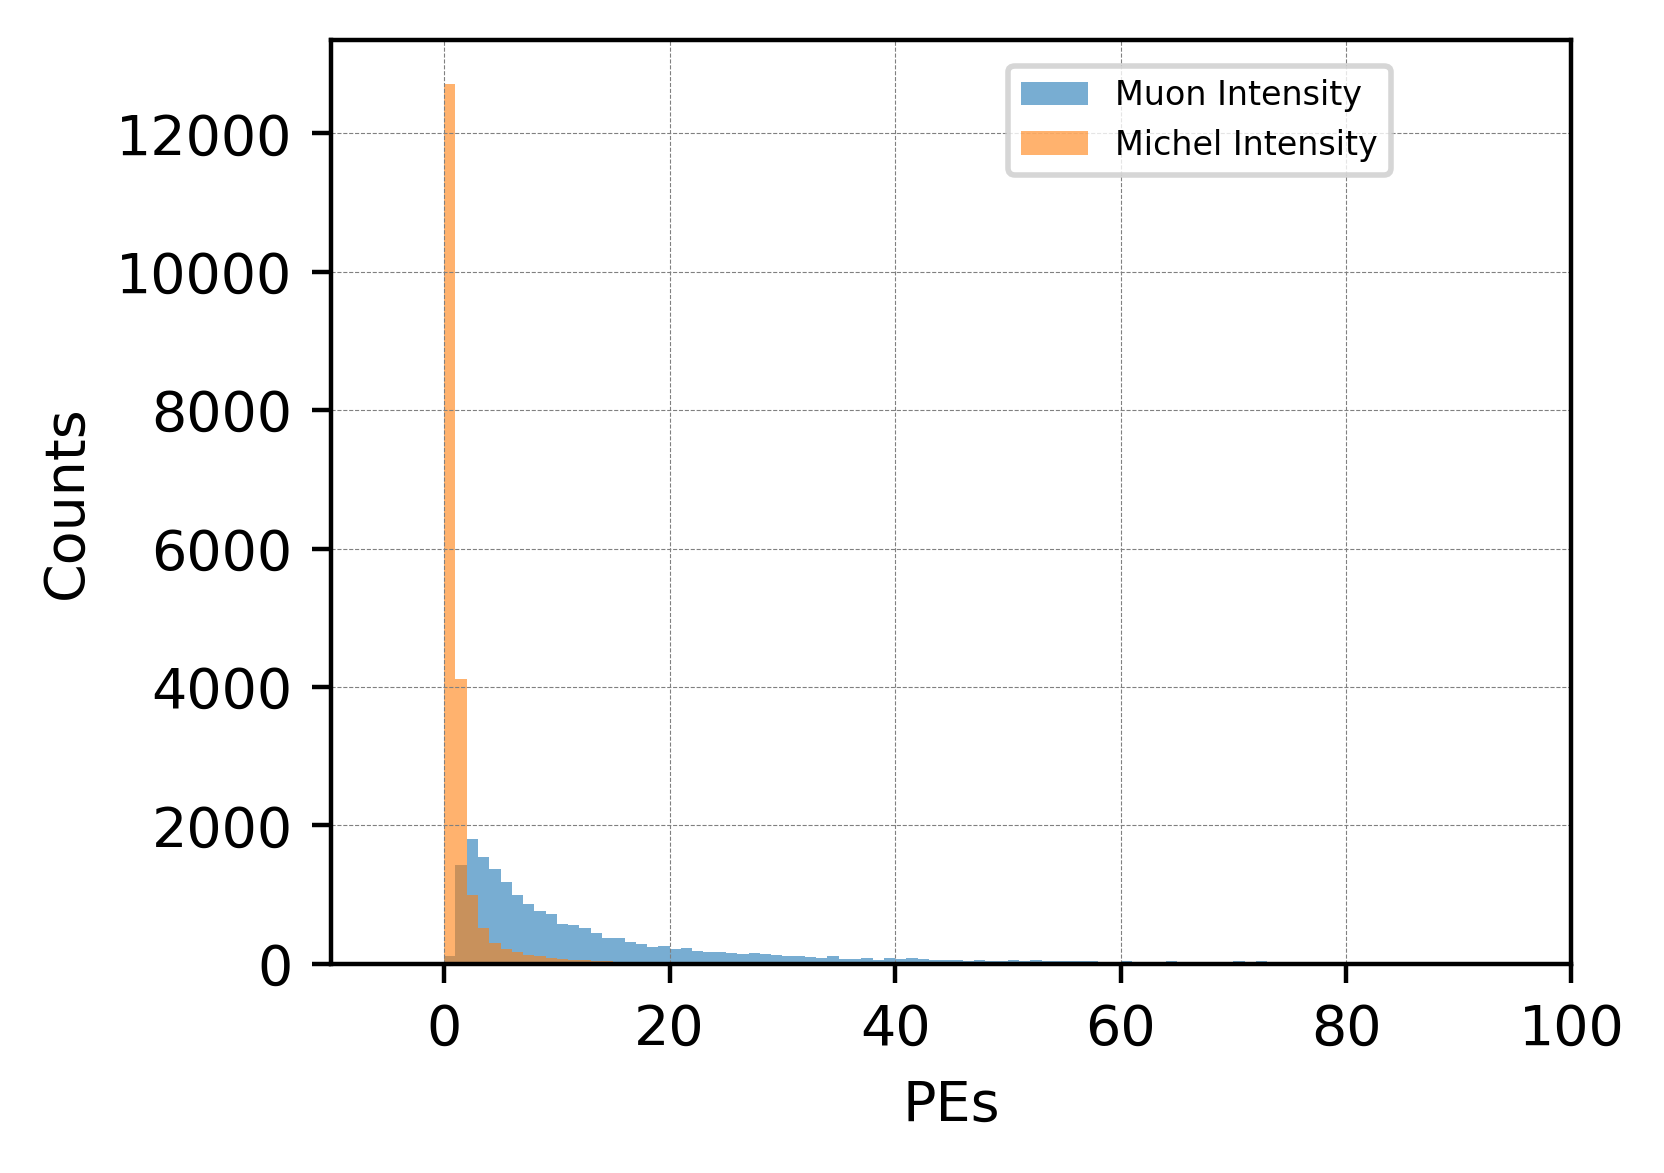

In [70]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]



#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
#plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
#plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









 





<br />
<br />
<br />
<br />


### Purification / cut 2: remove abnormal muon signals (constrain muTime to [50, 65])

Muon events selection (mu peak constrained to [50, 65]):
Updated Muon events:  19286 / 19929 (96.77%)
Length of time_difference (Updated):  19286
Adding muTIme < miTime:
Updated Muon events:  17742 / 19929 (89.03%)


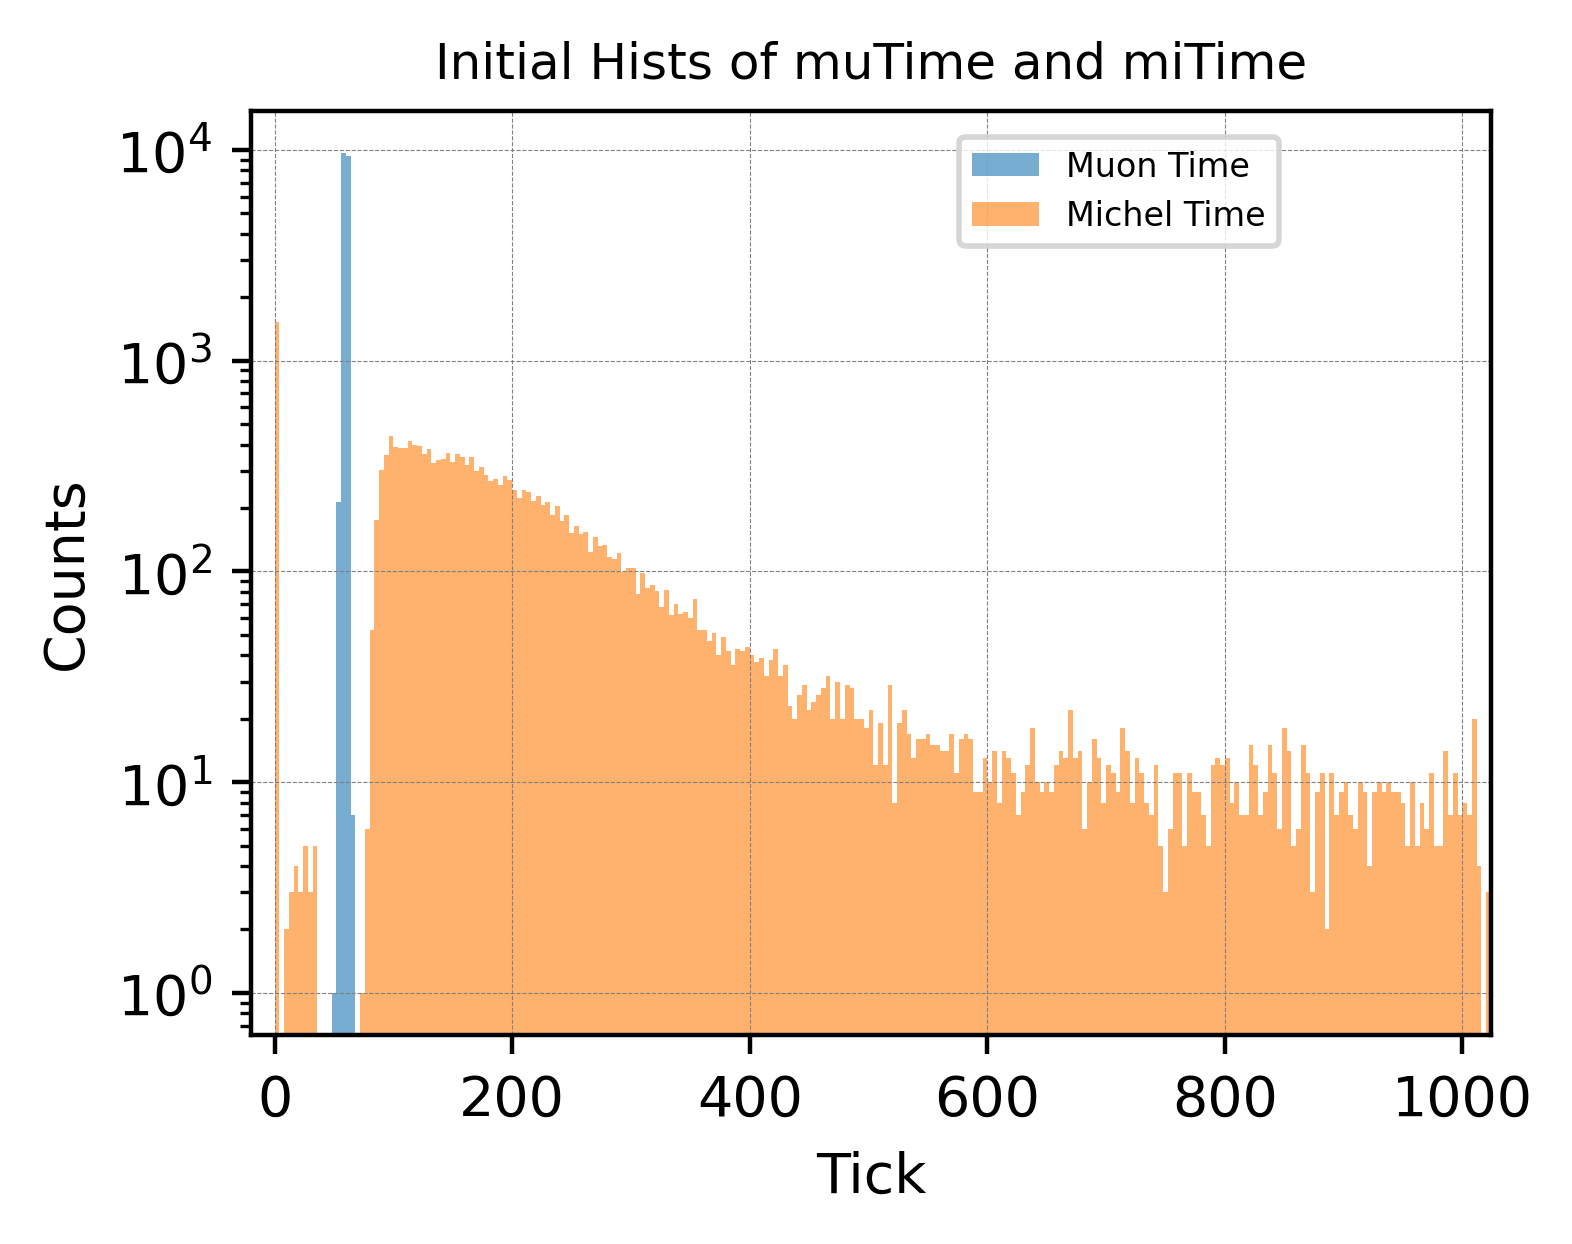

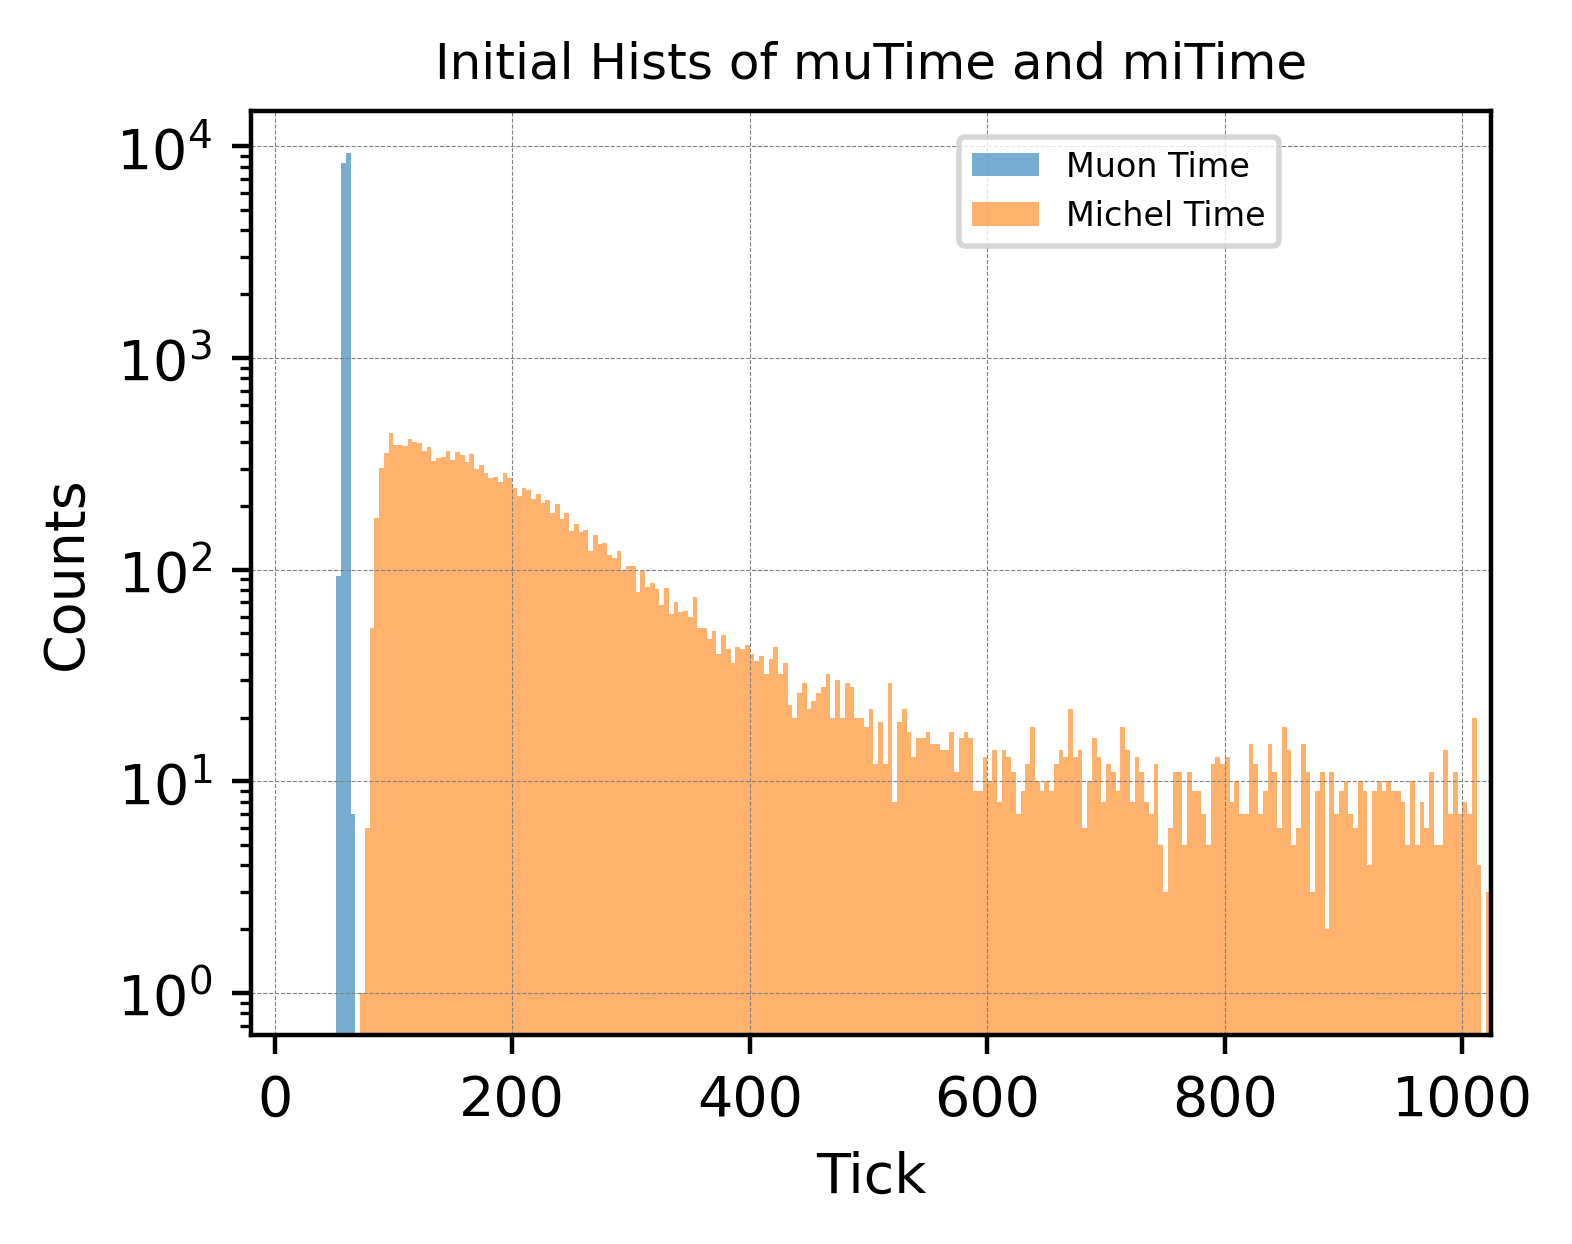




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  19286


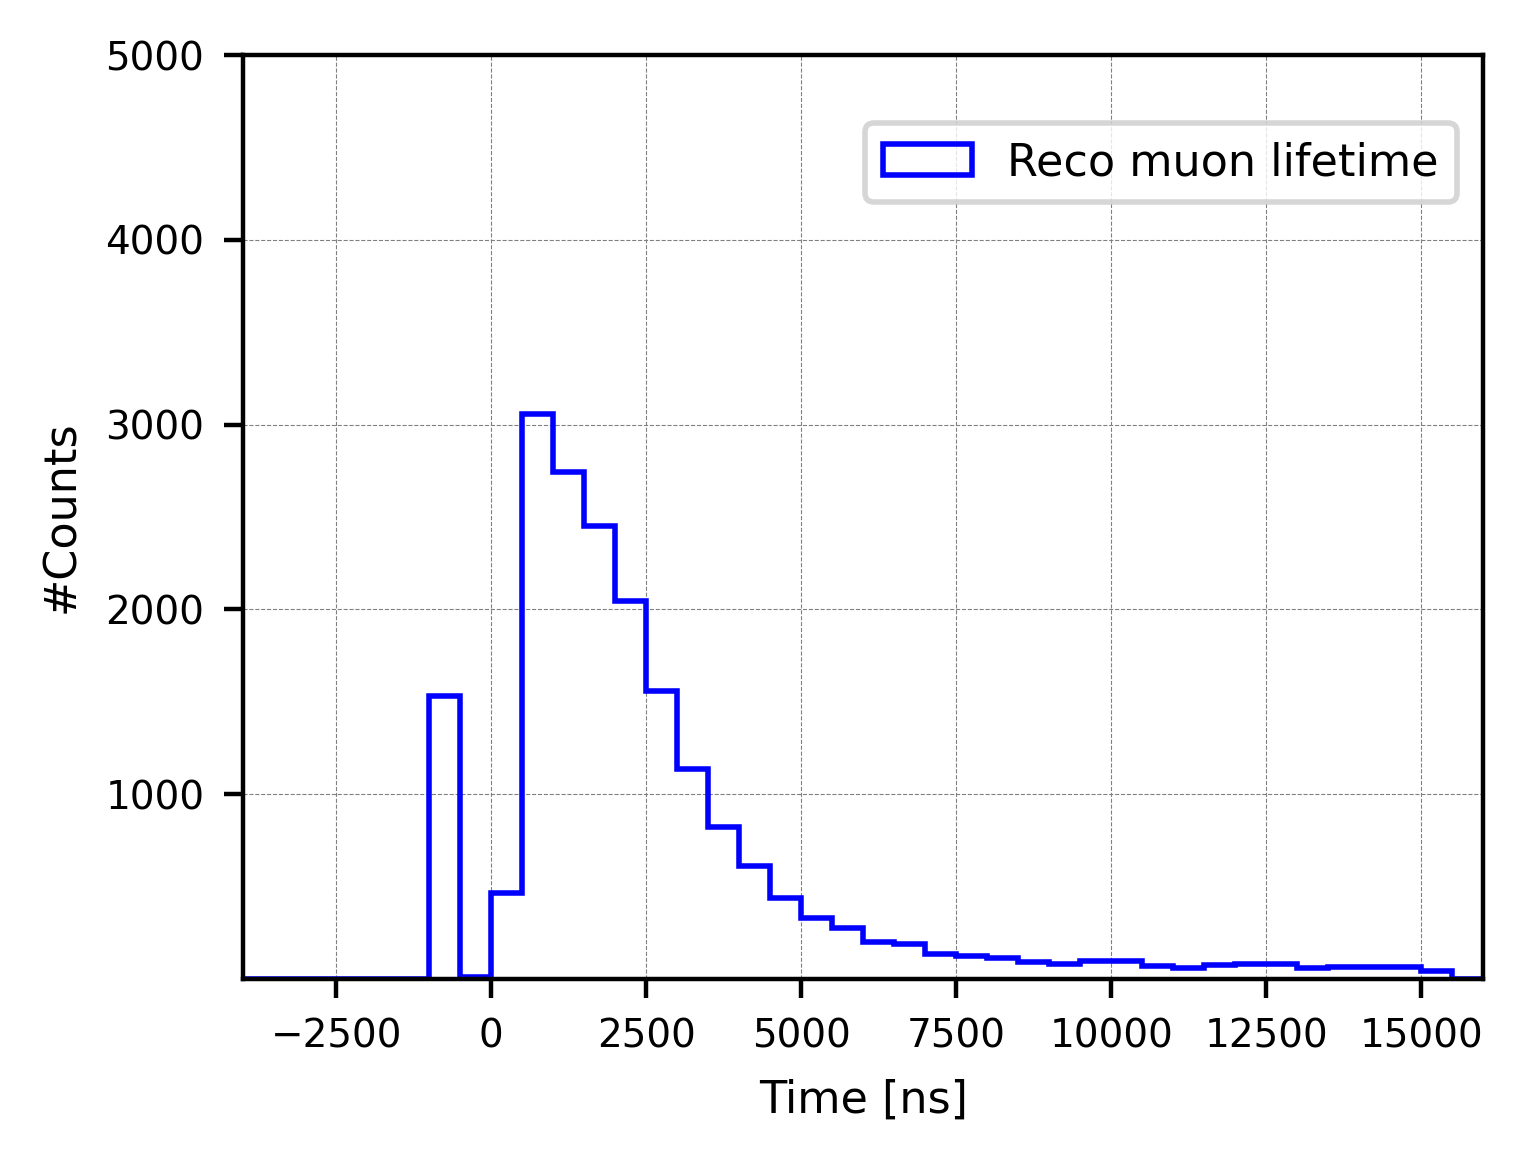

In [71]:
events_reco_update1 = []

lifetime_reco_update1 = []

events_reco_update1X = []


for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time

    if 50 <= muTime <= 65:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if muTime < miTime:
            events_reco_update1X.append(ev)


print("Muon events selection (mu peak constrained to [50, 65]):")
print("Updated Muon events: ", len(events_reco_update1), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))


print("Adding muTIme < miTime:")
print("Updated Muon events: ", len(events_reco_update1X), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1X)/len(events_reco_initial)*100))








#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








#Initial_X Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1X]
miTime_update = [ev.michel_time for ev in events_reco_update1X]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---



print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(-4000, 16000)
plt.ylim(0.9, 5000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime (constrain lifetime to [500, inf))

#### (20251022): lifetime cut should be >0 here (we know later that 500 is NOT a good standard)




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  17742


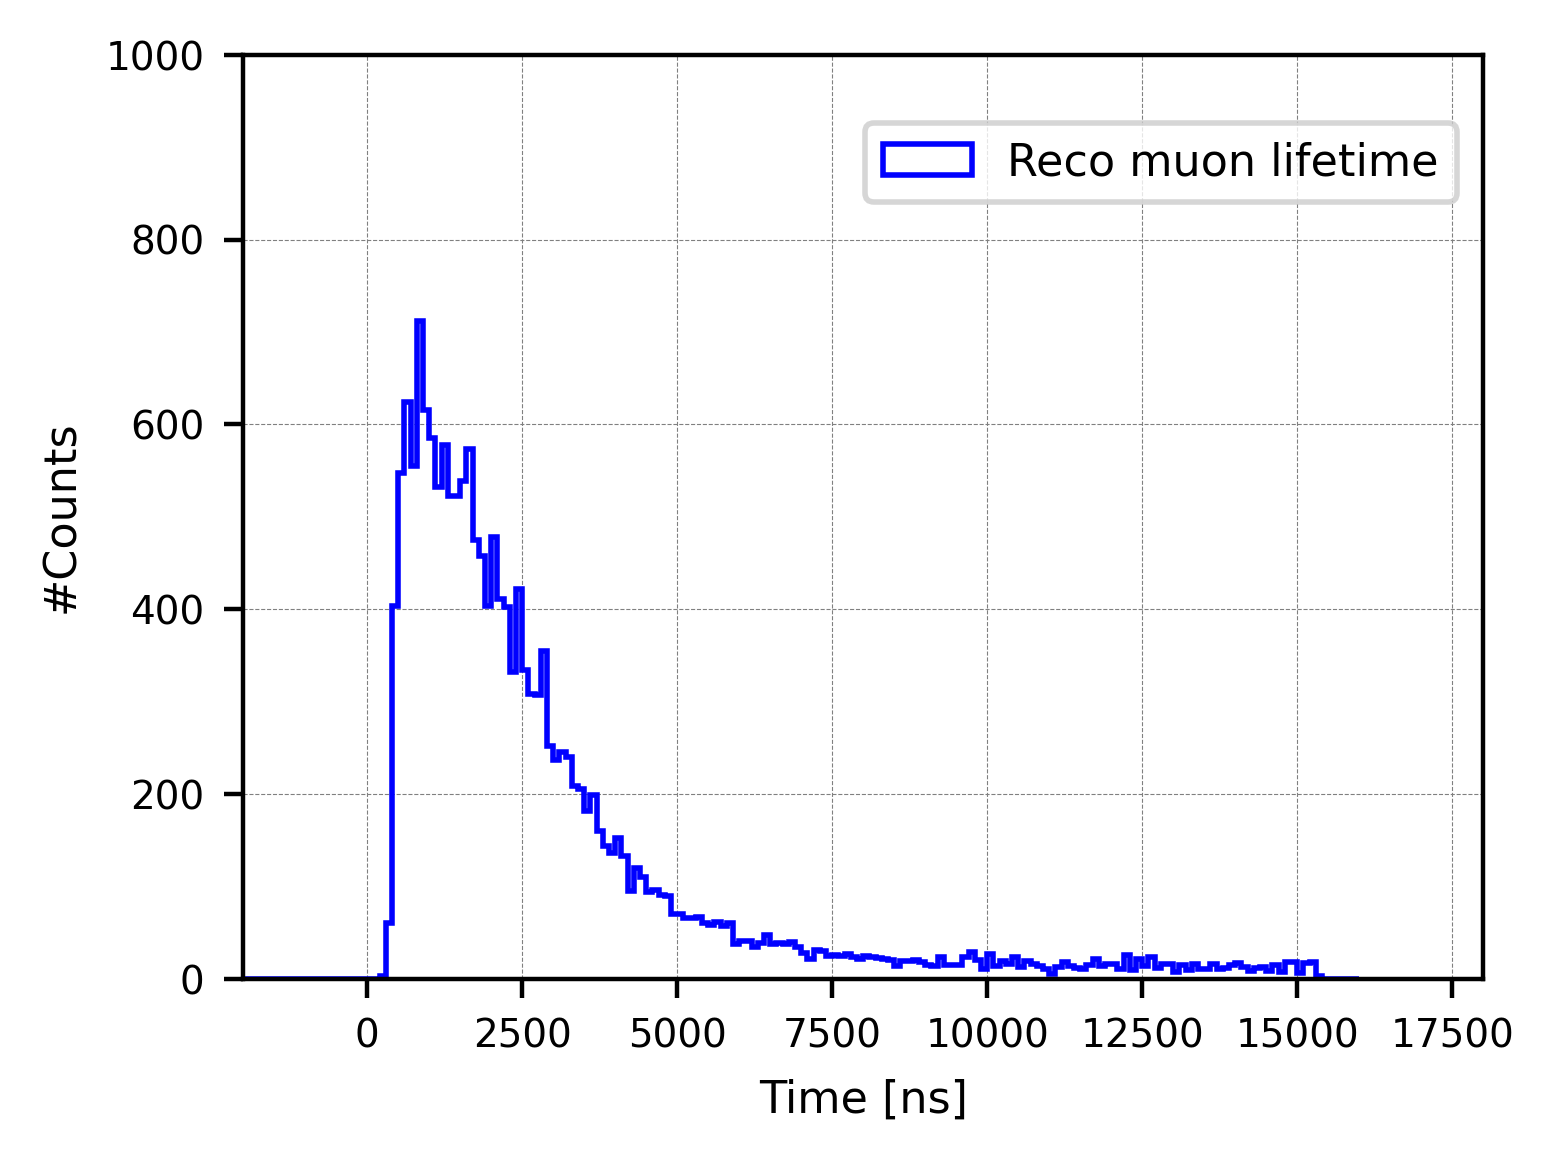

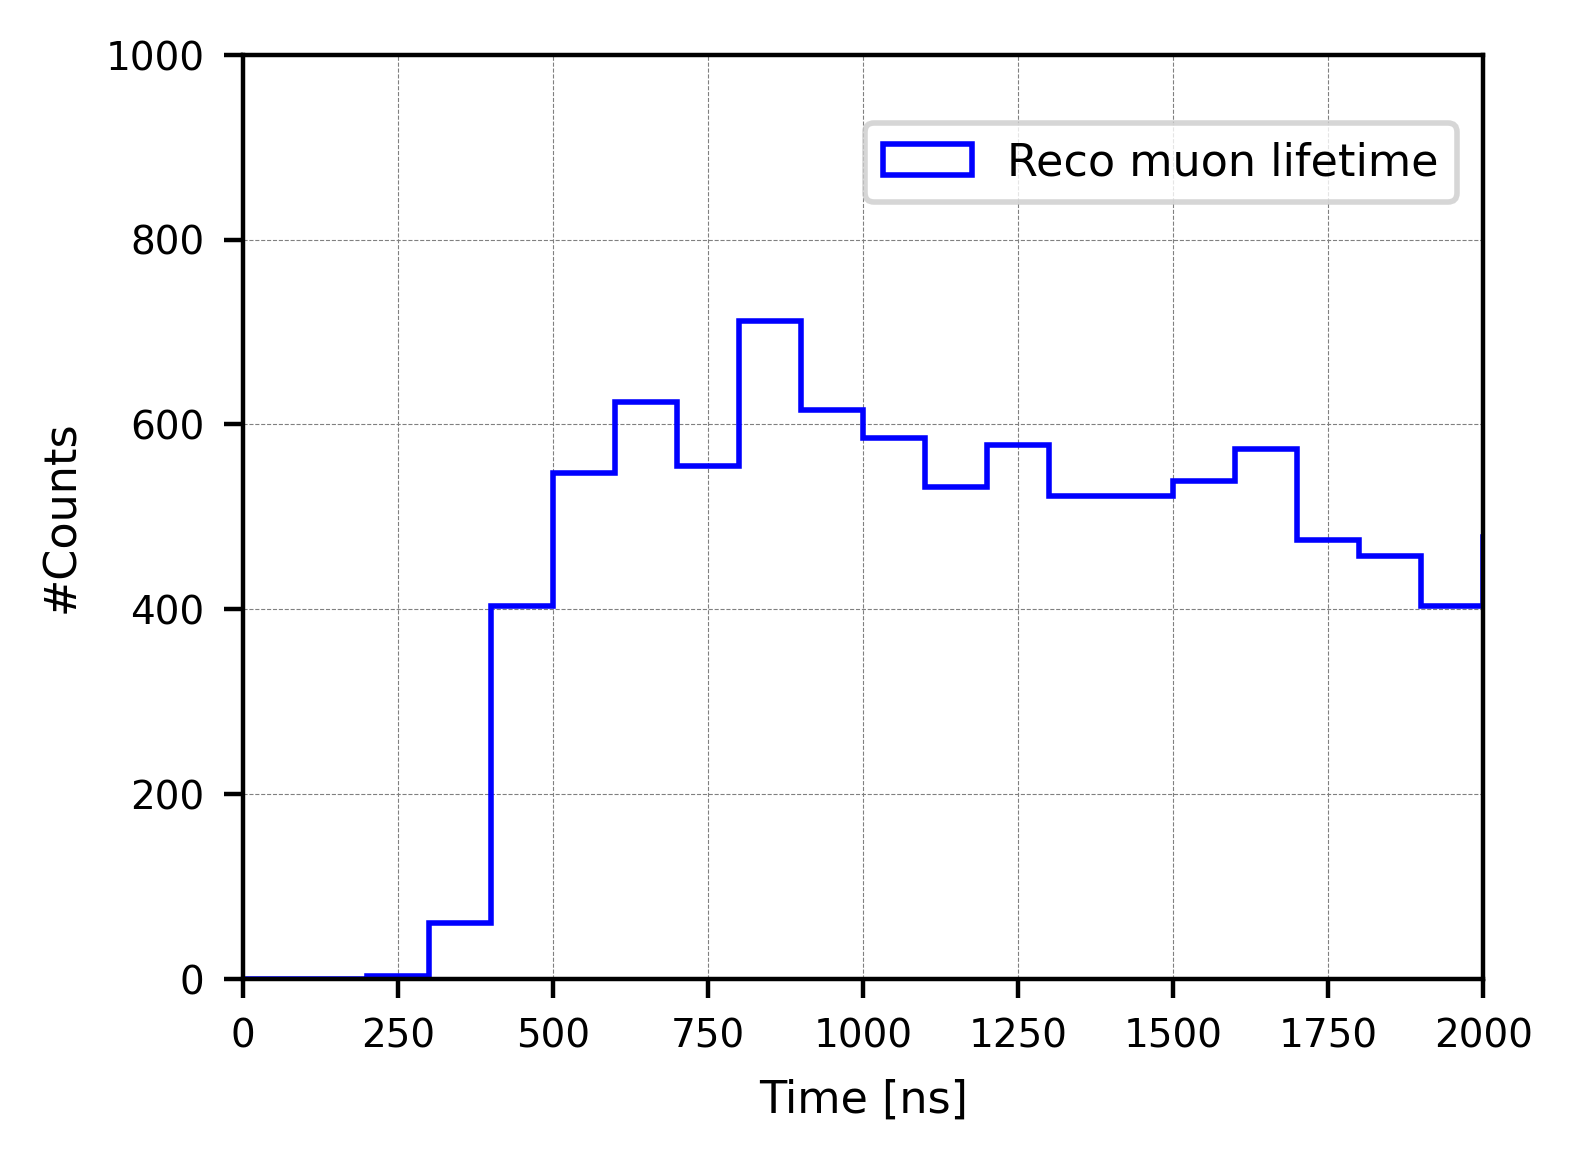

In [72]:
events_reco_update2 = []#Dataset after Purification 2---
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

#plt.plot([-2000, 20000], [5, 5], color="green", linewidth=0.8, linestyle='--', label='y = 5')
#plt.plot([-2000, 20000], [10, 10], color="magenta", linewidth=0.8, linestyle='--', label='y = 10')

plt.xlim(-2000, 18000)
plt.ylim(0, 1000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# zoomed-in plot--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(0, 2000)
plt.ylim(0, 1000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [73]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))



#Rise is intensity related: rise ~ intensity / time; 20251207---
#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45



#New calculated reco & true lifetime lists:
recoLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)

#    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
#    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)
    left_slope = (2.5 * ev.mi_leftHeight - 0.45) / (miTime - ev.mi_leftTurn) #20251207---
    right_slope = (2.5 * ev.mi_rightHeight - 0.45) / (ev.mi_rightTurn - miTime)


#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))




Size of events_reco_update2 (previous class):  17742
Size of lifetime_reco_update2               :  17742

Length of final dataset in format of new class:  17742


<br />
<br />
<br />
<br />

### MC DATA Intensity Comparison:

Array sizes:
  DATA muon          : 17742
  DATA Michel        : 17742
  MC muon            : 138842
  MC Michel (total)  : 138842
  MC Michel (true )  : 60766
  MC Michel (bkg  )  : 78076


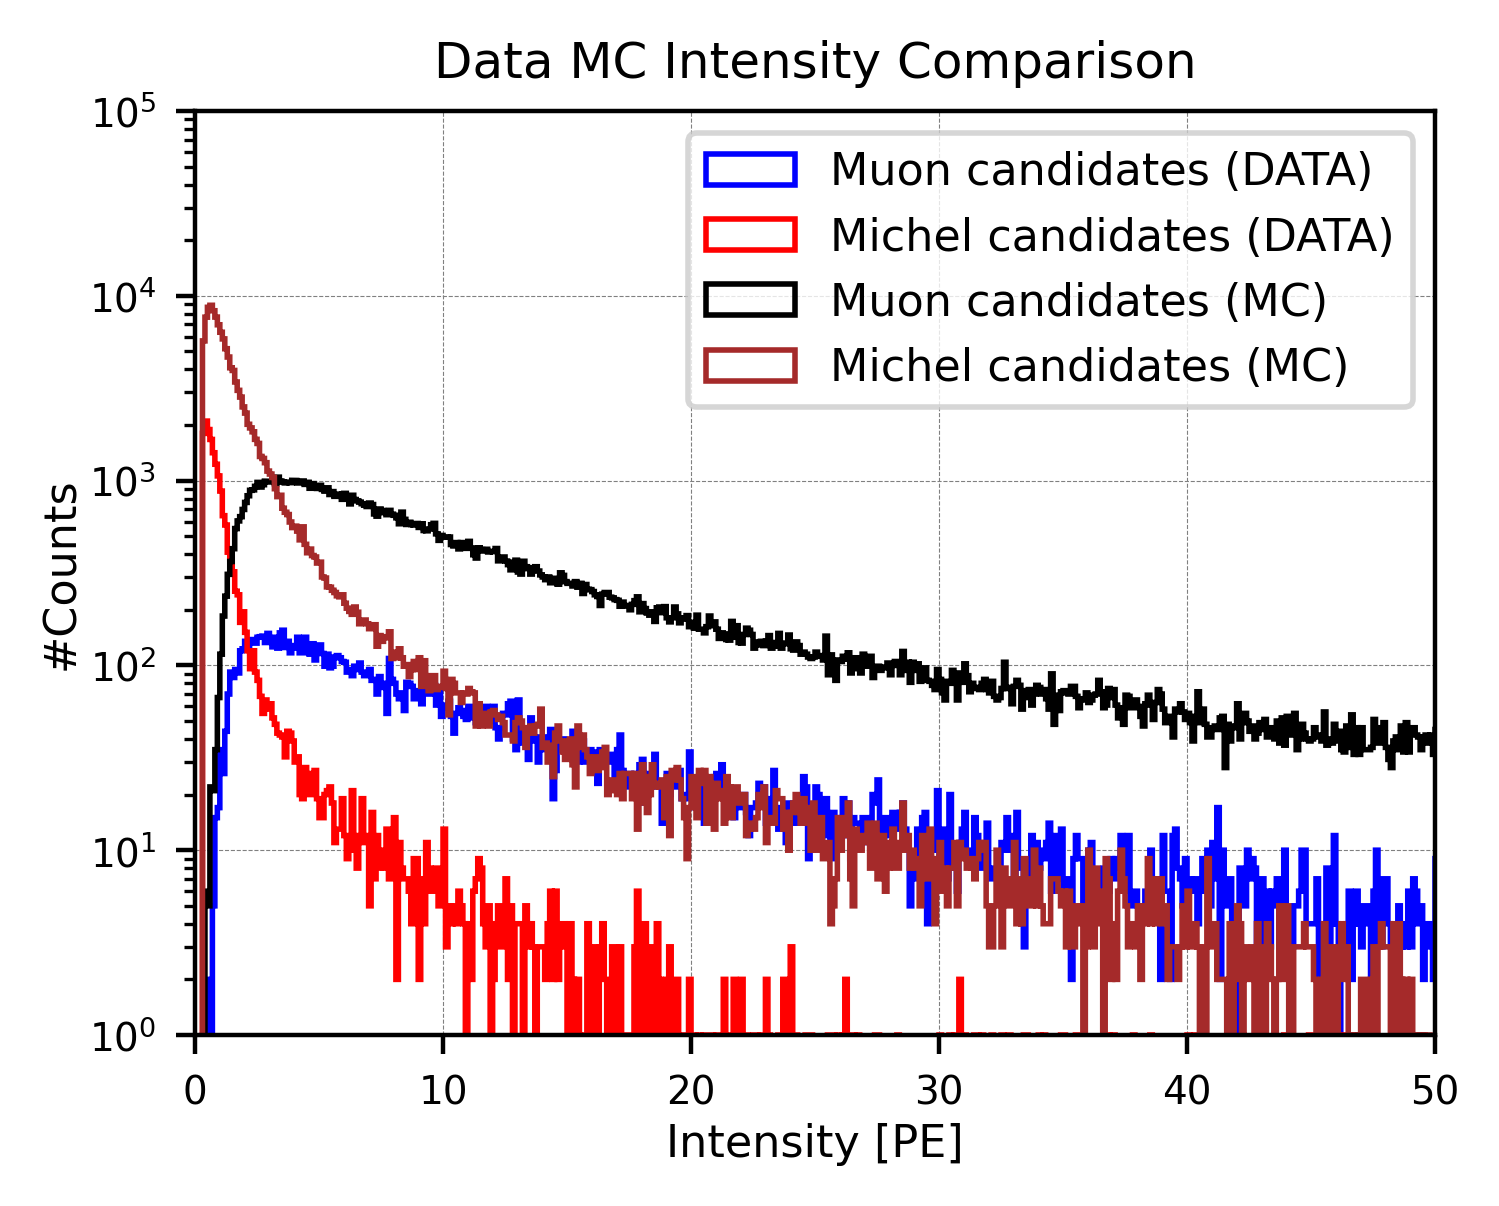

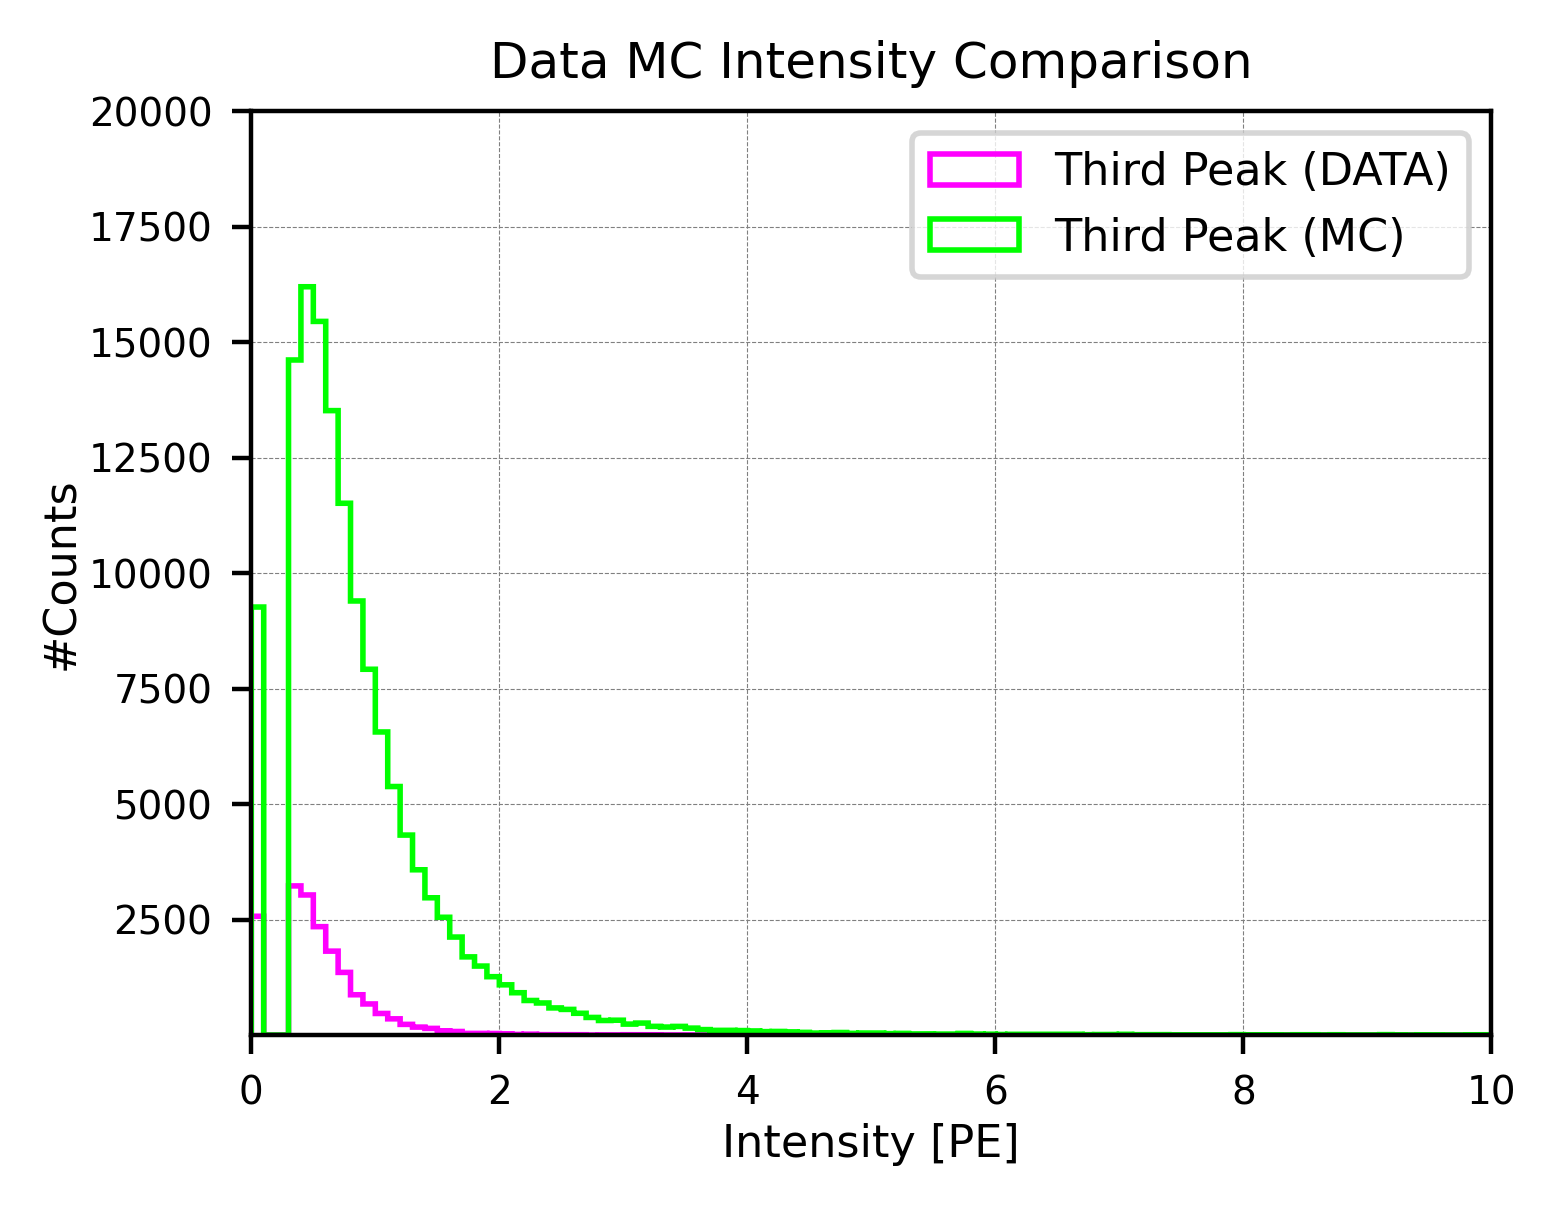

In [222]:
from scipy.stats import gaussian_kde
from matplotlib import colors
import matplotlib.patches as mpatches
from iminuit import Minuit
import numpy as np
import matplotlib.pyplot as plt

#============================================================
# 1. Prepare arrays
# ============================================================
recoLife_diff = [ev.reco_lifetime for ev in events_newClass]
muInt_diff = [ev.muon_intensity for ev in events_newClass]
miInt_diff = [ev.michel_intensity for ev in events_newClass]
thirdInt_diff = [ev.third_intensity for ev in events_newClass]
X_diff = [ev.posX for ev in events_newClass]

muInt_diff = np.array(muInt_diff, dtype=float)
miInt_diff = np.array(miInt_diff, dtype=float)

# Compare with MC ====================================
muInt_total_MC = np.load("../../MC_new20251070s/muInt_total_MC.npy")
miInt_total_MC = np.load("../../MC_new20251070s/miInt_total_MC.npy")
thirdInt_total_MC = np.load("../../MC_new20251070s/thirdInt_total_MC.npy")
miInt_diff0_MC = np.load("../../MC_new20251070s/miInt_diff0_MC.npy")
miInt_diff500_MC = np.load("../../MC_new20251070s/miInt_diff500_MC.npy")

muInt_total_MC = np.array(muInt_total_MC, dtype=float)
miInt_total_MC = np.array(miInt_total_MC, dtype=float)
miInt_diff0_MC = np.array(miInt_diff0_MC, dtype=float)
miInt_diff500_MC = np.array(miInt_diff500_MC, dtype=float)

print("Array sizes:")
print(f"  DATA muon          : {len(muInt_diff)}")
print(f"  DATA Michel        : {len(miInt_diff)}")
print(f"  MC muon            : {len(muInt_total_MC)}")
print(f"  MC Michel (total)  : {len(miInt_total_MC)}")
print(f"  MC Michel (true )  : {len(miInt_diff0_MC)}")
print(f"  MC Michel (bkg  )  : {len(miInt_diff500_MC)}")




plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_diff, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Muon candidates (DATA)")
plt.hist(miInt_diff, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Michel candidates (DATA)")

plt.hist(muInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='black',
         histtype='step', linewidth=1.0, label="Muon candidates (MC)")
plt.hist(miInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='brown', 
         histtype='step', linewidth=1.0, label="Michel candidates (MC)")

#plt.plot([1, 1], [0, 40000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([4, 4], [0, 400000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Data MC Intensity Comparison', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 






# 3rd peak intensity distributions----------
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(thirdInt_diff, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Third Peak (DATA)")

plt.hist(thirdInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='lime',
         histtype='step', linewidth=1.0, label="Third Peak (MC)")

#plt.plot([1, 1], [0, 40000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([4, 4], [0, 400000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 10)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 20000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Data MC Intensity Comparison', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 


<br />

### Muon Scaling:
For the muon scaling fit, a good practical choice is fit window [0.3, 20] with bin width 0.1.

##### Muon intensity scaling

To compare the muon intensity distributions between DATA and MC, a linear transformation
is applied to the MC intensity:

$$
I_{\mathrm{MC}}^{\mathrm{scaled}} = a\, I_{\mathrm{MC}} + b ,
$$

where \(a\) is a multiplicative scaling factor and \(b\) is an additive shift.

The predicted MC counts in histogram bin \(i\) are then

$$
M_i(a,b,N) = N \, H_i\!\left(a\, I_{\mathrm{MC}} + b\right),
$$

where

- \($H_i$\) is the number of MC events falling into bin \(i\) after the intensity transformation,
- \(N\) is an overall normalization factor accounting for the different sample sizes of DATA and MC.

The parameters \((a,b,N)\) are determined by minimizing the following \($\chi^2$\) function:

$$
\chi^2(a,b,N)
=
\sum_{i}
\frac{\left[D_i - M_i(a,b,N)\right]^2}
{D_i + M_i(a,b,N) + 1},
$$

where \(D_i\) denotes the number of DATA events in bin \(i\).

The best-fit parameters are therefore obtained from

$$
(a^*, b^*, N^*)
=
\operatorname*{argmin}_{a,b,N} \chi^2(a,b,N).
$$

The resulting transformation is applied to the MC intensity distribution to obtain the
DATA–MC comparison for muon candidates.

In [148]:

# ============================================================
# 2. Fit settings
# ============================================================
fit_min = 0.3
fit_max = 20.0
fit_bin_width = 0.1
fit_bins = np.arange(fit_min, fit_max + fit_bin_width, fit_bin_width)
fit_bin_centers = 0.5 * (fit_bins[:-1] + fit_bins[1:])

print(f"Number of bins = {len(fit_bins) - 1}")



# ============================================================
# 3. Helper functions
# ============================================================
def transform_mc(mc_array, x_scale, x_shift):
    return x_scale * mc_array + x_shift


def make_hist(array, bins):
    hist, edges = np.histogram(array, bins=bins)
    return hist.astype(float), edges


# ============================================================
# 4. Fit wrapper using Minuit
# ============================================================
def fit_data_mc_scaling_minuit(
    data_array,
    mc_array,
    bins,
    init_x_scale=1.0,
    init_x_shift=0.0,
    init_y_scale=1.0,
    fit_name="sample"
):
    data_hist, edges = np.histogram(data_array, bins=bins)
    data_hist = data_hist.astype(float)

    def chi2(x_scale, x_shift, y_scale):
        if x_scale <= 0.0 or y_scale <= 0.0:
            return 1.0e30

        mc_transformed = transform_mc(mc_array, x_scale, x_shift)
        mc_hist, _ = np.histogram(mc_transformed, bins=bins)
        mc_hist = mc_hist.astype(float)

        mc_hist_scaled = y_scale * mc_hist

        # Safe variance
        sigma2 = data_hist + mc_hist_scaled + 1.0

        value = np.sum((data_hist - mc_hist_scaled) ** 2 / sigma2)
        return value

    m = Minuit(
        chi2,
        x_scale=init_x_scale,
        x_shift=init_x_shift,
        y_scale=init_y_scale
    )

    # χ2 fit
    m.errordef = Minuit.LEAST_SQUARES

    # Parameter limits
    m.limits["x_scale"] = (1.0e-6, None)
    m.limits["y_scale"] = (1.0e-12, None)
    # x_shift can be positive or negative, so leave it free
    # If you want, you may later constrain it:
    # m.limits["x_shift"] = (-1.0, 1.0)

    m.migrad()
    m.hesse()

    best_x_scale = m.values["x_scale"]
    best_x_shift = m.values["x_shift"]
    best_y_scale = m.values["y_scale"]

    err_x_scale = m.errors["x_scale"]
    err_x_shift = m.errors["x_shift"]
    err_y_scale = m.errors["y_scale"]

    mc_best = transform_mc(mc_array, best_x_scale, best_x_shift)
    mc_hist, _ = np.histogram(mc_best, bins=bins)
    mc_hist = mc_hist.astype(float)
    mc_hist_scaled = best_y_scale * mc_hist

    sigma2 = data_hist + mc_hist_scaled + 1.0
    chi2_val = np.sum((data_hist - mc_hist_scaled) ** 2 / sigma2)

    n_bins_used = len(data_hist)
    n_params = m.nfit
    ndf = n_bins_used - n_params
    chi2_ndf = chi2_val / ndf if ndf > 0 else np.nan

    fit_result = {
        "fit_name": fit_name,
        "success": m.fmin.is_valid,
        "message": str(m.fmin),
        "minuit": m,
        "x_scale": best_x_scale,
        "x_shift": best_x_shift,
        "y_scale": best_y_scale,
        "x_scale_err": err_x_scale,
        "x_shift_err": err_x_shift,
        "y_scale_err": err_y_scale,
        "chi2": chi2_val,
        "ndf": ndf,
        "chi2_ndf": chi2_ndf,
        "data_hist": data_hist,
        "mc_hist_scaled": mc_hist_scaled,
        "edges": edges,
        "bin_centers": 0.5 * (edges[:-1] + edges[1:]),
        "mc_best_array": mc_best
    }

    return fit_result


# ============================================================
# 5. Fit Michel candidates
# ============================================================
fit_michel = fit_data_mc_scaling_minuit(
    data_array=miInt_diff,
    mc_array=miInt_total_MC,
    bins=fit_bins,
    init_x_scale=0.5,
    init_x_shift=0.1,
    init_y_scale=0.1,
    fit_name="Michel"
)

print("Michel fit result:")
print(f"  success      = {fit_michel['success']}")
print(f"  x_scale      = {fit_michel['x_scale']:.6f} +/- {fit_michel['x_scale_err']:.6f}")
print(f"  x_shift      = {fit_michel['x_shift']:.6f} +/- {fit_michel['x_shift_err']:.6f}")
print(f"  y_scale      = {fit_michel['y_scale']:.6f} +/- {fit_michel['y_scale_err']:.6f}")
print(f"  chi2         = {fit_michel['chi2']:.3f}")
print(f"  ndf          = {fit_michel['ndf']}")
print(f"  chi2/ndf     = {fit_michel['chi2_ndf']:.3f}")

# ============================================================
# 6. Fit muon candidates
# ============================================================
fit_muon = fit_data_mc_scaling_minuit(
    data_array=muInt_diff,
    mc_array=muInt_total_MC,
    bins=fit_bins,
    init_x_scale=1.0,
    init_x_shift=0.0,
    init_y_scale=0.1,
    fit_name="Muon"
)

print("Muon fit result:")
print(f"  success      = {fit_muon['success']}")
print(f"  x_scale      = {fit_muon['x_scale']:.6f} +/- {fit_muon['x_scale_err']:.6f}")
print(f"  x_shift      = {fit_muon['x_shift']:.6f} +/- {fit_muon['x_shift_err']:.6f}")
print(f"  y_scale      = {fit_muon['y_scale']:.6f} +/- {fit_muon['y_scale_err']:.6f}")
print(f"  chi2         = {fit_muon['chi2']:.3f}")
print(f"  ndf          = {fit_muon['ndf']}")
print(f"  chi2/ndf     = {fit_muon['chi2_ndf']:.3f}")

# ============================================================
# 7. Final summary
# ============================================================
print("Diagnosis of Muon fitting:")
print(fit_muon["message"])
print(fit_muon["minuit"].fmin)
print(fit_muon["minuit"].params)

m = fit_muon["minuit"]
print("is_valid =", m.fmin.is_valid)
print("has_accurate_covar =", m.fmin.has_accurate_covar)
print("has_posdef_covar =", m.fmin.has_posdef_covar)
print("hesse_failed =", m.fmin.hesse_failed)
print("has_valid_parameters =", m.fmin.has_valid_parameters)
print("edm =", m.fmin.edm)
print("nfcn =", m.fmin.nfcn)






Number of bins = 197
Michel fit result:
  success      = True
  x_scale      = 0.499755 +/- 0.000001
  x_shift      = 0.147196 +/- 0.000005
  y_scale      = 0.127173 +/- 0.001364
  chi2         = 153.933
  ndf          = 194
  chi2/ndf     = 0.793
Muon fit result:
  success      = False
  x_scale      = 0.999994 +/- 0.000004
  x_shift      = -0.000035 +/- 0.000018
  y_scale      = 0.130654 +/- 0.001652
  chi2         = 188.252
  ndf          = 194
  chi2/ndf     = 0.970
Diagnosis of Muon fitting:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 188.3                      │              Nfcn = 251              │
│ EDM = 0.0907 (Goal: 0.0002)      │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABO

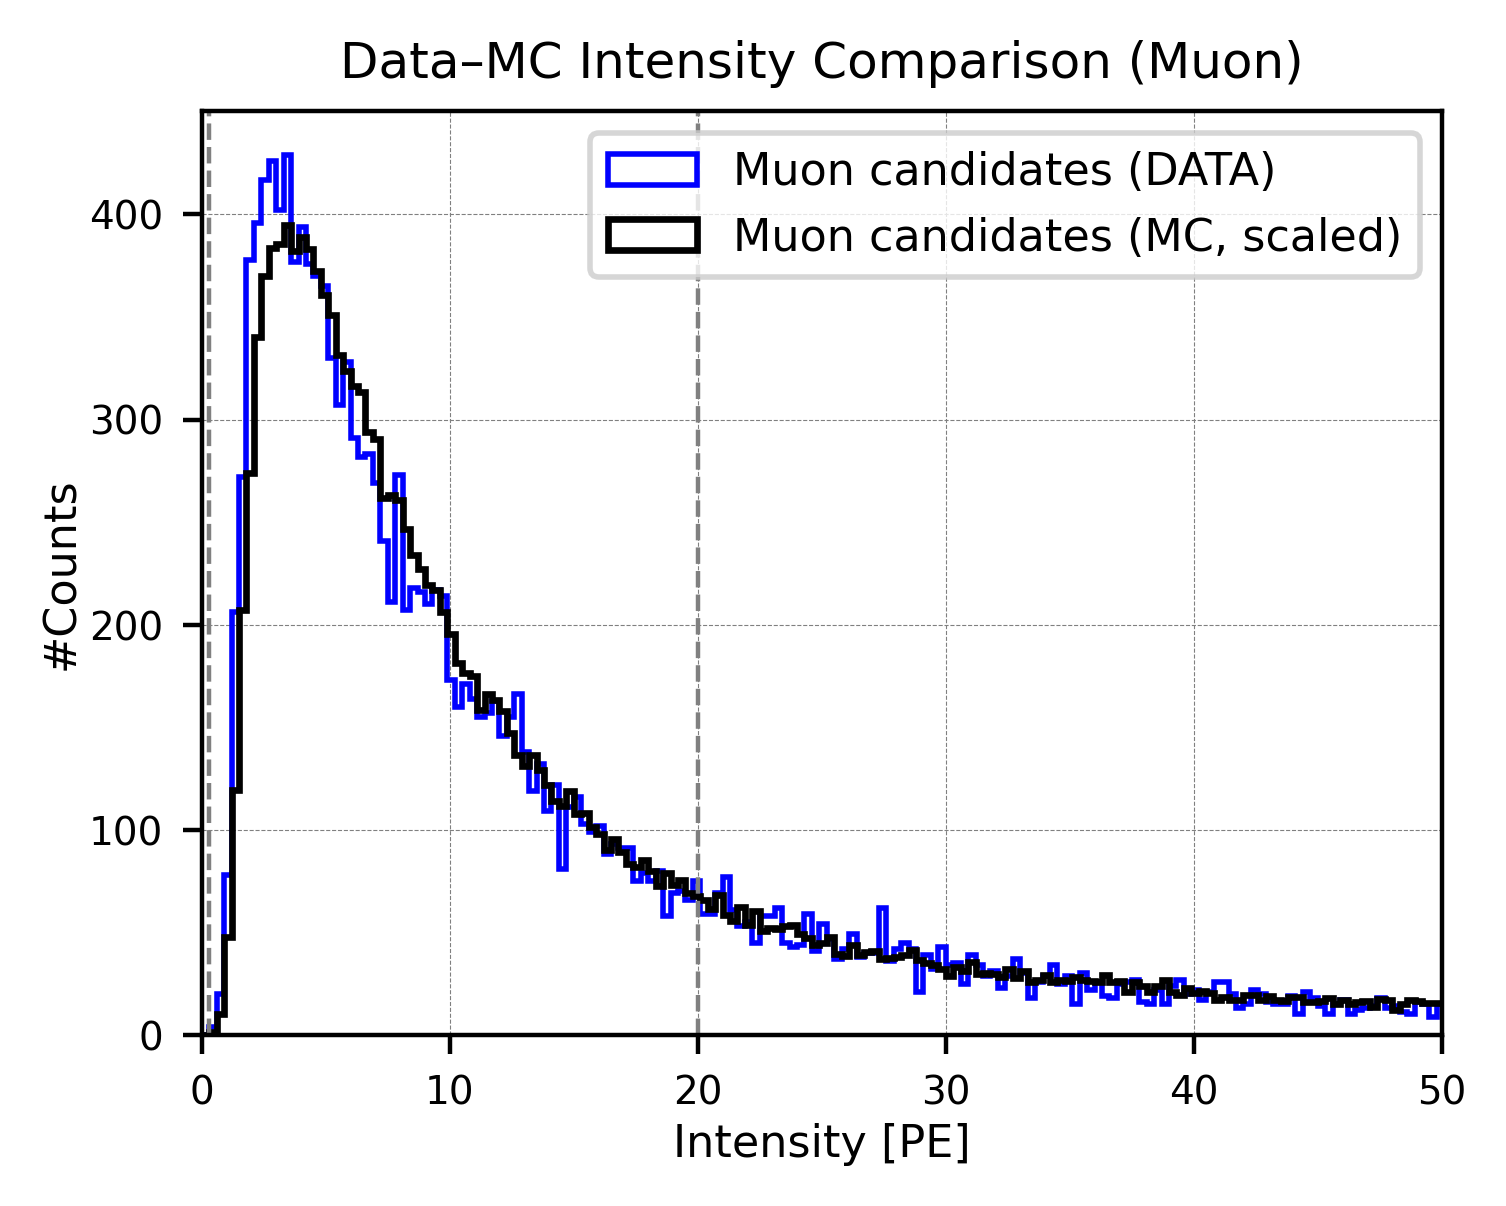

In [149]:
# Plotting=============================================================================
plt.figure(figsize=(4,3), dpi=400)

# ============================================================
# Plot settings
# ============================================================
plot_min = 0.0
plot_max = 50.0
plot_bin_width = 0.3
plot_bins = np.arange(plot_min, plot_max + plot_bin_width, plot_bin_width)


# ============================================================
# 1. Apply the fitted transformation to MC
# ============================================================
x_scale_mu = fit_muon["x_scale"]
x_shift_mu = fit_muon["x_shift"]
y_scale_mu = fit_muon["y_scale"]

muInt_MC_scaled = x_scale_mu * muInt_total_MC + x_shift_mu

# ============================================================
# 2. DATA histogram
# ============================================================
plt.hist(
    muInt_diff,
    bins=plot_bins,
    range=(range_min, range_max),
    histtype='step',
    edgecolor='blue',
    linewidth=1.0,
    label="Muon candidates (DATA)"
)

# ============================================================
# 3. MC histogram (scaled)
# ============================================================
weights_MC_mu = np.full(len(muInt_MC_scaled), y_scale_mu)

plt.hist(
    muInt_MC_scaled,
    bins=plot_bins,
    range=(range_min, range_max),
    histtype='step',
    linewidth=1.2,
    color='black',
    weights=weights_MC_mu,
    label="Muon candidates (MC, scaled)"
)

#Show fit range:
plt.axvline(fit_min, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(fit_max, color='gray', linestyle='--', linewidth=0.8)


# ============================================================
# 4. Plot styling
# ============================================================
plt.xlim(0, 50)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)

#plt.ylim(1, 2000)
#plt.yscale('log')

plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.title('Data–MC Intensity Comparison (Muon)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")

plt.show()

<br />

### Michel scaling:

#### Sample comparison:


Summary diagnostics:
  Mean DATA Michel       = 1.58
  Mean MC Total.         = 2.68
  Mean pure Michel MC    = 3.61
  Mean Michel bkg MC     = 1.96


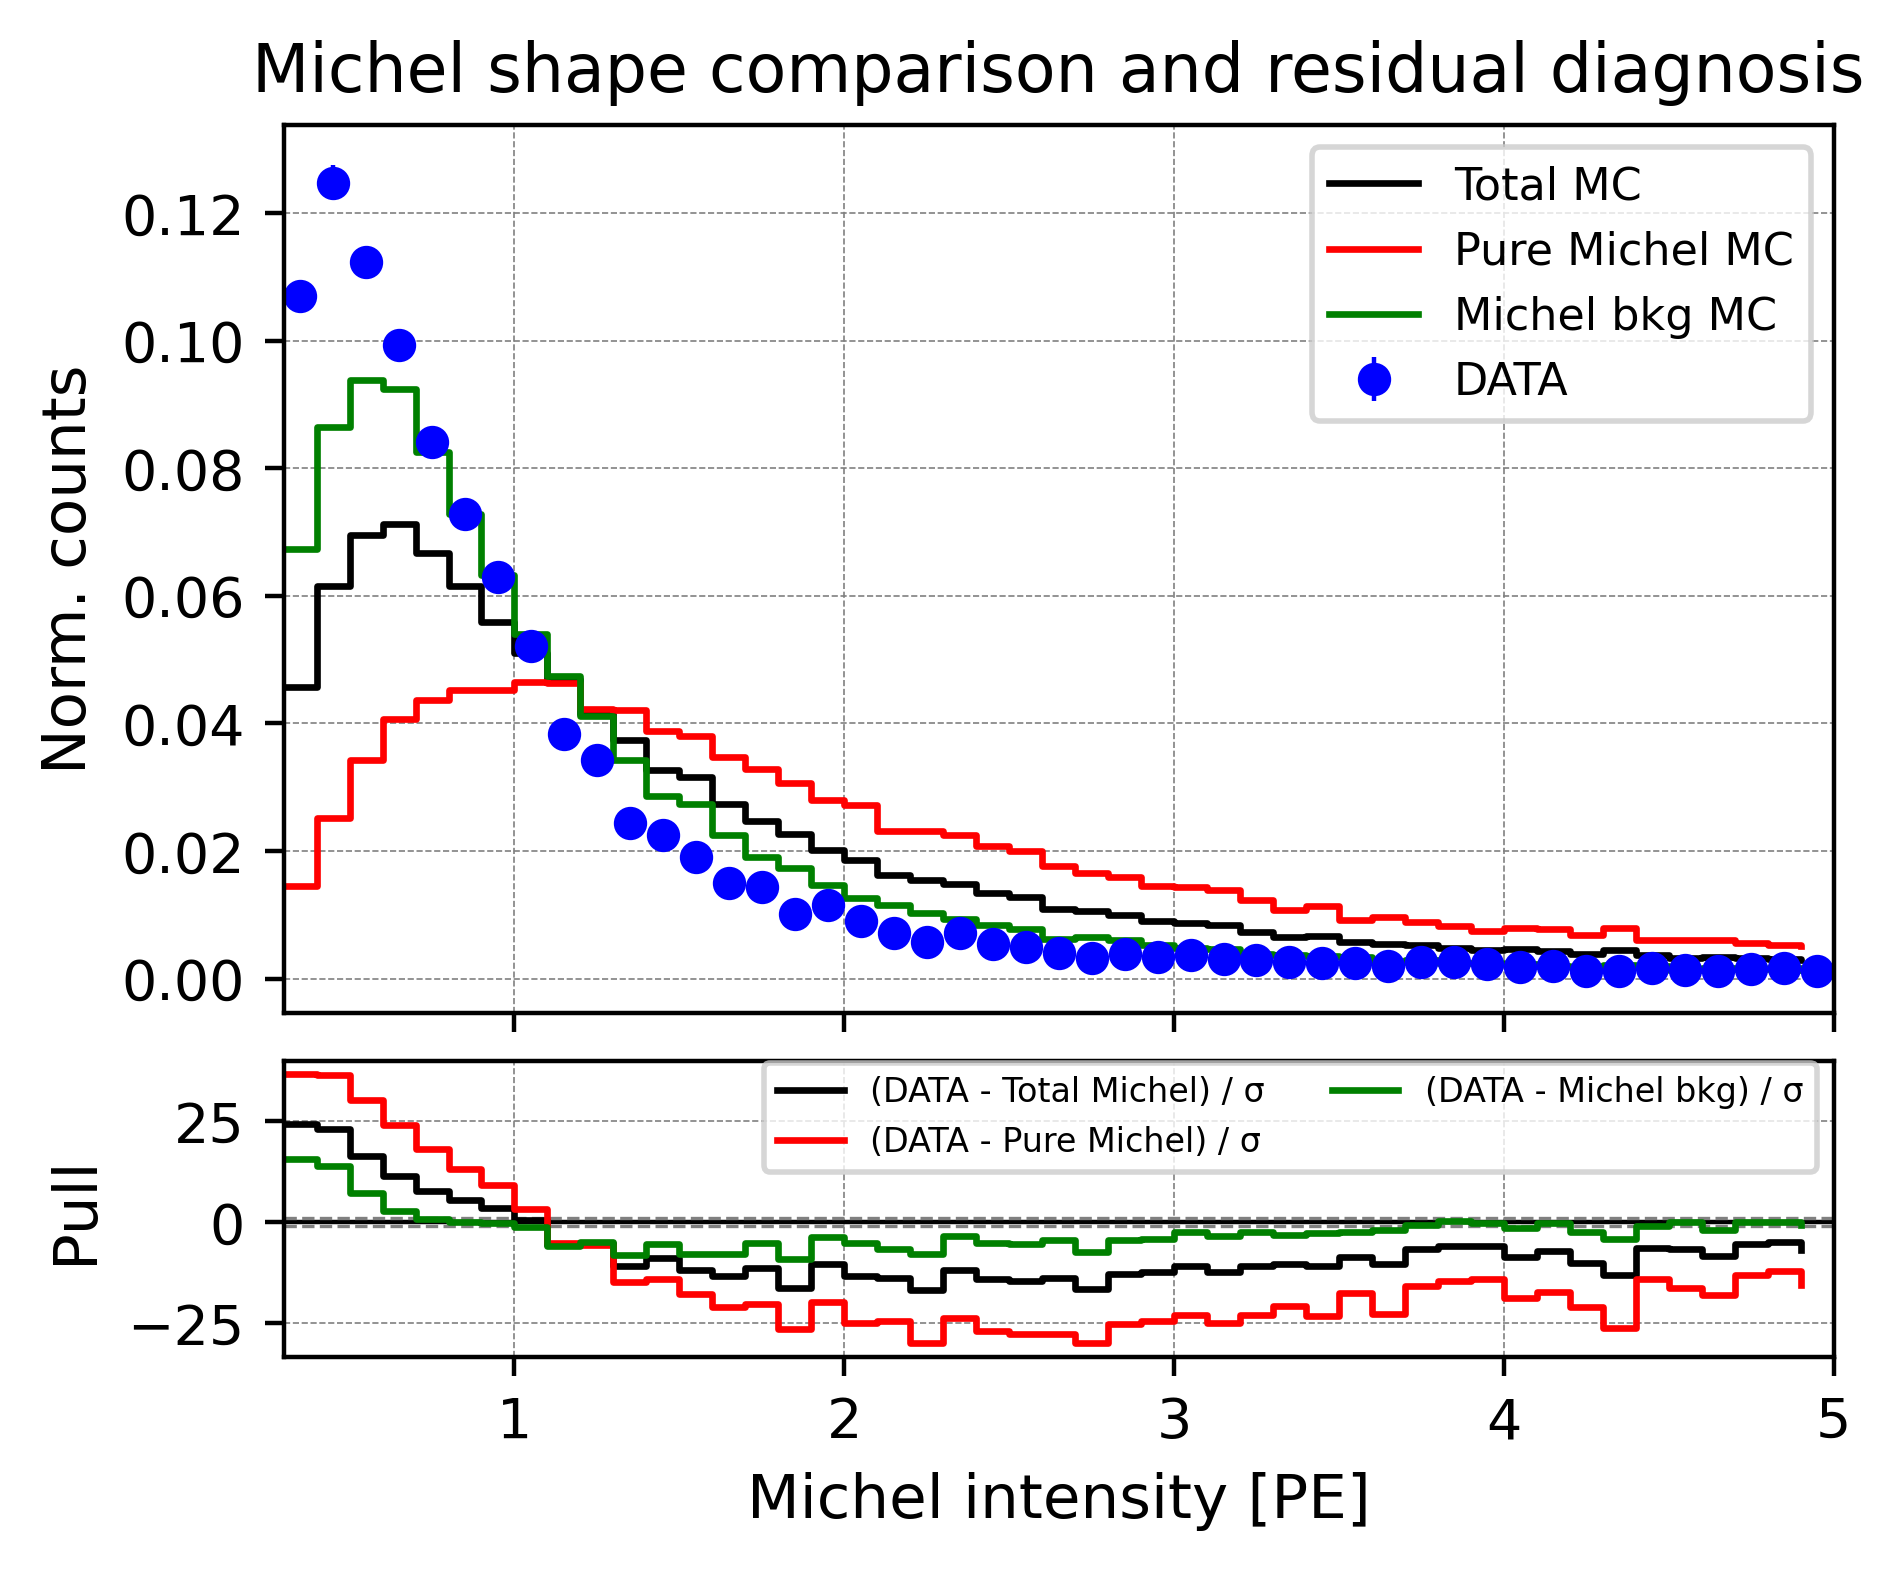

In [191]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# STYLE CONTROLS
# ============================================================
marker_size = 5
title_size  = 12
label_size  = 11
tick_size   = 10
legend_size = 8
line_width  = 1.2
grid_width  = 0.3
print_precision = 2

# ============================================================
# HISTOGRAM SETTINGS
# ============================================================
xmin = 0.3
xmax = 5
bin_width = 0.1

bins = np.arange(xmin, xmax + bin_width, bin_width)
centers = 0.5 * (bins[:-1] + bins[1:])

# ============================================================
# INPUT ARRAYS
# ============================================================
data = np.asarray(miInt_diff, dtype=float)
mcTotal  = np.asarray(miInt_total_MC, dtype=float)
sig  = np.asarray(miInt_diff0_MC, dtype=float)
bkg  = np.asarray(miInt_diff500_MC, dtype=float)

# ============================================================
# PRINT SUMMARY
# ============================================================
mean_data = np.mean(data)
mean_mcTotal = np.mean(mcTotal)
mean_sig  = np.mean(sig)
mean_bkg  = np.mean(bkg)

print("\nSummary diagnostics:")
print(f"  Mean DATA Michel       = {mean_data:.{print_precision}f}")
print(f"  Mean MC Total.         = {mean_mcTotal:.{print_precision}f}")
print(f"  Mean pure Michel MC    = {mean_sig:.{print_precision}f}")
print(f"  Mean Michel bkg MC     = {mean_bkg:.{print_precision}f}")

# ============================================================
# HISTOGRAMS
# ============================================================
data_hist, _ = np.histogram(data, bins=bins)
mcTotal_hist, _ = np.histogram(mcTotal, bins=bins)
sig_hist,  _ = np.histogram(sig,  bins=bins)
bkg_hist,  _ = np.histogram(bkg,  bins=bins)

data_hist = data_hist.astype(float)
mcTotal_hist = mcTotal_hist.astype(float)
sig_hist  = sig_hist.astype(float)
bkg_hist  = bkg_hist.astype(float)

# Normalize to shapes
data_shape = data_hist / np.sum(data_hist)
mcTotal_shape = mcTotal_hist / np.sum(mcTotal_hist)
sig_shape  = sig_hist  / np.sum(sig_hist)
bkg_shape  = bkg_hist  / np.sum(bkg_hist)

# DATA uncertainty on normalized shape
n_data = np.sum(data_hist)
data_err = np.sqrt(data_hist) / n_data

# Pulls
sigma = np.where(data_err > 0, data_err, np.nan)
pull_mcTotal = (data_shape - mcTotal_shape) / sigma
pull_sig = (data_shape - sig_shape) / sigma
pull_bkg = (data_shape - bkg_shape) / sigma

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# -------------------- Top panel --------------------
ax1.errorbar(
    centers, data_shape, yerr=data_err,
    fmt='o', color='blue', markersize=marker_size,
    linewidth=0.8, label='DATA'
)

ax1.step(
    bins[:-1], mcTotal_shape, where='post',
    color='black', linewidth=line_width, label='Total MC'
)


ax1.step(
    bins[:-1], sig_shape, where='post',
    color='red', linewidth=line_width, label='Pure Michel MC'
)

ax1.step(
    bins[:-1], bkg_shape, where='post',
    color='green', linewidth=line_width, label='Michel bkg MC'
)

ax1.set_ylabel("Norm. counts", fontsize=label_size)
ax1.set_title("Michel shape comparison and residual diagnosis", fontsize=title_size)
ax1.tick_params(labelsize=tick_size)
ax1.grid(color='gray', linestyle='--', linewidth=grid_width)
ax1.legend(fontsize=legend_size, loc='upper right')

# Hide top x tick labels to match your shared style
ax1.tick_params(labelbottom=False)

# -------------------- Bottom panel --------------------
ax2.axhline(0.0, color='black', linewidth=0.8)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.6)
ax2.axhline(-1.0, color='gray', linestyle='--', linewidth=0.6)

ax2.step(
    bins[:-1], pull_mcTotal, where='post',
    color='black', linewidth=line_width, label='(DATA - Total Michel) / σ'
)

ax2.step(
    bins[:-1], pull_sig, where='post',
    color='red', linewidth=line_width, label='(DATA - Pure Michel) / σ'
)

ax2.step(
    bins[:-1], pull_bkg, where='post',
    color='green', linewidth=line_width, label='(DATA - Michel bkg) / σ'
)

ax2.set_xlim(xmin, xmax)
ax2.set_xlabel("Michel intensity [PE]", fontsize=label_size)
ax2.set_ylabel("Pull", fontsize=label_size)
ax2.tick_params(labelsize=tick_size)
ax2.grid(color='gray', linestyle='--', linewidth=grid_width)
ax2.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.0, 1.05), ncol=2, markerscale=0.7)

plt.show()

<br />


#### Approach 1: true Michel + background mixture

To compare the Michel intensity distributions between DATA and MC, the DATA Michel sample is modeled as a mixture of the true Michel MC template and the Michel background MC template.  
A linear transformation is applied to the true Michel MC intensity:

$$
I_{\mathrm{sig}}^{\mathrm{scaled}} = a\, I_{\mathrm{sig}} + b ,
$$

where $a$ is a multiplicative scaling factor and $b$ is an additive shift.

The predicted counts in histogram bin $i$ are then

$$
M_i(a,b,f_{\mathrm{bkg}})
=
N_{\mathrm{data}}
\left[
(1-f_{\mathrm{bkg}})\,S_i(a,b)
+
f_{\mathrm{bkg}}\,B_i
\right],
$$

where

- $S_i(a,b)$ is the normalized true Michel MC template in bin $i$ after the intensity transformation,
- $B_i$ is the normalized Michel background MC template in bin $i$,
- $f_{\mathrm{bkg}}$ is the background fraction in the DATA Michel sample,
- $N_{\mathrm{data}}$ is the total number of DATA Michel candidates.

The parameters $(a,b,f_{\mathrm{bkg}})$ are determined by minimizing the following $\chi^2$ function:

$$
\chi^2(a,b,f_{\mathrm{bkg}})
=
\sum_i
\frac{\left[D_i - M_i(a,b,f_{\mathrm{bkg}})\right]^2}
{D_i + M_i(a,b,f_{\mathrm{bkg}}) + 1},
$$

where $D_i$ denotes the number of DATA events in bin $i$.

The best-fit parameters are therefore obtained from

$$
(a^*, b^*, f_{\mathrm{bkg}}^*)
=
\operatorname*{argmin}_{a,b,f_{\mathrm{bkg}}}
\chi^2(a,b,f_{\mathrm{bkg}}).
$$

In [190]:
# ============================================================
# 2. Use the muon-fit scaling result for Michel background
# ============================================================
x_scale_bkg = 1.0   # effective scaling result of mu / fixed background scaling
x_shift_bkg = 0.0

print("Using fixed background scaling:")
print(f"  x_scale_bkg = {x_scale_bkg:.6f}")
print(f"  x_shift_bkg = {x_shift_bkg:.6f}")


# ============================================================
# 3. Fit settings for Michel 3-parameter fit
# ============================================================
fit_min = 0.3
fit_max = 10.0
bin_width = 0.1

bins = np.arange(fit_min, fit_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

print(f"Michel fit window = [{fit_min}, {fit_max}]")
print(f"Michel bin width  = {bin_width}")
print(f"Number of bins    = {len(bins) - 1}")


# ============================================================
# 4. Prepare DATA histogram once
# ============================================================
data_hist, edges = np.histogram(miInt_diff, bins=bins)
data_hist = data_hist.astype(float)

n_data = len(miInt_diff)


# ============================================================
# 5. 3-parameter fit:
#    float x_scale_sig, x_shift_sig, f_bkg
#    fix Michel background scaling
# ============================================================
def chi2_3par(x_scale_sig, x_shift_sig, f_bkg):
    if x_scale_sig <= 0.0:
        return 1.0e30
    if not (0.0 <= f_bkg <= 1.0):
        return 1.0e30

    # transform templates
    sig_scaled = transform_mc(miInt_diff0_MC, x_scale_sig, x_shift_sig)
    bkg_scaled = transform_mc(miInt_diff500_MC, x_scale_bkg, x_shift_bkg)

    # make histograms
    sig_hist, _ = np.histogram(sig_scaled, bins=bins)
    bkg_hist, _ = np.histogram(bkg_scaled, bins=bins)

    sig_hist = sig_hist.astype(float)
    bkg_hist = bkg_hist.astype(float)

    # avoid empty histograms
    if np.sum(sig_hist) <= 0.0 or np.sum(bkg_hist) <= 0.0:
        return 1.0e30

    # normalize MC templates to shapes
    sig_shape = sig_hist / np.sum(sig_hist)
    bkg_shape = bkg_hist / np.sum(bkg_hist)

    # prediction: total normalization fixed to DATA size
    pred = n_data * ((1.0 - f_bkg) * sig_shape + f_bkg * bkg_shape)

    sigma2 = data_hist + pred + 1.0
    return np.sum((data_hist - pred) ** 2 / sigma2)


m3 = Minuit(
    chi2_3par,
    x_scale_sig = 1.0,
    x_shift_sig = 0.0,
    f_bkg       = 0.30
)

m3.errordef = Minuit.LEAST_SQUARES
m3.limits["x_scale_sig"] = (1.0e-6, None)
m3.limits["f_bkg"] = (0.0, 1.0)

m3.simplex()
m3.migrad()
m3.hesse()

best_x_scale_sig_3par = m3.values["x_scale_sig"]
best_x_shift_sig_3par = m3.values["x_shift_sig"]
best_f_bkg_3par       = m3.values["f_bkg"]

err_x_scale_sig_3par = m3.errors["x_scale_sig"]
err_x_shift_sig_3par = m3.errors["x_shift_sig"]
err_f_bkg_3par       = m3.errors["f_bkg"]


# ============================================================
# 6. Build best-fit prediction
# ============================================================
sig_scaled_best = transform_mc(miInt_diff0_MC, best_x_scale_sig_3par, best_x_shift_sig_3par)
bkg_scaled_best = transform_mc(miInt_diff500_MC, x_scale_bkg, x_shift_bkg)

sig_hist_best, _ = np.histogram(sig_scaled_best, bins=bins)
bkg_hist_best, _ = np.histogram(bkg_scaled_best, bins=bins)

sig_hist_best = sig_hist_best.astype(float)
bkg_hist_best = bkg_hist_best.astype(float)

sig_shape_best = sig_hist_best / np.sum(sig_hist_best)
bkg_shape_best = bkg_hist_best / np.sum(bkg_hist_best)

pred_3par = n_data * ((1.0 - best_f_bkg_3par) * sig_shape_best + best_f_bkg_3par * bkg_shape_best)
sig_comp_3par = n_data * (1.0 - best_f_bkg_3par) * sig_shape_best
bkg_comp_3par = n_data * best_f_bkg_3par * bkg_shape_best

sigma2_3par = data_hist + pred_3par + 1.0
chi2_val_3par = np.sum((data_hist - pred_3par) ** 2 / sigma2_3par)
ndf_3par = len(data_hist) - 3
chi2_ndf_3par = chi2_val_3par / ndf_3par


# ============================================================
# 7. Print fit result
# ============================================================
print("\n==================================================")
print("Michel 3-parameter fit result")
print("==================================================")
print(f"  success        = {m3.fmin.is_valid}")
print(f"  x_scale_sig    = {best_x_scale_sig_3par:.6f} +/- {err_x_scale_sig_3par:.6f}")
print(f"  x_shift_sig    = {best_x_shift_sig_3par:.6f} +/- {err_x_shift_sig_3par:.6f}")
print(f"  f_bkg          = {best_f_bkg_3par:.6f} +/- {err_f_bkg_3par:.6f}")
print(f"  chi2           = {chi2_val_3par:.3f}")
print(f"  ndf            = {ndf_3par}")
print(f"  chi2/ndf       = {chi2_ndf_3par:.3f}")

print("\nDiagnosis of Michel 3-parameter fitting:")
print(m3.fmin)

print("\nShu: The above fitting result tests whether scaled pure Michel + fixed Michel background can describe the DATA Michel sample...")

Using fixed background scaling:
  x_scale_bkg = 1.000000
  x_shift_bkg = 0.000000
Michel fit window = [0.3, 10.0]
Michel bin width  = 0.1
Number of bins    = 97

Michel 3-parameter fit result
  success        = False
  x_scale_sig    = 0.228516 +/- 0.000001
  x_shift_sig    = -0.031926 +/- 0.000000
  f_bkg          = 0.615931 +/- 0.019723
  chi2           = 221.655
  ndf            = 94
  chi2/ndf       = 2.358

Diagnosis of Michel 3-parameter fitting:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 221.7                      │              Nfcn = 552              │
│ EDM = 0.143 (Goal: 0.0002)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────

#### Approach 2: total MC template (The same as the muon scaling in principle)

To compare the Michel intensity distributions between DATA and MC, the total MC Michel-candidate sample is used as a single template.  
A linear transformation is applied to the MC intensity:

$$
I_{\mathrm{MC}}^{\mathrm{scaled}} = a\, I_{\mathrm{MC}} + b ,
$$

where $a$ is a multiplicative scaling factor and $b$ is an additive shift.

The predicted MC counts in histogram bin $i$ are then

$$
M_i(a,b)
=
N_{\mathrm{data}}\,T_i(a,b),
$$

where

- $T_i(a,b)$ is the normalized total MC Michel template in bin $i$ after the intensity transformation,
- $N_{\mathrm{data}}$ is the total number of DATA Michel candidates.

The parameters $(a,b)$ are determined by minimizing the following $\chi^2$ function:

$$
\chi^2(a,b)
=
\sum_i
\frac{\left[D_i - M_i(a,b)\right]^2}
{D_i + M_i(a,b) + 1},
$$

where $D_i$ denotes the number of DATA events in bin $i$.

The best-fit parameters are therefore obtained from

$$
(a^*, b^*)
=
\operatorname*{argmin}_{a,b}
\chi^2(a,b).
$$

In [186]:
from iminuit import Minuit
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Fit settings
# ============================================================

fit_min = 0.3
fit_max = 10.0
bin_width = 0.1

bins = np.arange(fit_min, fit_max + bin_width, bin_width)

print(f"Michel fit window   = [{fit_min}, {fit_max}]")
print(f"Michel bin width    = {bin_width}")
print(f"Number of bins      = {len(bins)-1}")

# ============================================================
# 2. Input arrays
# ============================================================

data_intensity = miInt_diff
template_intensity = miInt_total_MC

# ============================================================
# 3. Helper: linear transformation of template
# ============================================================

def transform_template(arr, scale, shift):
    return scale * arr + shift

# ============================================================
# 4. Data histogram
# ============================================================

data_hist, _ = np.histogram(data_intensity, bins=bins)
data_hist = data_hist.astype(float)

n_data = len(data_intensity)

# ============================================================
# 5. Chi2 definition
# ============================================================

def chi2_template(scale_template, shift_template):

    if scale_template <= 0:
        return 1e30

    transformed_template = transform_template(
        template_intensity,
        scale_template,
        shift_template
    )

    template_hist, _ = np.histogram(transformed_template, bins=bins)
    template_hist = template_hist.astype(float)

    if np.sum(template_hist) <= 0:
        return 1e30

    template_shape = template_hist / np.sum(template_hist)

    prediction = n_data * template_shape

    sigma2 = data_hist + prediction + 1.0

    return np.sum((data_hist - prediction) ** 2 / sigma2)

# ============================================================
# 6. Run fit
# ============================================================

m = Minuit(
    chi2_template,
    scale_template = 1.0,
    shift_template = 0.0
)

m.errordef = Minuit.LEAST_SQUARES
m.limits["scale_template"] = (1e-6, None)

m.simplex()
m.migrad()
m.hesse()

scale_best = m.values["scale_template"]
shift_best = m.values["shift_template"]

scale_err = m.errors["scale_template"]
shift_err = m.errors["shift_template"]

# ============================================================
# 7. Build best-fit prediction
# ============================================================

template_transformed = transform_template(
    template_intensity,
    scale_best,
    shift_best
)

template_hist, _ = np.histogram(template_transformed, bins=bins)
template_hist = template_hist.astype(float)

template_shape = template_hist / np.sum(template_hist)

prediction = n_data * template_shape

sigma2 = data_hist + prediction + 1.0

chi2_val = np.sum((data_hist - prediction) ** 2 / sigma2)

ndf = len(data_hist) - 2
chi2_ndf = chi2_val / ndf

# ============================================================
# 8. Print result
# ============================================================

print("\n==================================================")
print("Michel template fit result")
print("==================================================")

print(f"success        = {m.fmin.is_valid}")
print(f"scale_template = {scale_best:.6f} +/- {scale_err:.6f}")
print(f"shift_template = {shift_best:.6f} +/- {shift_err:.6f}")

print(f"chi2           = {chi2_val:.3f}")
print(f"ndf            = {ndf}")
print(f"chi2/ndf       = {chi2_ndf:.3f}")

print("\nFit diagnostics")
print(m.fmin)




Michel fit window   = [0.3, 10.0]
Michel bin width    = 0.1
Number of bins      = 97

Michel template fit result
success        = False
scale_template = 0.519412 +/- 0.000039
shift_template = 0.133856 +/- 0.000149
chi2           = 113.342
ndf            = 95
chi2/ndf       = 1.193

Fit diagnostics
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 113.3                      │              Nfcn = 532              │
│ EDM = 3.69 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├────────────────

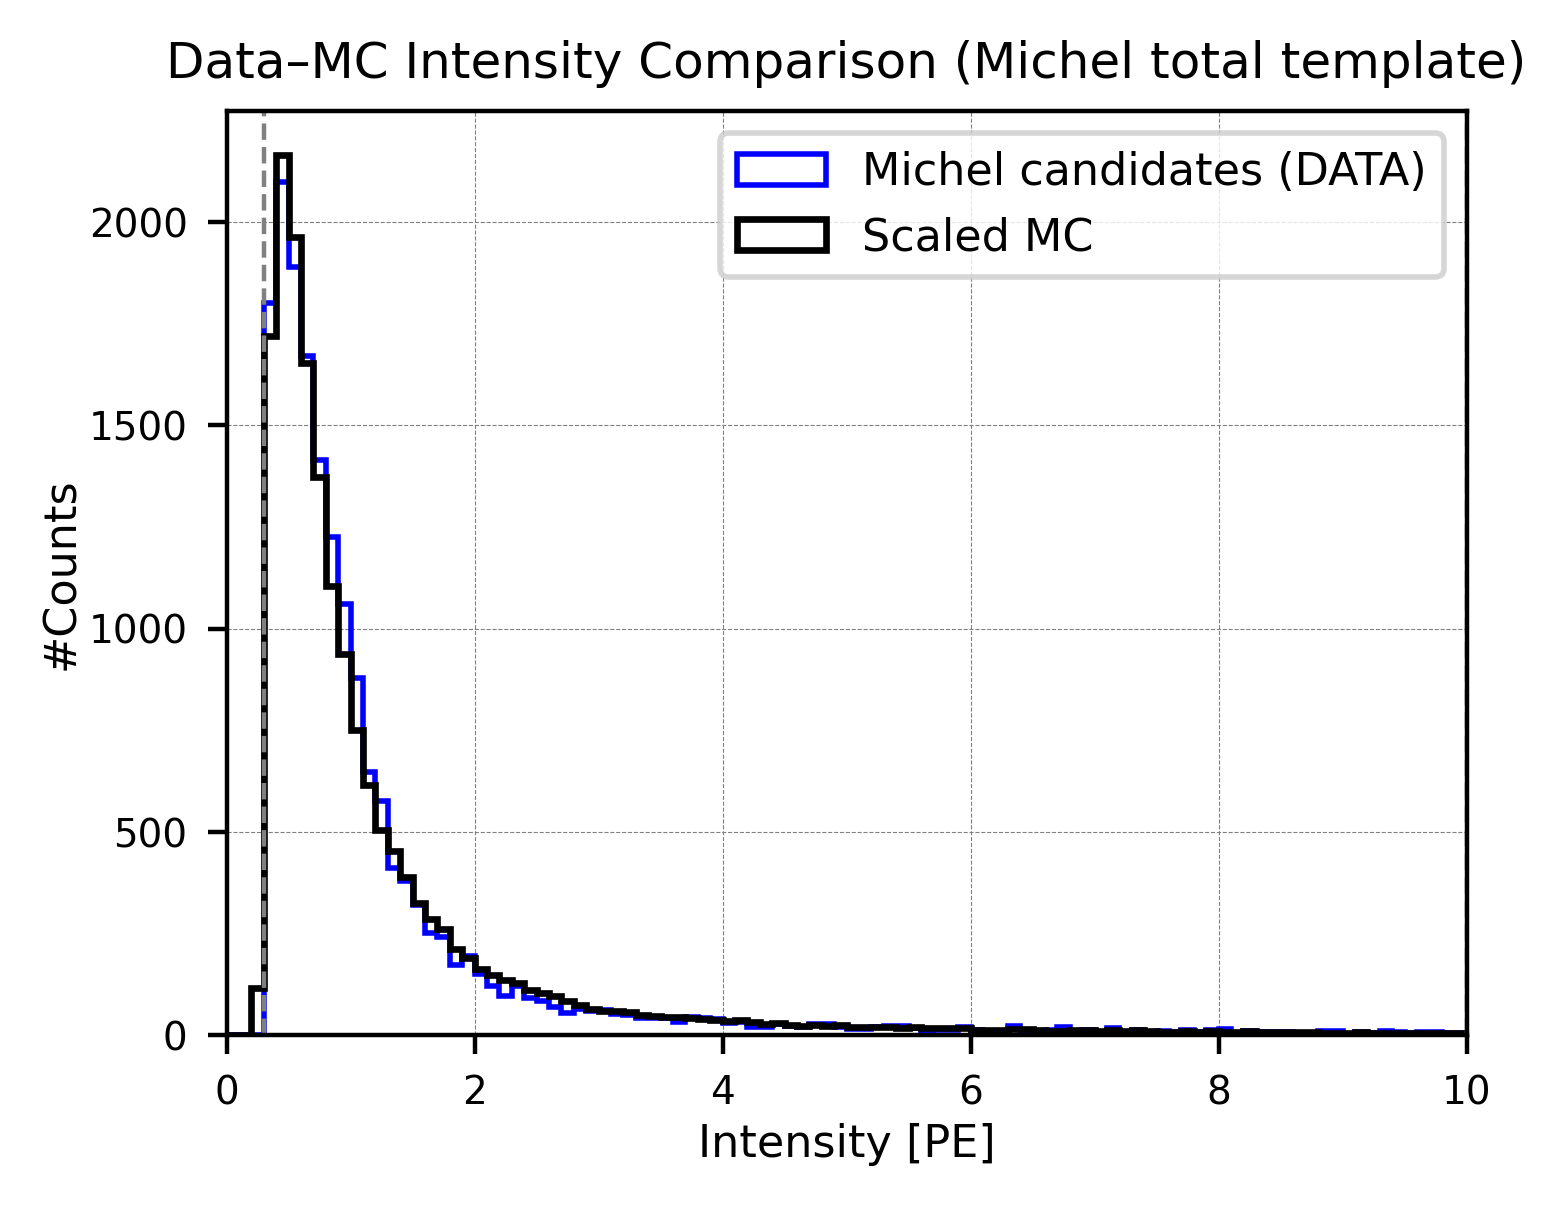

In [194]:
# Plotting=============================================================================
plt.figure(figsize=(4,3), dpi=400)

# ============================================================
# Plot settings
# ============================================================
plot_min = 0.0
plot_max = 10.0
plot_bin_width = 0.1
plot_bins = np.arange(plot_min, plot_max + plot_bin_width, plot_bin_width)

# ============================================================
# 1. Apply the fitted transformation to total MC template
# ============================================================
scale_template = m.values["scale_template"]
shift_template = m.values["shift_template"]

template_MC_scaled = scale_template * miInt_total_MC + shift_template

# ============================================================
# 2. DATA histogram
# ============================================================
plt.hist(
    miInt_diff,
    bins=plot_bins,
    range=(plot_min, plot_max),
    histtype='step',
    edgecolor='blue',
    linewidth=1.0,
    label="Michel candidates (DATA)"
)

# ============================================================
# 3. Total MC template histogram (scaled)
# ============================================================
n_data = len(miInt_diff)
n_template = len(template_MC_scaled)

weight_template = n_data / n_template
weights_template = np.full(n_template, weight_template)

plt.hist(
    template_MC_scaled,
    bins=plot_bins,
    range=(plot_min, plot_max),
    histtype='step',
    linewidth=1.2,
    color='black',
    weights=weights_template,
    label="Scaled MC"
)

# Show fit range
plt.axvline(fit_min, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(fit_max, color='gray', linestyle='--', linewidth=0.8)

# ============================================================
# 4. Plot styling
# ============================================================
plt.xlim(0, plot_max)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)

# plt.ylim(1, 2000)
# plt.yscale('log')

plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.title('Data–MC Intensity Comparison (Michel total template)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")

plt.show()

<br />

### Third Peak Processing:


In [233]:
from iminuit import Minuit
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Fit settings for non-zero positive part only
# ============================================================
fit_min = 0.3
fit_max = 10.0
bin_width = 0.1

bins = np.arange(fit_min, fit_max + bin_width, bin_width)

print(f"Third Peak non-zero fit window = [{fit_min}, {fit_max}]")
print(f"Third Peak non-zero bin width  = {bin_width}")
print(f"Number of bins                 = {len(bins) - 1}")

# ============================================================
# 2. Input arrays
# ============================================================
data_all = np.asarray(thirdInt_diff, dtype=float)
mc_all = np.asarray(thirdInt_total_MC, dtype=float)

# ============================================================
# 3. Zero-entry summary
# ============================================================
n_data_all = len(data_all)
n_mc_all = len(mc_all)

n_data_zero = np.sum(data_all == 0.0)
n_mc_zero = np.sum(mc_all == 0.0)

f_data_zero = n_data_zero / n_data_all if n_data_all > 0 else 0.0
f_mc_zero = n_mc_zero / n_mc_all if n_mc_all > 0 else 0.0

print("\n==================================================")
print("Third Peak zero-entry summary")
print("==================================================")
print(f"DATA total         = {n_data_all}")
print(f"DATA zero entries  = {n_data_zero}")
print(f"DATA zero fraction = {f_data_zero:.6f}")

print(f"MC total           = {n_mc_all}")
print(f"MC zero entries    = {n_mc_zero}")
print(f"MC zero fraction   = {f_mc_zero:.6f}")

# ============================================================
# 4. Keep only non-zero entries in fit region
#    Here 'non-zero' is effectively implemented as >= fit_min
# ============================================================
data_nz = data_all[data_all >= fit_min]
mc_nz = mc_all[mc_all >= fit_min]

n_data_nz = len(data_nz)
n_mc_nz = len(mc_nz)

print("\n==================================================")
print("Third Peak non-zero summary")
print("==================================================")
print(f"DATA non-zero entries used in fit = {n_data_nz}")
print(f"MC non-zero entries used in fit   = {n_mc_nz}")

if n_data_nz == 0:
    raise RuntimeError("No non-zero DATA entries found in fit range.")

if n_mc_nz == 0:
    raise RuntimeError("No non-zero MC entries found in fit range.")

# ============================================================
# 5. Helper: linear transformation
# ============================================================
def transform_template(arr, scale, shift):
    return scale * arr + shift

# ============================================================
# 6. DATA histogram using non-zero entries only
# ============================================================
data_hist, _ = np.histogram(data_nz, bins=bins)
data_hist = data_hist.astype(float)

# ============================================================
# 7. Chi2 definition using non-zero entries only
#    Normalization is based on non-zero DATA statistics
# ============================================================
def chi2_template(scale_template, shift_template):

    if scale_template <= 0:
        return 1e30

    mc_transformed = transform_template(mc_nz, scale_template, shift_template)

    # Keep only transformed MC entries still inside fit region
    mc_transformed_in = mc_transformed[
        (mc_transformed >= fit_min) & (mc_transformed <= fit_max)
    ]

    if len(mc_transformed_in) == 0:
        return 1e30

    template_hist, _ = np.histogram(mc_transformed_in, bins=bins)
    template_hist = template_hist.astype(float)

    if np.sum(template_hist) <= 0:
        return 1e30

    template_shape = template_hist / np.sum(template_hist)

    # Normalize only to non-zero DATA statistics
    prediction = n_data_nz * template_shape

    sigma2 = data_hist + prediction + 1.0
    chi2 = np.sum((data_hist - prediction) ** 2 / sigma2)

    return chi2

# ============================================================
# 8. Run fit
# ============================================================
m = Minuit(
    chi2_template,
    scale_template=1.0,
    shift_template=0.0
)

m.errordef = Minuit.LEAST_SQUARES
m.limits["scale_template"] = (1e-6, None)

m.simplex()
m.migrad()
m.hesse()

scale_best = m.values["scale_template"]
shift_best = m.values["shift_template"]

scale_err = m.errors["scale_template"]
shift_err = m.errors["shift_template"]

# ============================================================
# 9. Build best-fit prediction
# ============================================================
mc_best = transform_template(mc_nz, scale_best, shift_best)
mc_best_in = mc_best[(mc_best >= fit_min) & (mc_best <= fit_max)]

template_hist, _ = np.histogram(mc_best_in, bins=bins)
template_hist = template_hist.astype(float)

template_shape = template_hist / np.sum(template_hist)
prediction = n_data_nz * template_shape

sigma2 = data_hist + prediction + 1.0
chi2_val = np.sum((data_hist - prediction) ** 2 / sigma2)

ndf = len(data_hist) - 2
chi2_ndf = chi2_val / ndf if ndf > 0 else np.nan

# ============================================================
# 10. Print fit result
# ============================================================
print("\n==================================================")
print("Third Peak non-zero template fit result")
print("==================================================")
print(f"success        = {m.fmin.is_valid}")
print(f"scale_template = {scale_best:.6f} +/- {scale_err:.6f}")
print(f"shift_template = {shift_best:.6f} +/- {shift_err:.6f}")
print(f"chi2           = {chi2_val:.3f}")
print(f"ndf            = {ndf}")
print(f"chi2/ndf       = {chi2_ndf:.3f}")

print("\nFit diagnostics")
print(m.fmin)



Third Peak non-zero fit window = [0.3, 10.0]
Third Peak non-zero bin width  = 0.1
Number of bins                 = 97

Third Peak zero-entry summary
DATA total         = 17742
DATA zero entries  = 2571
DATA zero fraction = 0.144910
MC total           = 138842
MC zero entries    = 9264
MC zero fraction   = 0.066723

Third Peak non-zero summary
DATA non-zero entries used in fit = 15171
MC non-zero entries used in fit   = 129578

Third Peak non-zero template fit result
success        = False
scale_template = 0.545050 +/- 0.000006
shift_template = 0.138452 +/- 0.000009
chi2           = 76.678
ndf            = 95
chi2/ndf       = 0.807

Fit diagnostics
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 76.68                      │              Nfcn = 372              │
│ EDM = 0.00611 (Goal: 0.0002)     │    

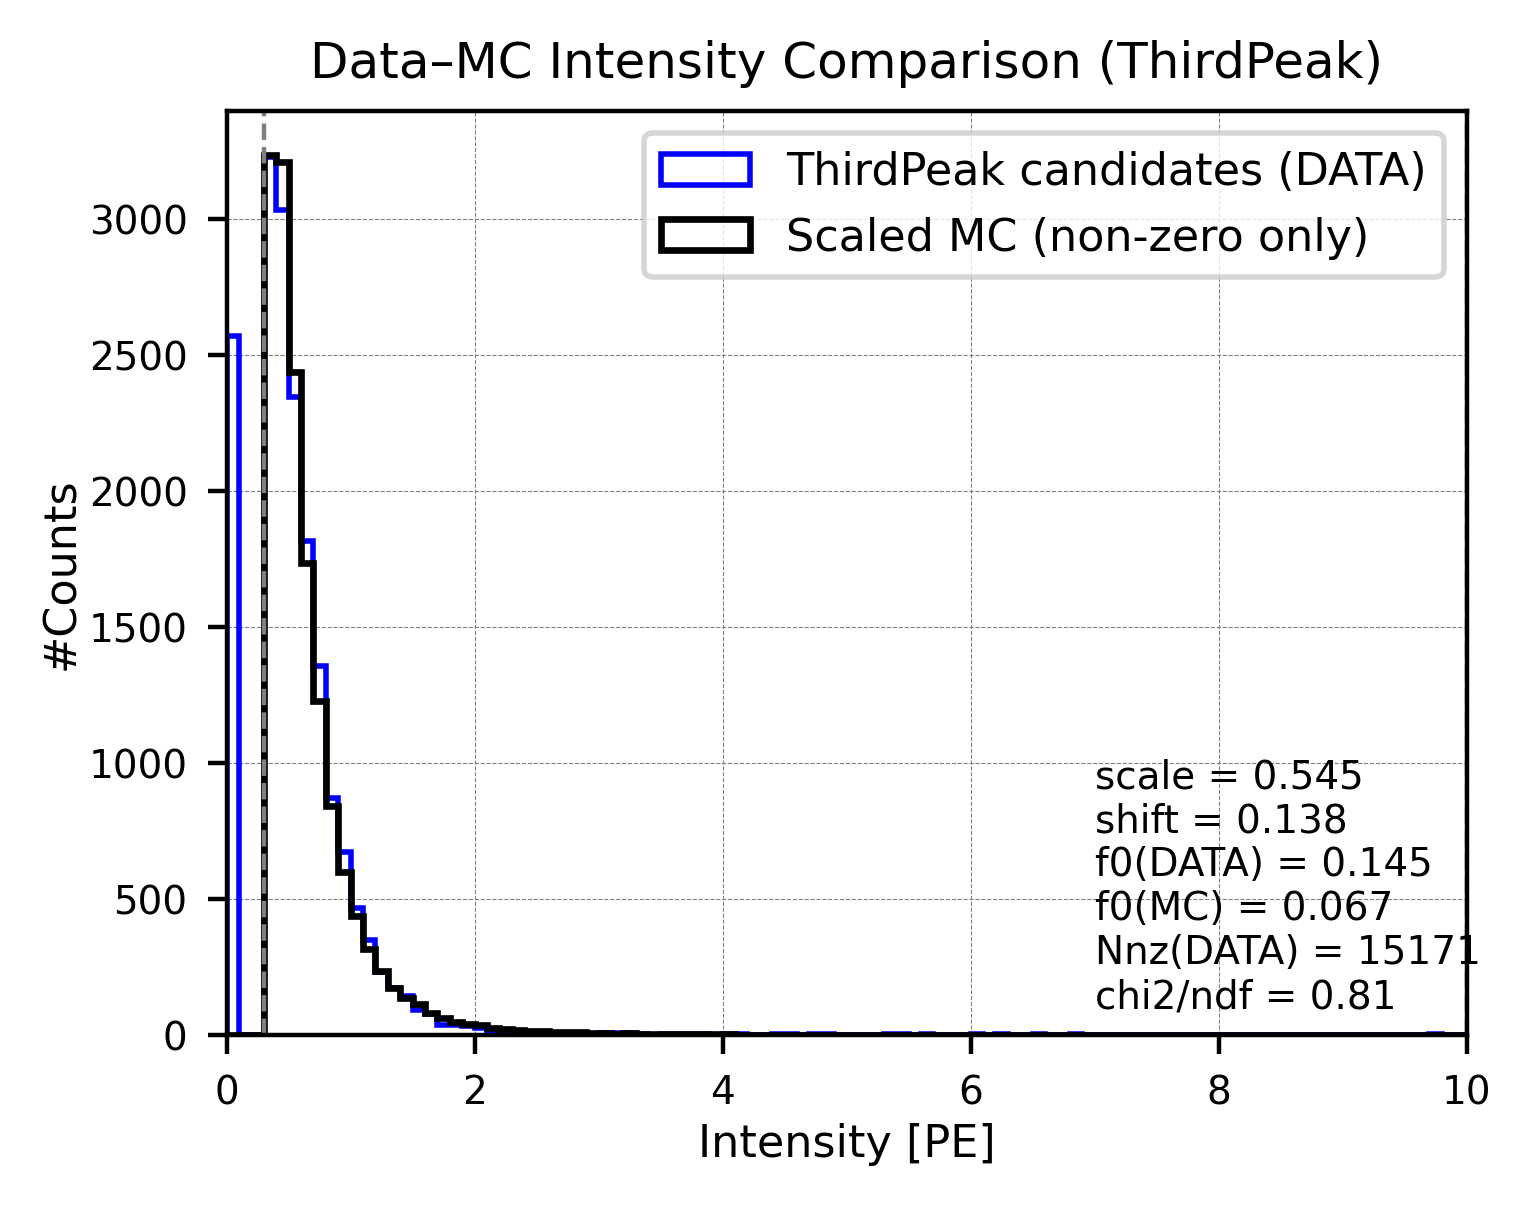

In [235]:
# Plotting=============================================================================
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3), dpi=400)

# ============================================================
# Plot settings
# ============================================================
plot_min = 0.0
plot_max = 10.0
plot_bin_width = 0.1
plot_bins = np.arange(plot_min, plot_max + plot_bin_width, plot_bin_width)

# ============================================================
# 1. Extract fit parameters
# ============================================================
scale_template = m.values["scale_template"]
shift_template = m.values["shift_template"]

# ============================================================
# 2. Input arrays
# ============================================================
data_all = np.asarray(thirdInt_diff, dtype=float)
mc_all   = np.asarray(thirdInt_total_MC, dtype=float)

# ============================================================
# 3. Define non-zero samples used in the fit
#    Here non-zero means entries inside the fit region
# ============================================================
data_nz = data_all[data_all >= fit_min]
mc_nz   = mc_all[mc_all >= fit_min]

# Apply scaling only to non-zero MC entries
mc_nz_scaled = scale_template * mc_nz + shift_template

# Keep only scaled MC entries inside plotting range
mc_nz_scaled_in = mc_nz_scaled[
    (mc_nz_scaled >= plot_min) & (mc_nz_scaled <= plot_max)
]

# ============================================================
# 4. Zero fractions (for display only)
# ============================================================
f_data_zero = np.sum(data_all == 0.0) / len(data_all)
f_mc_zero   = np.sum(mc_all == 0.0) / len(mc_all)

# ============================================================
# 5. DATA histogram
#    Full DATA shown, including zero entries
# ============================================================
plt.hist(
    data_all,
    bins=plot_bins,
    range=(plot_min, plot_max),
    histtype='step',
    edgecolor='blue',
    linewidth=1.0,
    label="ThirdPeak candidates (DATA)"
)

# ============================================================
# 6. Scaled MC histogram
#    Normalize to number of non-zero DATA events
# ============================================================
n_data_nz = len(data_nz)
n_mc_scaled = len(mc_nz_scaled_in)

if n_mc_scaled > 0:
    weight_template = n_data_nz / n_mc_scaled
    weights_template = np.full(n_mc_scaled, weight_template)

    plt.hist(
        mc_nz_scaled_in,
        bins=plot_bins,
        range=(plot_min, plot_max),
        histtype='step',
        linewidth=1.2,
        color='black',
        weights=weights_template,
        label="Scaled MC (non-zero only)"
    )

# ============================================================
# 7. Show fit range
# ============================================================
plt.axvline(fit_min, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(fit_max, color='gray', linestyle='--', linewidth=0.8)

# ============================================================
# 8. Text box
# ============================================================
plt.text(
    0.70, 0.30,
    f"scale = {scale_template:.3f}\n"
    f"shift = {shift_template:.3f}\n"
    f"f0(DATA) = {f_data_zero:.3f}\n"
    f"f0(MC) = {f_mc_zero:.3f}\n"
    f"Nnz(DATA) = {n_data_nz}\n"
    f"chi2/ndf = {chi2_ndf:.2f}",
    transform=plt.gca().transAxes,
    fontsize=7,
    verticalalignment='top'
)

# ============================================================
# 9. Plot styling
# ============================================================
plt.xlim(plot_min, plot_max)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)

# plt.ylim(1, 2000)
# plt.yscale('log')

plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.title('Data–MC Intensity Comparison (ThirdPeak)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")

plt.show()

<br />
<br />
<br />
<br />

### Purification 4:  Michel Intensity / Muon Intensity:

After lifetime cut (cut 3):
# Events:  17742

Total events        = 17742
Mean Michel score   = 0.655
N(score > 0.8)      = 5214
Fraction > 0.8      = 0.294

(michel Intensity) / (muon intensity) (Cut 4):----------
Efficiency (cut4 / cut3):  6708 / 17742 (37.81%)

Total events        = 6708
Mean Michel score   = 0.680
N(score > 0.8)      = 2208
Fraction > 0.8      = 0.329


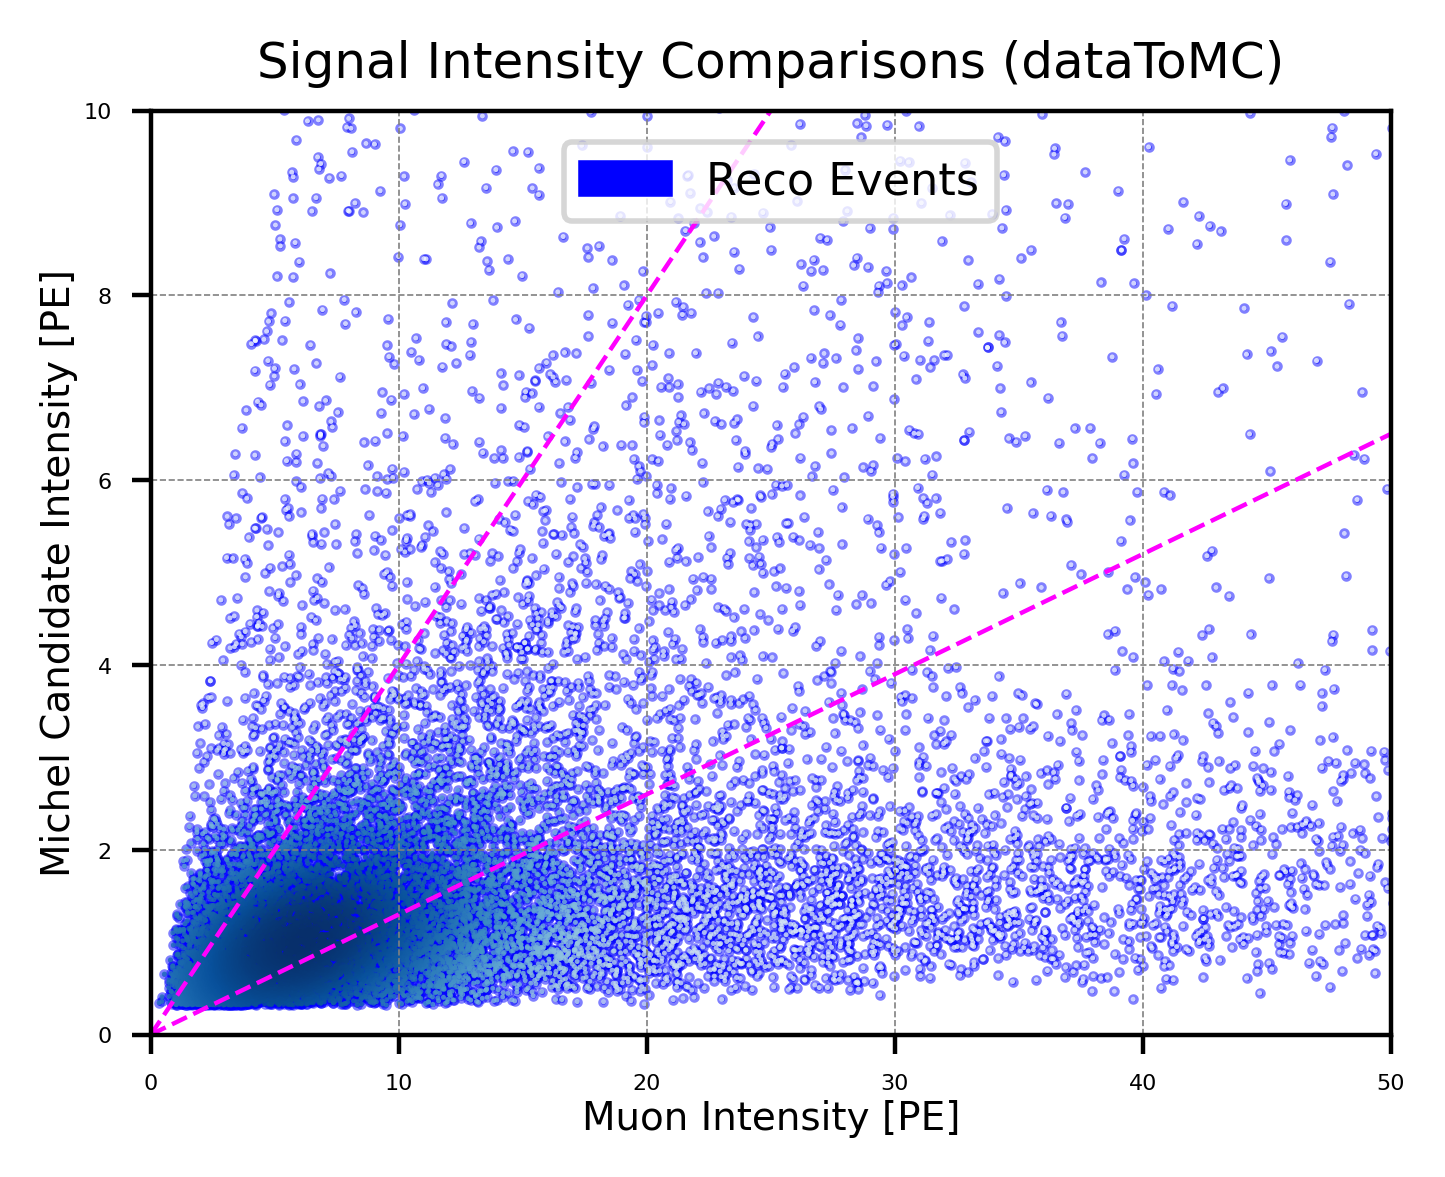


For Purify 4----------------------
ChatGPT (20260311): The 1D Michel scaling is a useful first-order correction, 
but the ratio variable carries additional information that is not captured by that 1D correction.


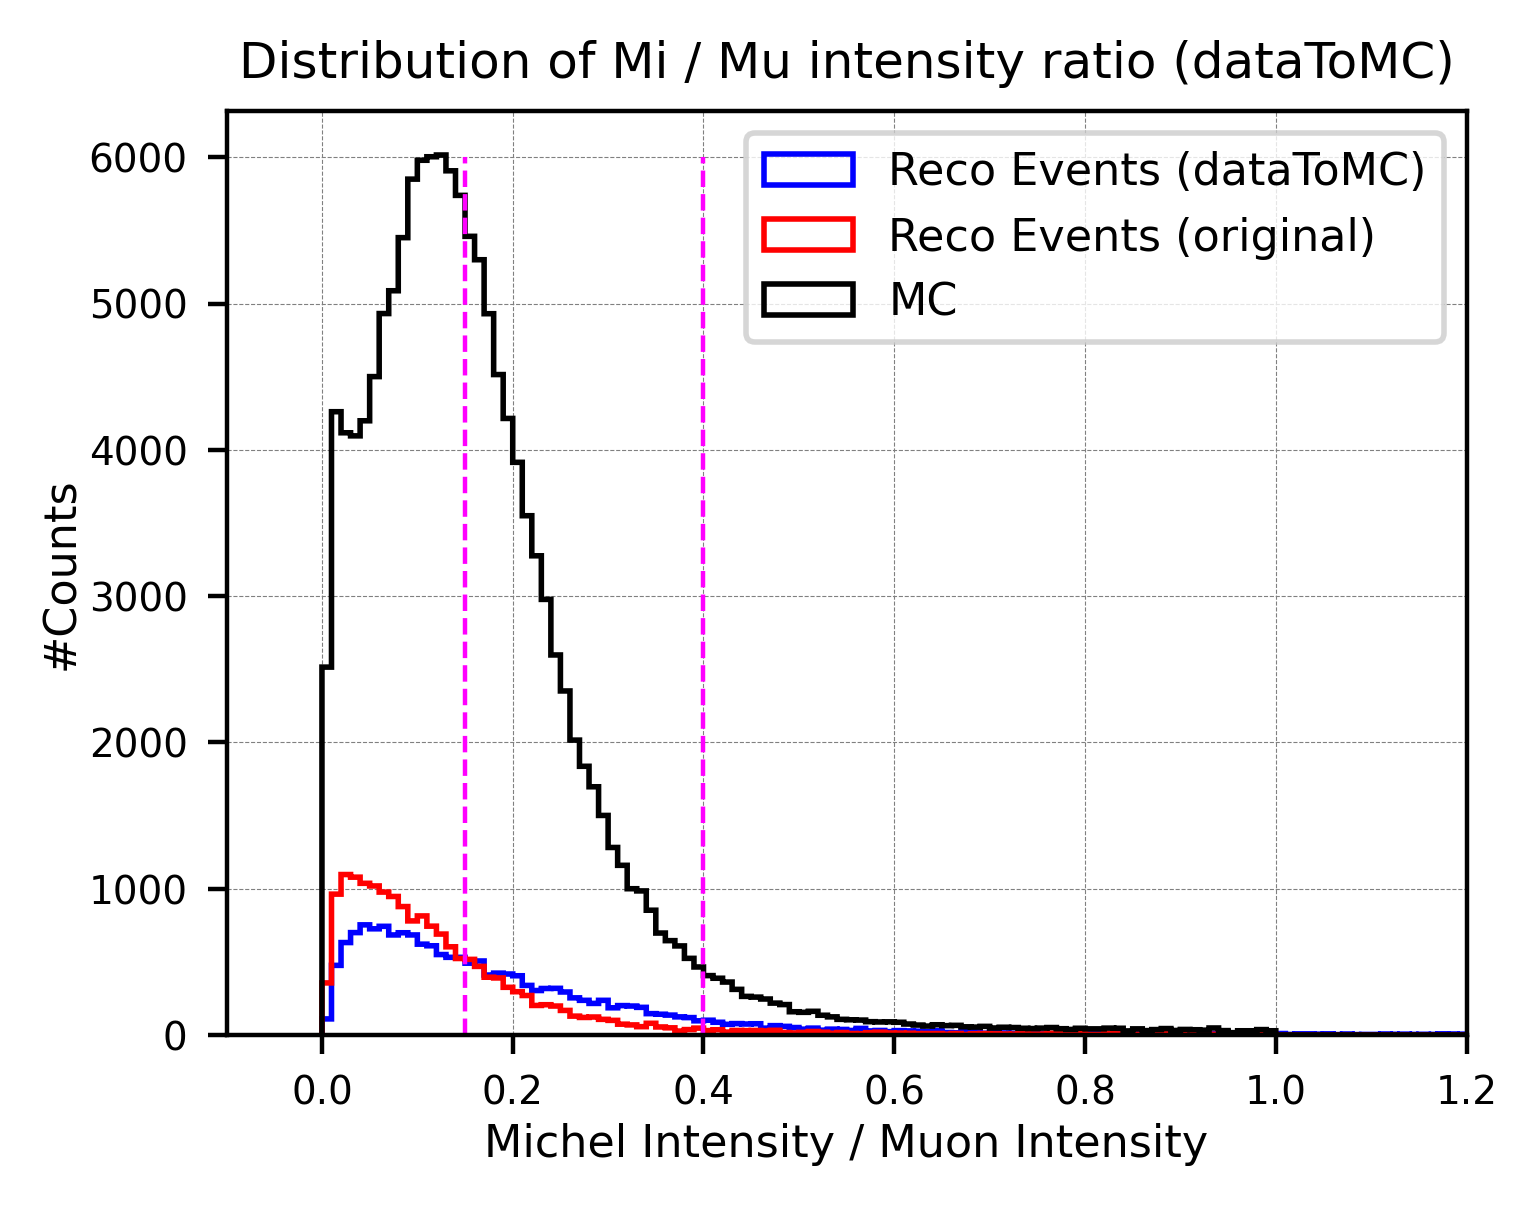

In [236]:
#Adjust and apply scaling===========================================
x_scale_muMC = 1.0
x_shift_muMC = 0.0

x_scale_miMC = 0.519
x_shift_miMC = 0.134

x_scale_thirdMC = 0.545
x_shift_thirdMC = 0.138


# Convert DATA intensity back to MC-equivalent intensity
def mu_dataToMC(value_data):

    return (value_data - x_shift_muMC) / x_scale_muMC

def michel_dataToMC(value_data):

    return (value_data - x_shift_miMC) / x_scale_miMC

def third_dataToMC(value_data):

    return (value_data - x_shift_thirdMC) / x_scale_thirdMC




#Michel Intensity Cut (Cut 4)================================================
print("After lifetime cut (cut 3):")

print("# Events: ", len(events_newClass))

mScore_total = [ev.michel_score for ev in events_newClass]
#Michel score:
mean_score = sum(mScore_total) / len(mScore_total)
n_high = sum(1 for s in mScore_total if s > 0.8)
frac_high = n_high / len(mScore_total)
print(f"\nTotal events        = {len(mScore_total)}")
print(f"Mean Michel score   = {mean_score:.3f}")
print(f"N(score > 0.8)      = {n_high}")
print(f"Fraction > 0.8      = {frac_high:.3f}")



thre1 = 7.5 / 50
thre2 = 40 / 100

# filter the actual events
events_total_purify4 = [
    ev for ev in events_newClass

#    if ev.muon_intensity != 0 and thre1 <  ev.michel_intensity / ev.muon_intensity < thre2

    #Shifted and scaled data---
    if ev.muon_intensity != 0 and thre1 < michel_dataToMC(ev.michel_intensity) / ev.muon_intensity < thre2

]
#-------------------------------

print("\n(michel Intensity) / (muon intensity) (Cut 4):----------")

print("Efficiency (cut4 / cut3): ", len(events_total_purify4), "/", len(events_newClass),
      "({:.2f}%)".format(len(events_total_purify4)/len(events_newClass)*100))


mScore_purify4 = [ev.michel_score for ev in events_total_purify4]
#Michel score:
mean_score_purify4 = sum(mScore_purify4) / len(mScore_purify4)
n_high_purify4 = sum(1 for s in mScore_purify4 if s > 0.8)
frac_high_purify4 = n_high_purify4 / len(mScore_purify4)
print(f"\nTotal events        = {len(mScore_purify4)}")
print(f"Mean Michel score   = {mean_score_purify4:.3f}")
print(f"N(score > 0.8)      = {n_high_purify4}")
print(f"Fraction > 0.8      = {frac_high_purify4:.3f}")




# For drawing and comparison------------------------------
muInt_dataToMC = mu_dataToMC(muInt_diff)
miInt_dataToMC = michel_dataToMC(miInt_diff)



# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_dataToMC), np.array(miInt_dataToMC)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 500], [0, 65], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 400], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 50) #(-5, 400)
plt.ylim(0, 10) #(-5, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons (dataToMC)', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()






#Ratio distribution===================================
print("\nFor Purify 4----------------------")
print("ChatGPT (20260311): The 1D Michel scaling is a useful first-order correction, " \
"\nbut the ratio variable carries additional information that is not captured by that 1D correction.")

# MC
ratio_diff_purify3_MC = [mi / mu for mi, mu in zip(miInt_total_MC, muInt_total_MC) if mu != 0]
# Data (dataToMC)
ratio_diff_purify3 = [mi / mu for mi, mu in zip(miInt_dataToMC, muInt_dataToMC) if mu != 0]
# Data (original)
ratio_diff_purify3_origin = [mi / mu for mi, mu in zip(miInt_diff, muInt_diff) if mu != 0]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events (dataToMC)")
plt.hist(ratio_diff_purify3_origin, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Reco Events (original)")
# MC
plt.hist(ratio_diff_purify3_MC, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=1.0, label="MC")

plt.plot([0.15, 0.15], [0, 6000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.4, 0.4], [0, 6000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Mi / Mu intensity ratio (dataToMC)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 













#### Cut 5: Michel intensity & Muon intensity: 

After cut 4:
# Events:  6708

Michel Intensity Cut (Cut 5):--------------
Efficiency (cut5 / cut4):  4230 / 6708 (63.06%)


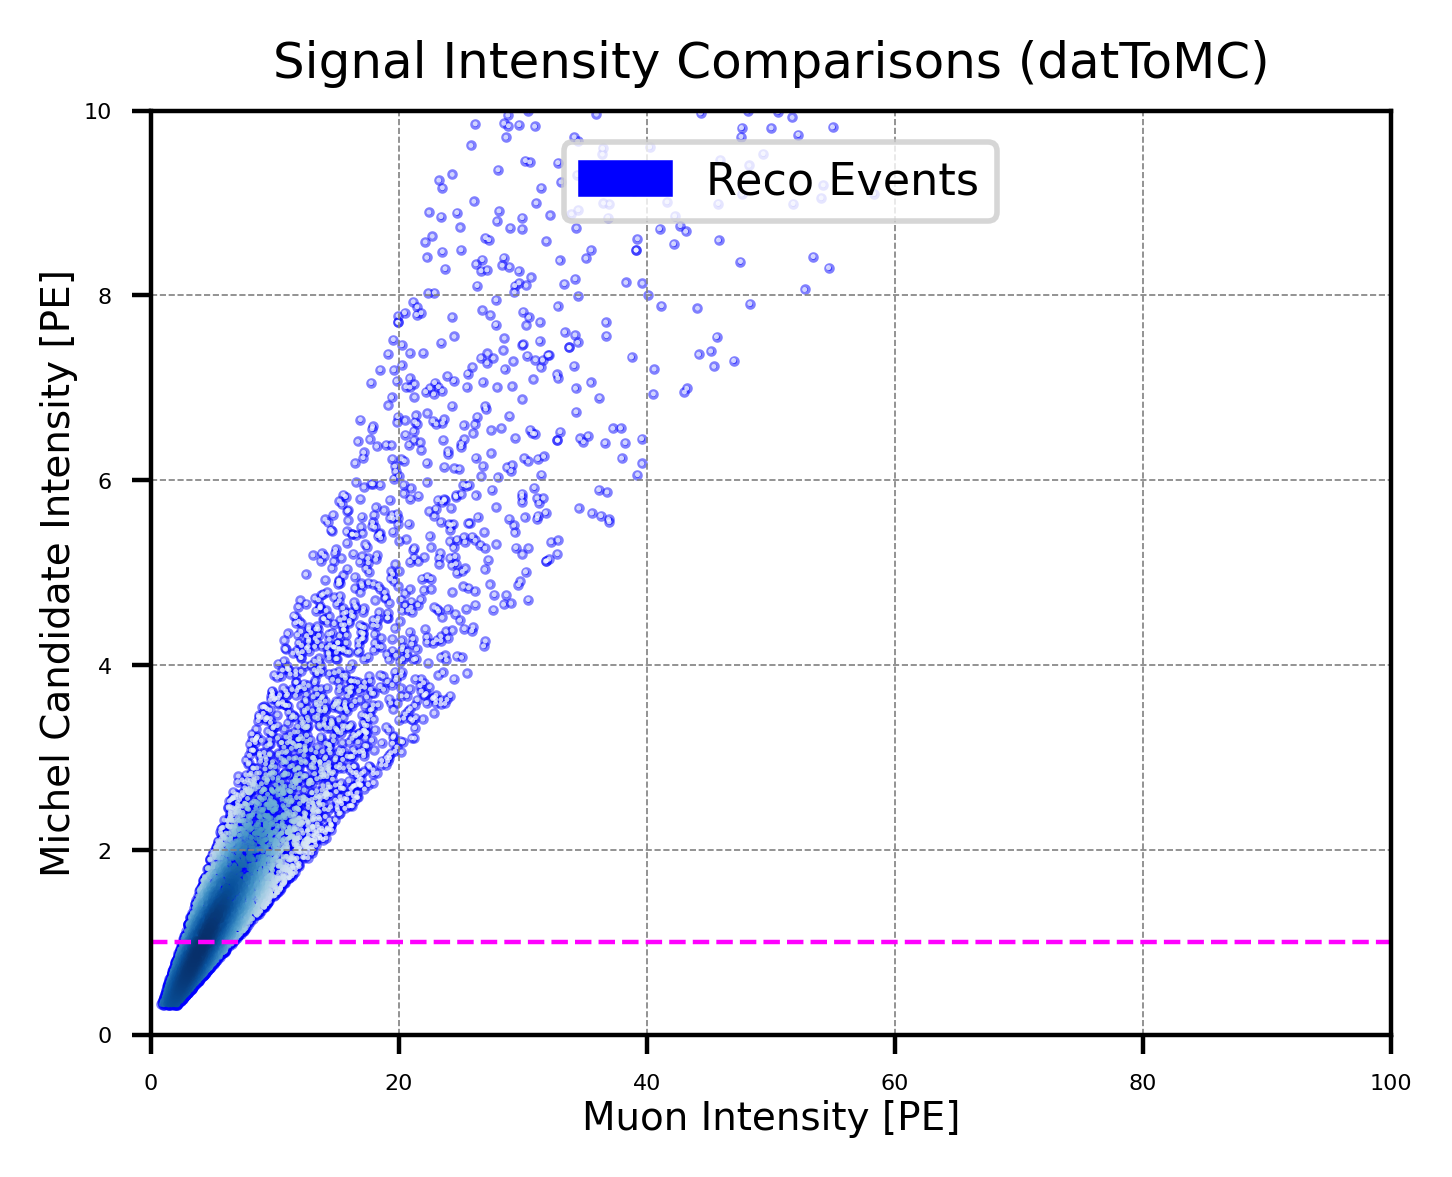


Purify 5----------------------


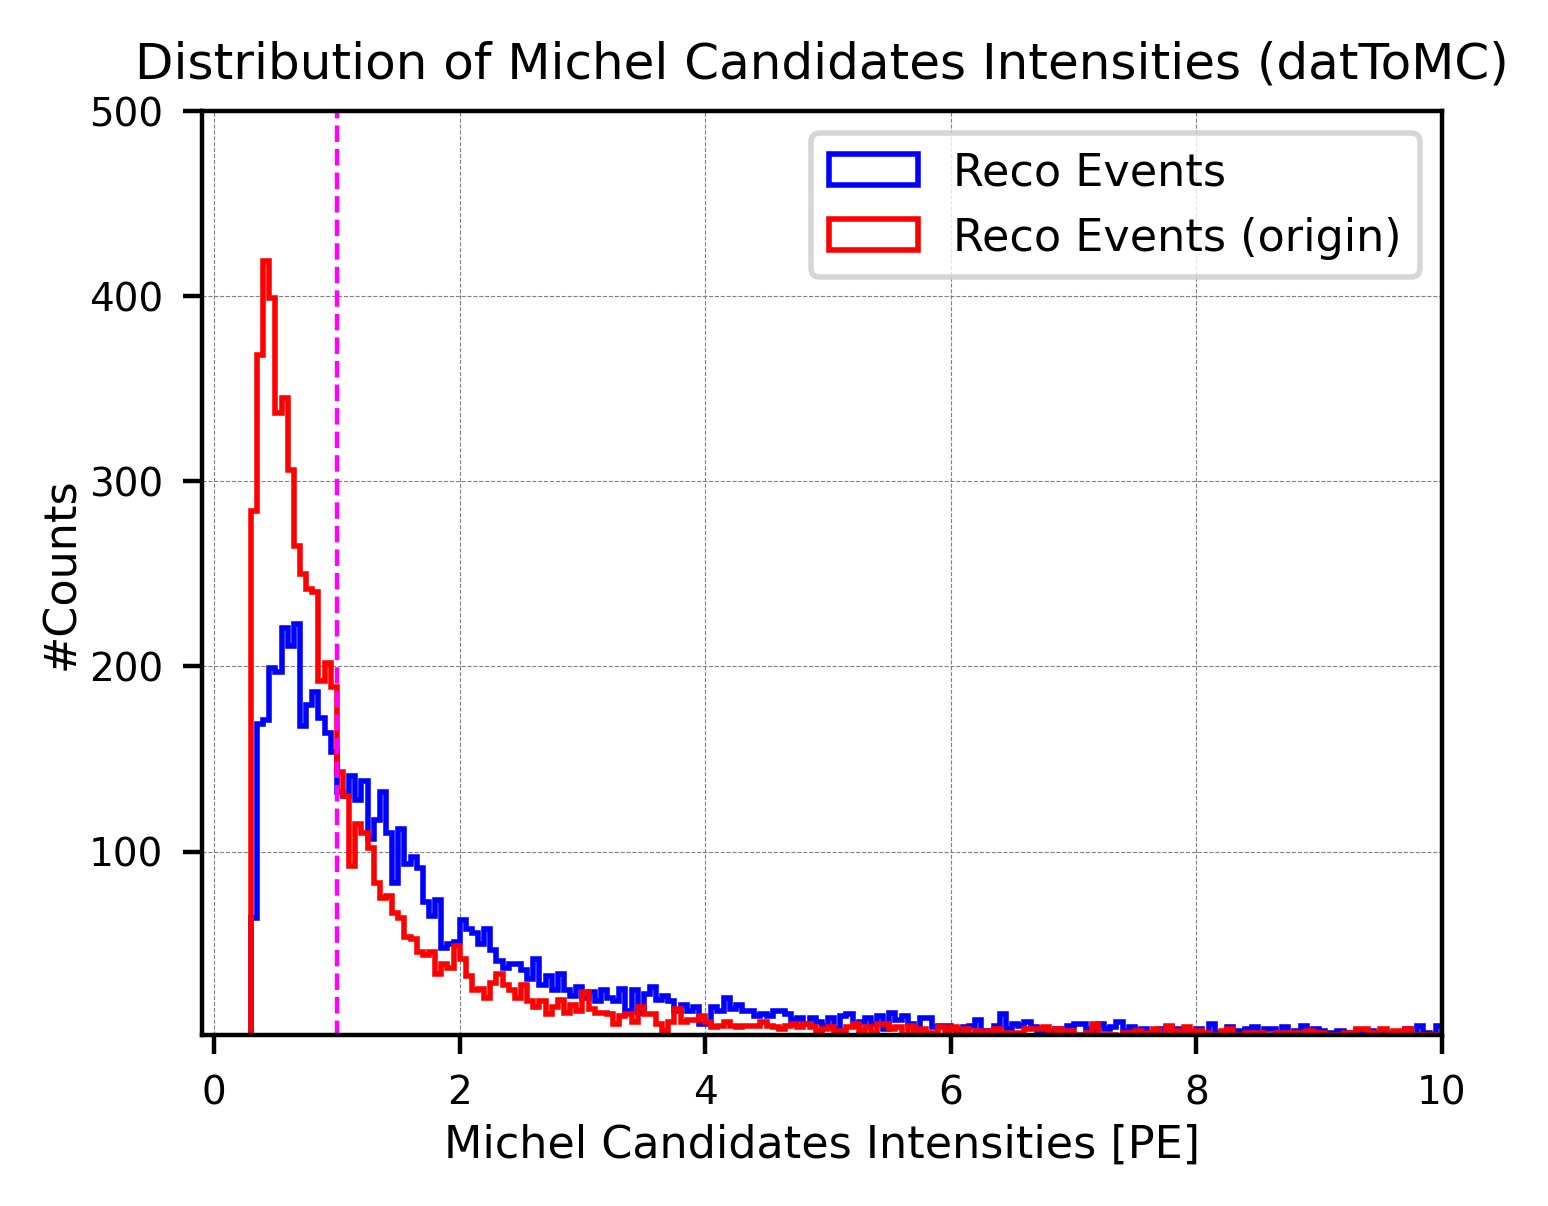

In [237]:
#Michel & Muon Intensities Cut (Cut 5)================================================
print("After cut 4:")

print("# Events: ", len(events_total_purify4))




thre_muInt = 0.3 # mu Int will automatically higher than mi---
thre_miInt = 1.0

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


# filter the actual events
events_total_purify5 = [
    ev for ev in events_total_purify4
    if thre_miInt < michel_dataToMC(ev.michel_intensity) and thre_muInt < ev.muon_intensity
]
#-------------------------------

print("\nMichel Intensity Cut (Cut 5):--------------")

print("Efficiency (cut5 / cut4): ", len(events_total_purify5), "/", len(events_total_purify4),
      "({:.2f}%)".format(len(events_total_purify5)/len(events_total_purify4)*100))








# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================



# For drawing and comparison------------------------------
muInt_tmp = [ev.muon_intensity for ev in events_total_purify4]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify4]

muInt_tmp = np.array(muInt_tmp, dtype=float)
miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
muInt_diff_purify4 = muInt_tmp
miInt_diff_purify4 = michel_dataToMC(miInt_tmp)




plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff_purify4), np.array(miInt_diff_purify4)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 100], [1.0, 1.0], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons (datToMC)', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()







#Michel Intensity distribution===================================
print("\nPurify 5----------------------")

#miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
#miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff_purify4, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")
plt.hist(miInt_tmp, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Reco Events (origin)")

plt.plot([1.0, 1.0], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 10)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities (datToMC)', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#### Mu & Michel intensity distributions after Cut 5:

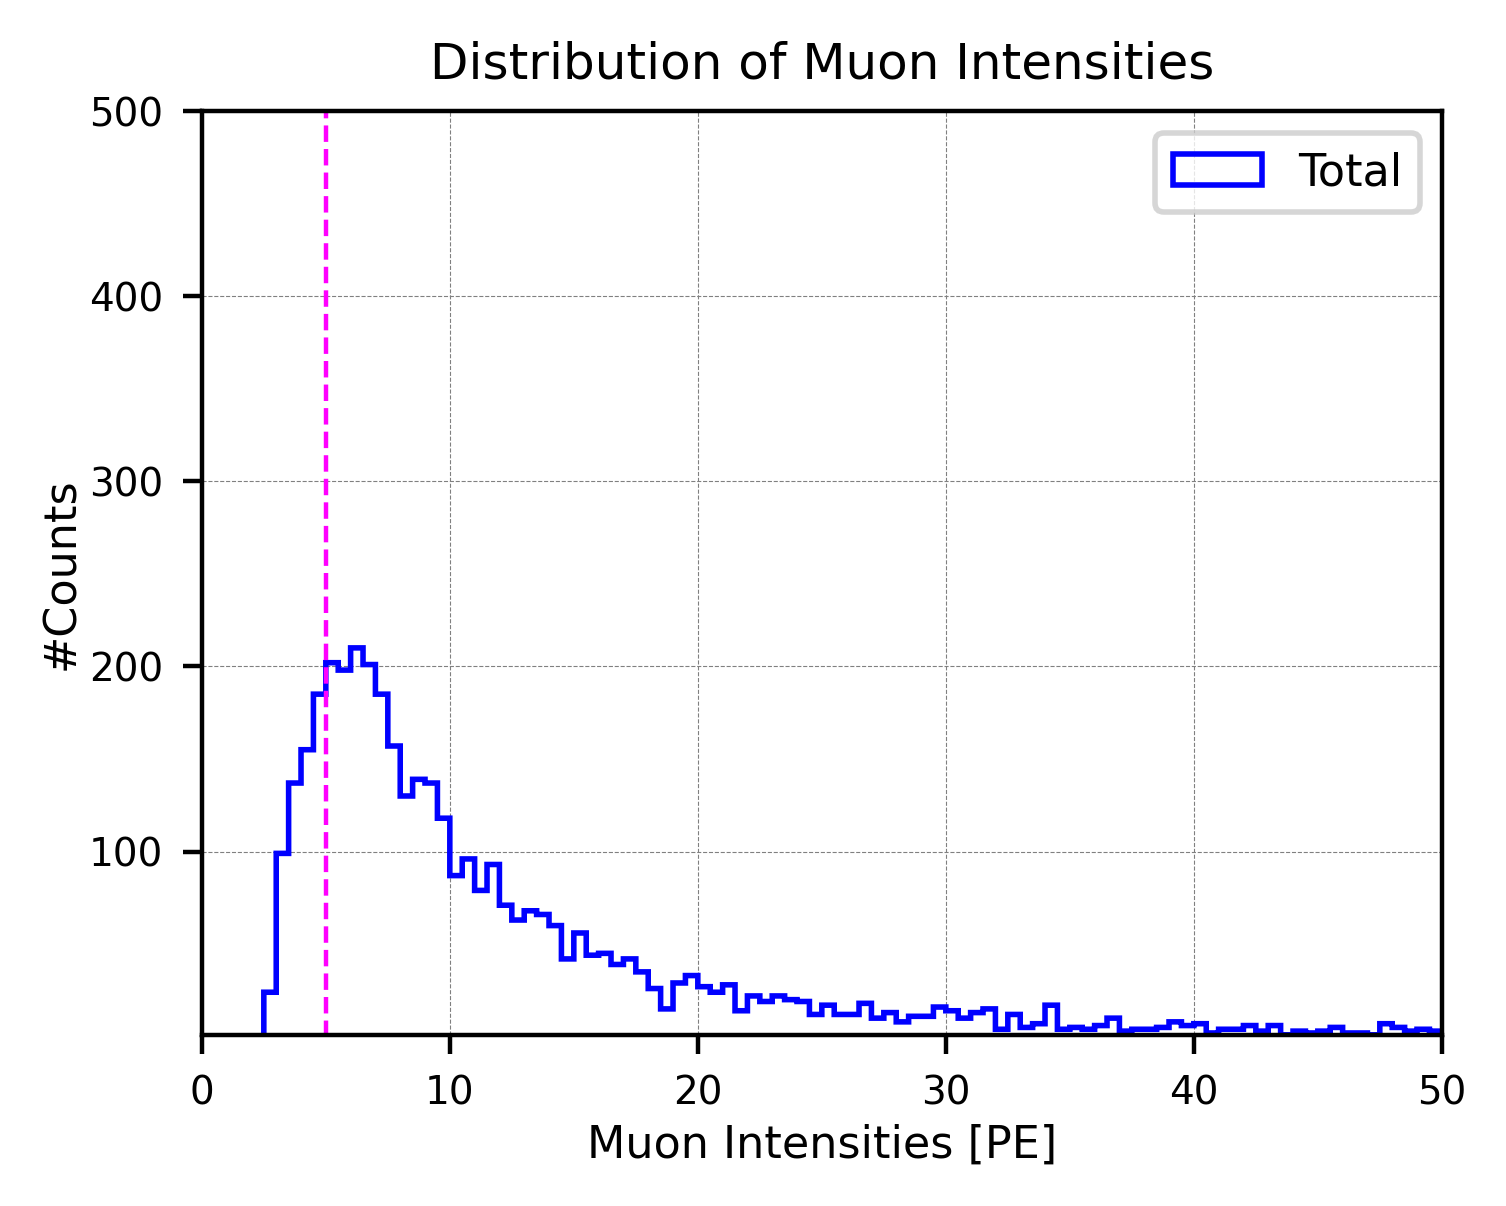

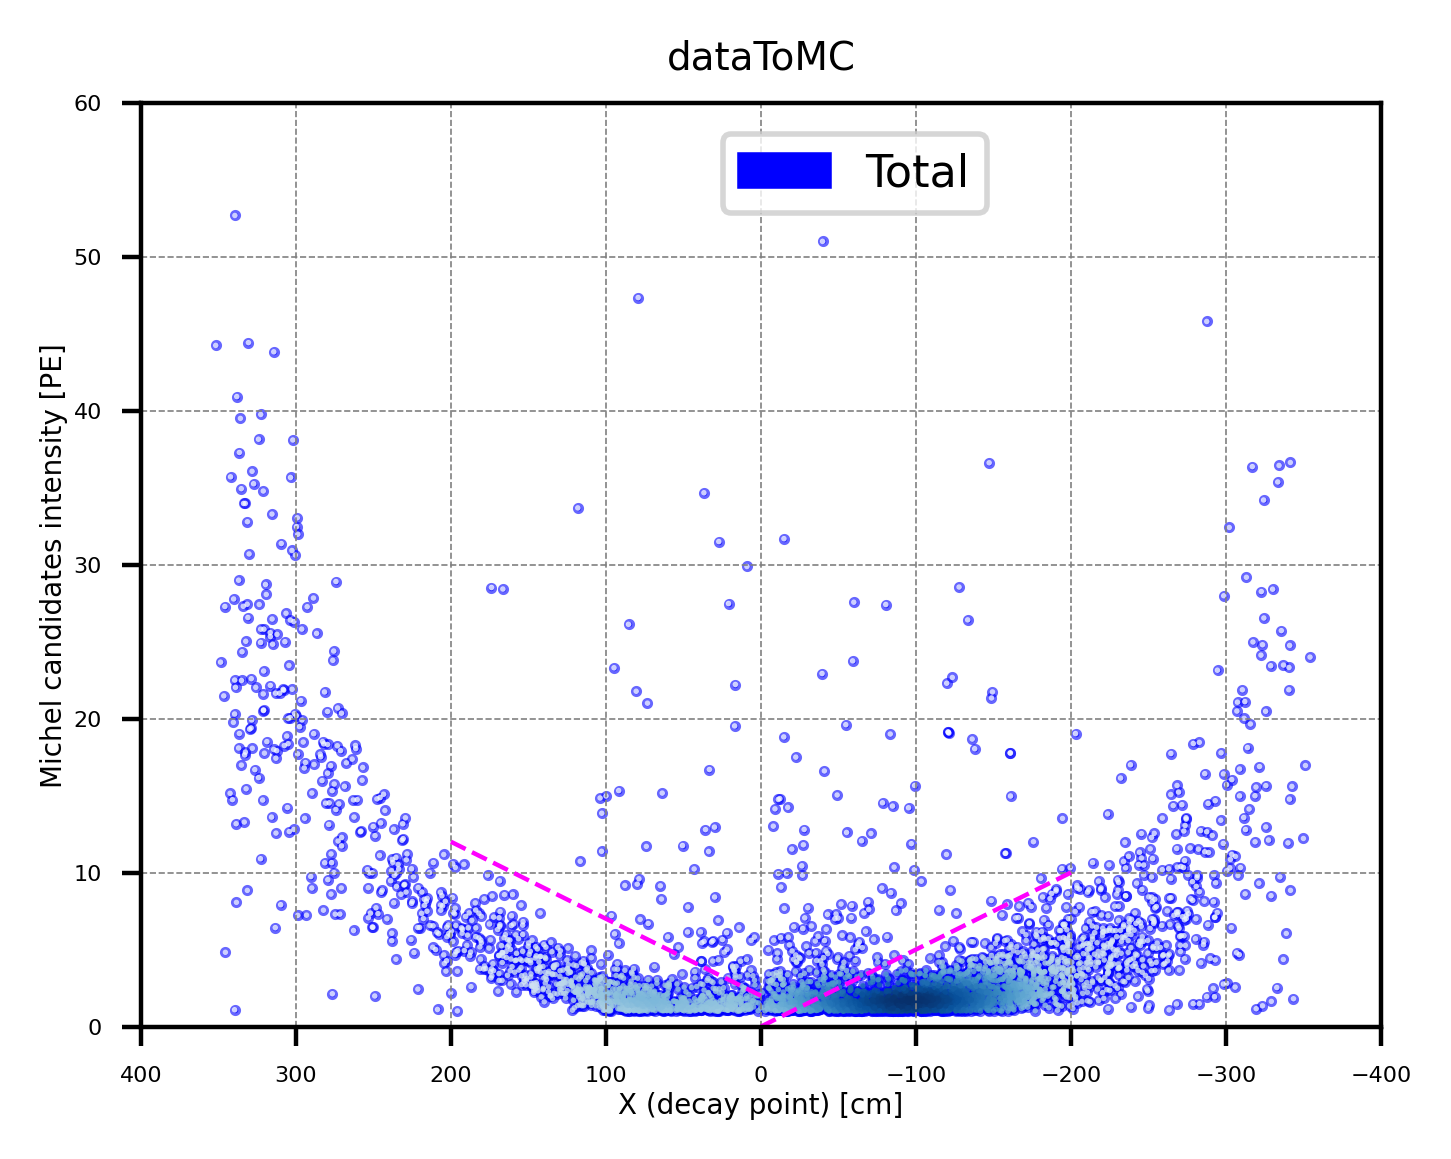

In [238]:
#Muon Intensity distribution===================================

muInt_tmp = [ev.muon_intensity for ev in events_total_purify5]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify5]

muInt_tmp = np.array(muInt_tmp, dtype=float)
miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
muInt_total_purify5 = muInt_tmp
miInt_total_purify5 = michel_dataToMC(miInt_tmp)



plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 300
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_total_purify5, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Total")

plt.plot([5, 5], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Muon Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Muon Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5 = [ev.posX for ev in events_total_purify5]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5, dtype=float)
y1 = np.array(miInt_total_purify5, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('dataToMC', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()

#### Cut 5': Michel signal VS Distance cut:

After cut 5:---------
#events:  4230

After Cut 5' (Michel vs Distance):--------------
Efficiency (cut5' / cut5):  4015 / 4230 (94.92%)


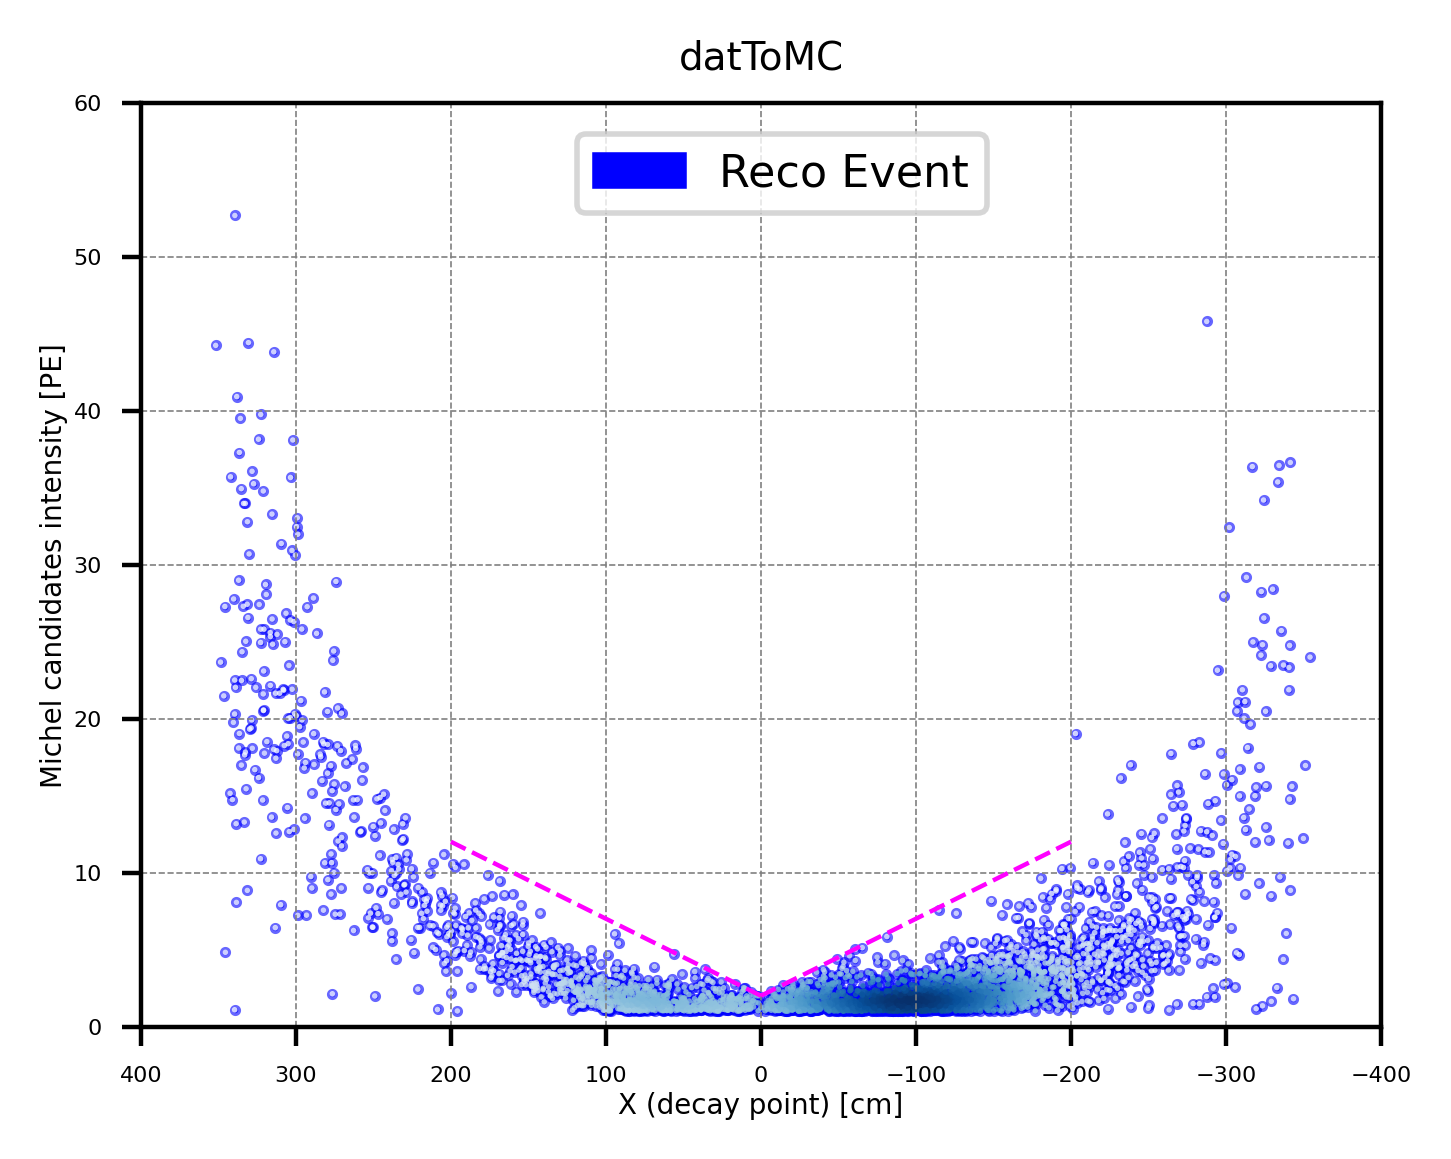

In [253]:
print("After cut 5:---------")

print("#events: ", len(events_total_purify5))



#Michel Peak rise & drop Cut (Cut 5')--------
# --- Define slopes and intercepts for both cuts ---
slope_pos = (7 - 2) / 100.0      # = 0.05
intercept_pos = 2.0

slope_neg = (10 - 0) / (-200 - 0.0)  # = -0.05
# Modified on 2026031: 0.0 to 2.0
intercept_neg = 2.0


#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


def below_line_cut(ev):
    """Return True if event passes both (posX, michel_intensity) cuts."""
    x = ev.posX
#    y = ev.michel_intensity
    y = michel_dataToMC(ev.michel_intensity)#---------------------

    # Region 1: positive side [0, 100]
    if 0 <= x <= 200:
        return y <= intercept_pos + slope_pos * x

    # Region 2: negative side [-200, 0]
    elif -200 <= x <= 0:
        return y <= intercept_neg + slope_neg * x

    # Outside both ranges: no cut
    else:
        return True

# --- Apply the geometric cut to both event classes ---
events_total_purify5P = [ev for ev in events_total_purify5 if below_line_cut(ev)]
#-------------------------------





print("\nAfter Cut 5' (Michel vs Distance):--------------")

print("Efficiency (cut5' / cut5): ", len(events_total_purify5P), "/", len(events_total_purify5),
      "({:.2f}%)".format(len(events_total_purify5P)/len(events_total_purify5)*100))






#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5P = [ev.posX for ev in events_total_purify5P]
miInt_tmp = [ev.michel_intensity for ev in events_total_purify5P]

miInt_tmp = np.array(miInt_tmp, dtype=float)

#scaled (dataToMC)
miInt_total_purify5P = michel_dataToMC(miInt_tmp)

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5P, dtype=float)
y1 = np.array(miInt_total_purify5P, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('datToMC', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Event")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#### Cut 6: Michel peak rise and drop slope: 

After cut 5':---------
#event    :  4015

Michel Peak Rise Drop Slope (Cut 6):--------------
Efficiency (cut6 / cut5'):  3478 / 4015 (86.63%)


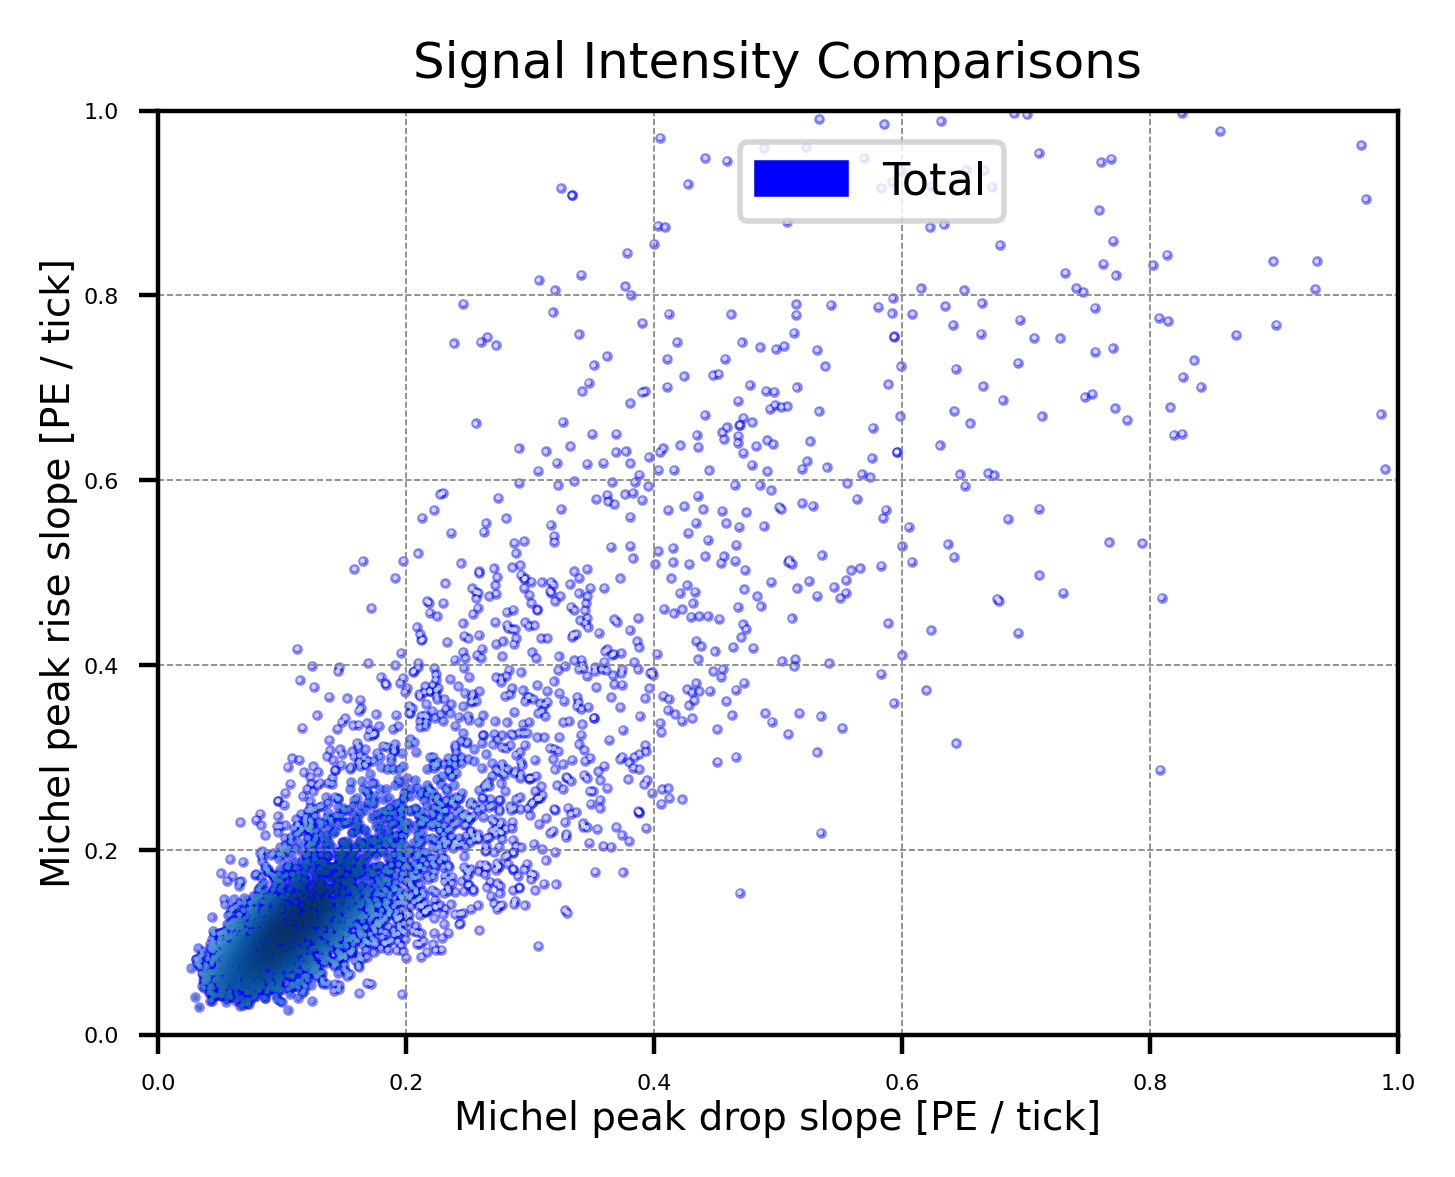

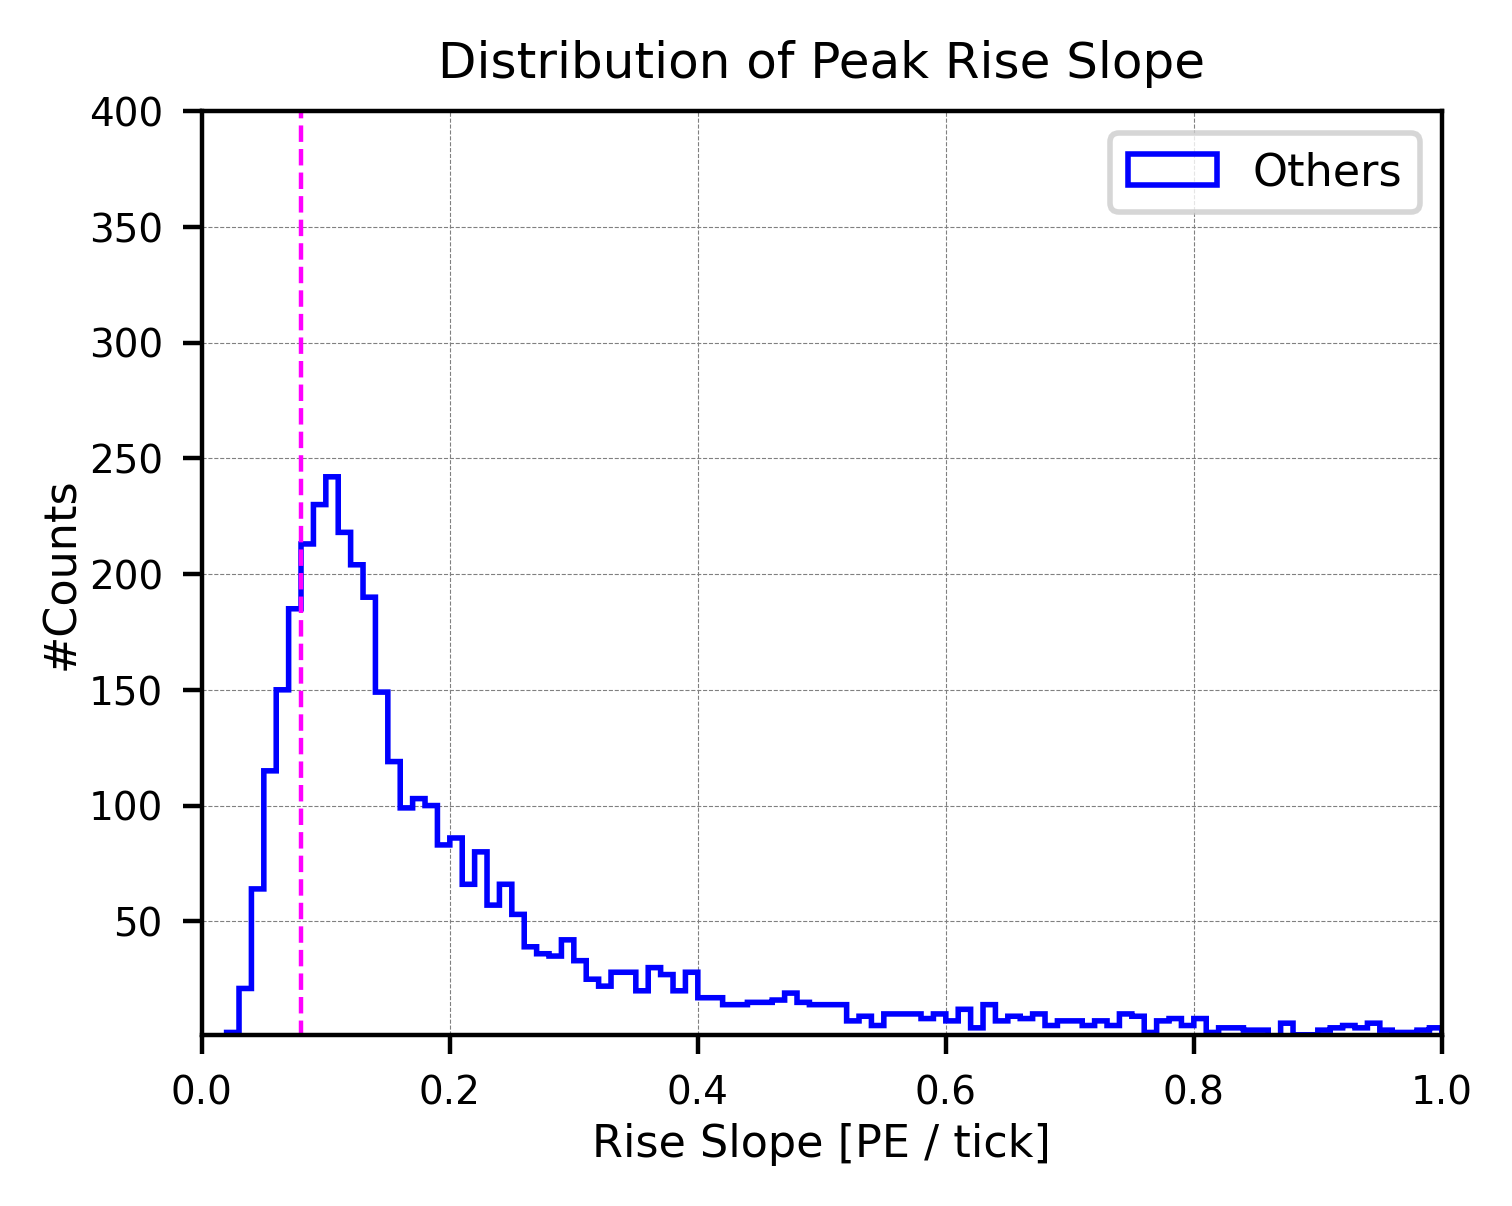

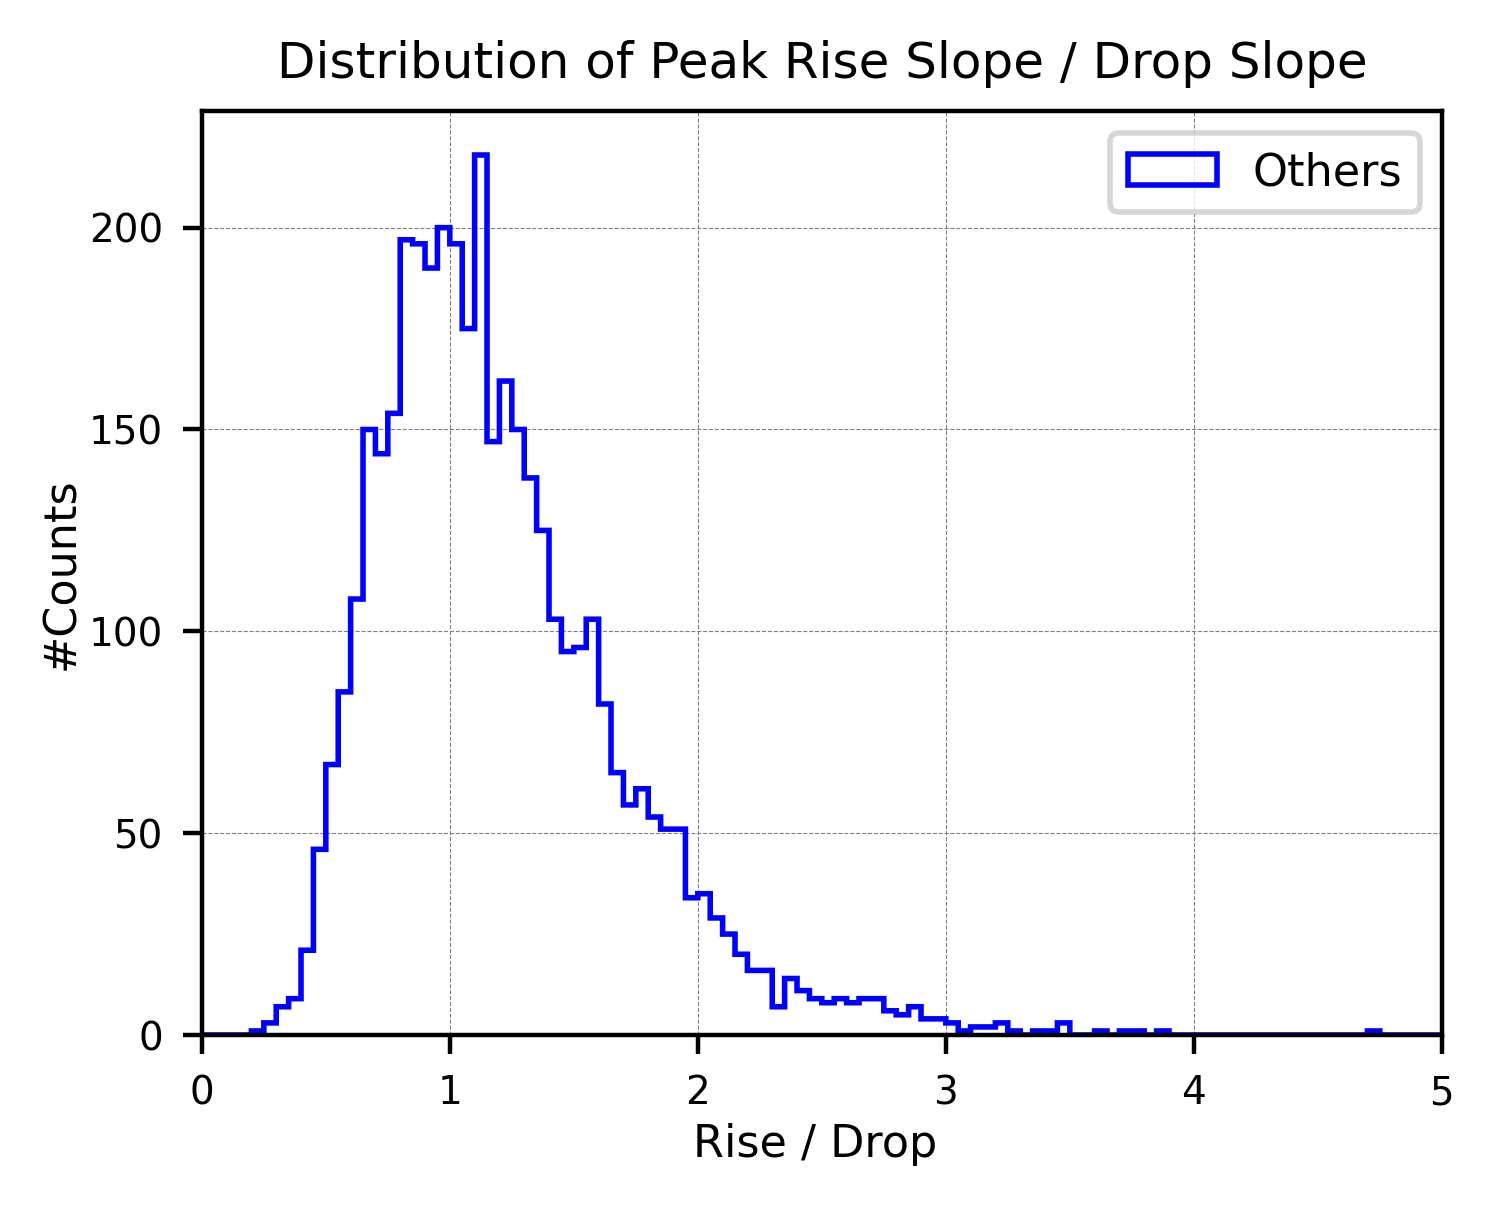

In [254]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 5':---------")
print("#event    : ", len(events_total_purify5P))


#Shu: slope might be unchanged even though the intensity is scaled (peak expansion also modified?)

rise_total_purity5P = [ev.michel_rise for ev in events_total_purify5P]
drop_total_purity5P = [ev.michel_drop for ev in events_total_purify5P]

ratios_total_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_total_purity5P, drop_total_purity5P)
]



thre_rise = 0.08 # mu Int will automatically higher than mi---

#Slope calculation is updated based on miInt update; 20251207---

# filter the actual events
events_total_purify6 = [
    ev for ev in events_total_purify5P
    if thre_rise < ev.michel_rise 
]
#-------------------------------



print("\nMichel Peak Rise Drop Slope (Cut 6):--------------")

print("Efficiency (cut6 / cut5'): ", len(events_total_purify6), "/", len(events_total_purify5P),
      "({:.2f}%)".format(len(events_total_purify6)/len(events_total_purify5P)*100))








# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_total_purity5P), np.array(rise_total_purity5P)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Michel peak drop slope [PE / tick]', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope [PE / tick]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rise_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.08, 0.08], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 1.0)
plt.xlabel('Rise Slope [PE / tick]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 400)
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
plt.hist(ratios_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")


plt.xlim(0, 5)
plt.xlabel('Rise / Drop ', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope / Drop Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 




### Cut 7: 2nd 3rd peak intensity Ratio cut

After cut 6:---------
#event    :  3478

Third / Second peak intensity (Cut 7):--------------
Efficiency (cut7 / cut6):  2679 / 3478 (77.03%)


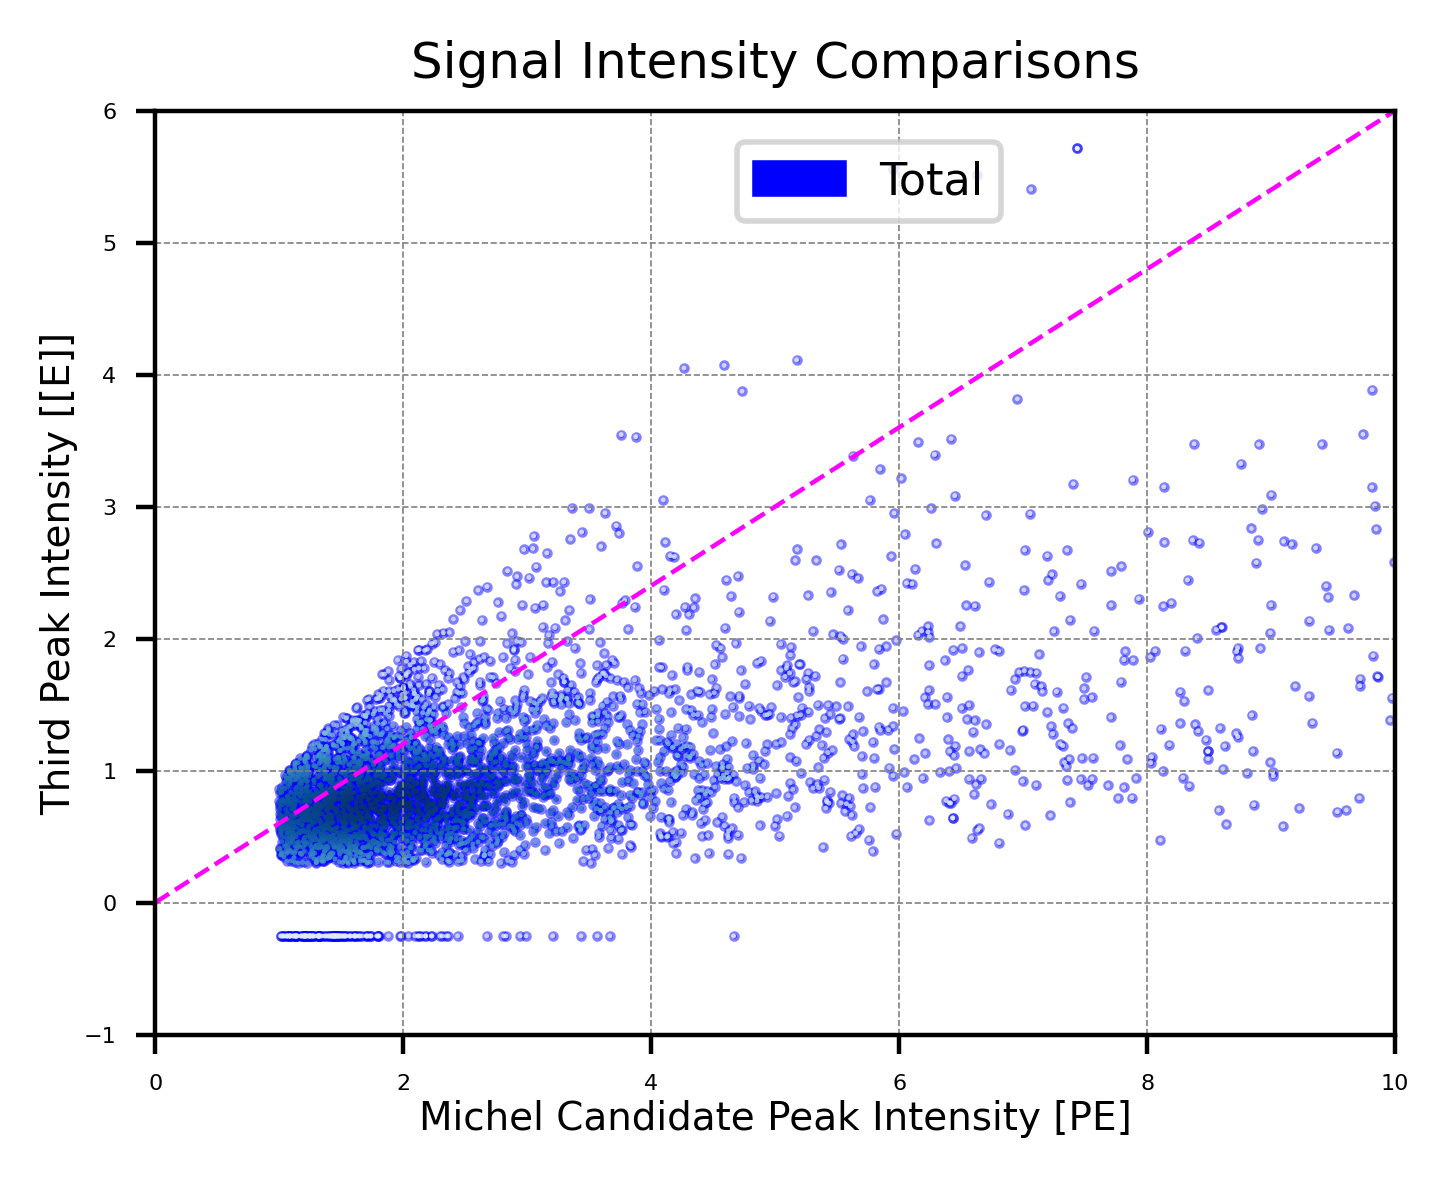

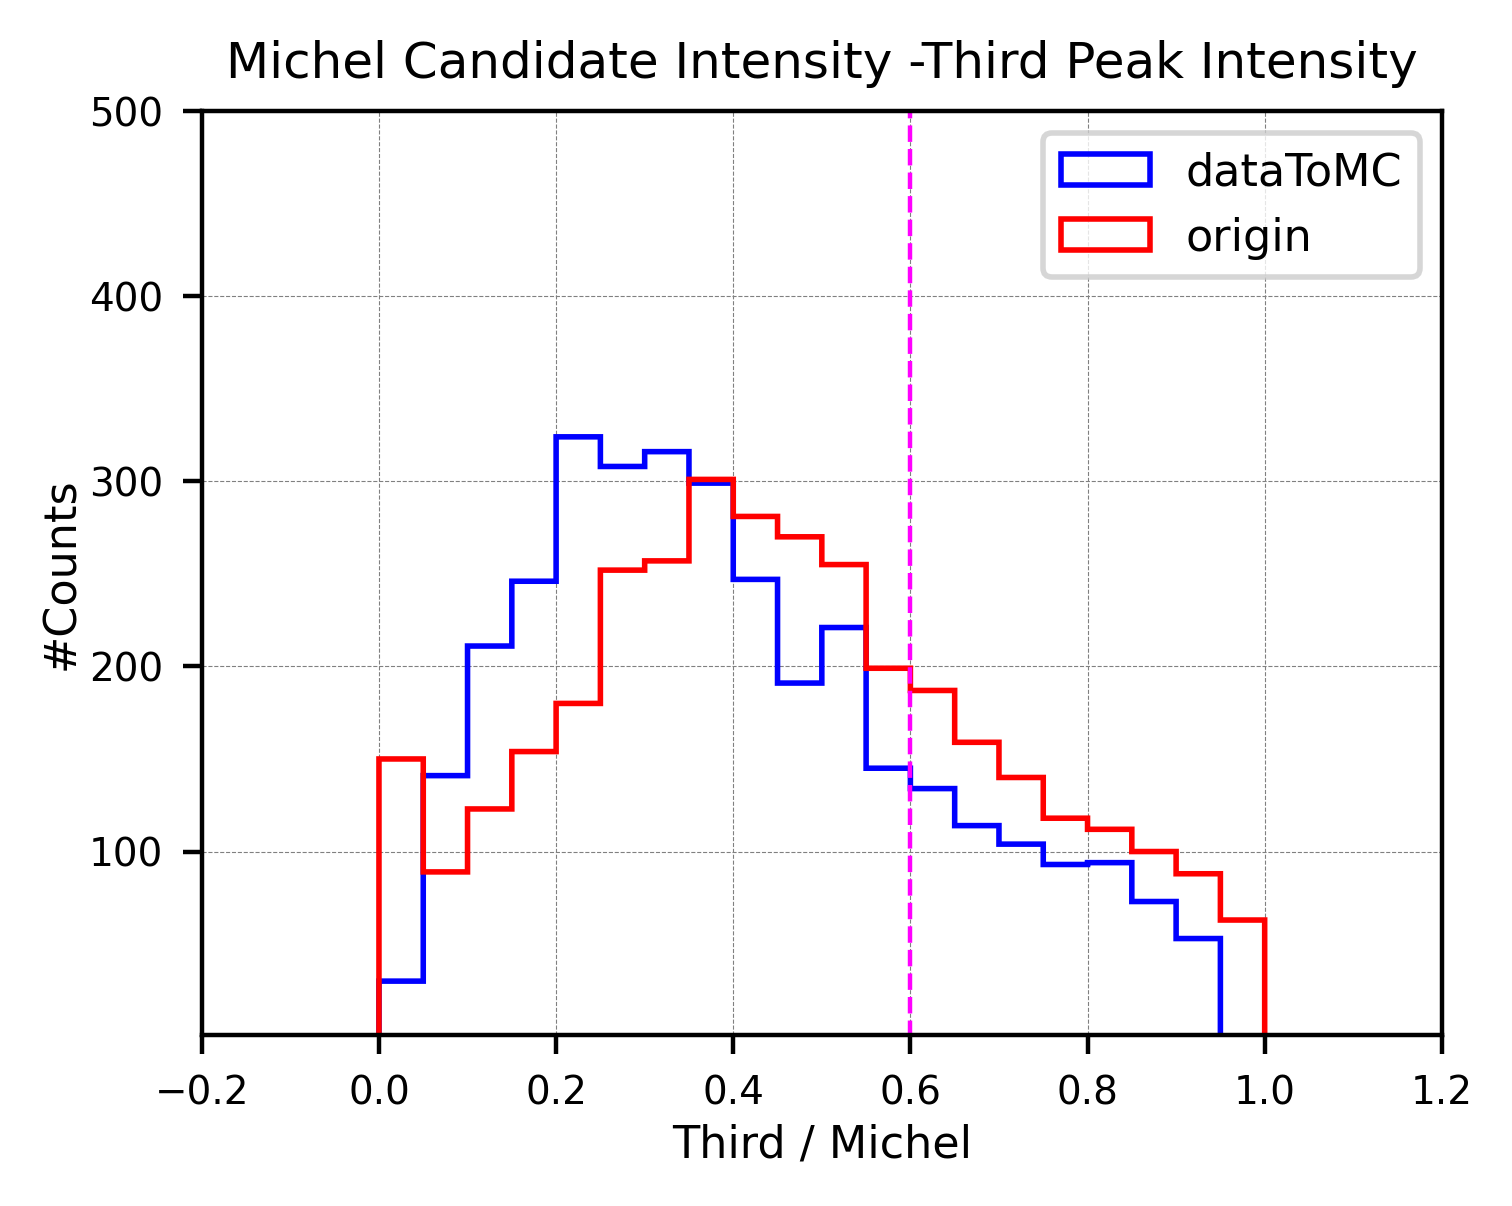

In [255]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 6:---------")

print("#event    : ", len(events_total_purify6))



miInt_tmp = [ev.michel_intensity for ev in events_total_purify6]
miInt_tmp = np.array(miInt_tmp, dtype=float)
miInt_total_purity6 = michel_dataToMC(miInt_tmp)

third_tmp = [ev.third_intensity for ev in events_total_purify6]
third_tmp = np.array(third_tmp, dtype=float)
thInt_total_purity6 = third_dataToMC(third_tmp)


# Element-by-element ratio (thInt / miInt)
ratio_total_purity6 = [th / mi for th, mi in zip(thInt_total_purity6, miInt_total_purity6)]
ratio_initial_purity6 = [th / mi for th, mi in zip(third_tmp, miInt_tmp)]

thre1 = 0.0
thre2 = 0.6

# filter the actual events

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


events_total_purify7 = [
    ev for ev in events_total_purify6
#    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
    if ev.michel_intensity != 0 and thre1 < third_dataToMC(ev.third_intensity) / michel_dataToMC(ev.michel_intensity) < thre2    
]
#-------------------------------


print("\nThird / Second peak intensity (Cut 7):--------------")
print("Efficiency (cut7 / cut6): ", len(events_total_purify7), "/", len(events_total_purify6),
      "({:.2f}%)".format(len(events_total_purify7)/len(events_total_purify6)*100))









# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x2, y2 = np.array(miInt_total_purity6), np.array(thInt_total_purity6)
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 100], [0, 60], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Third / Michel Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_total_purity6, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="dataToMC")
plt.hist(ratio_initial_purity6, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="origin")

plt.plot([0.6, 0.6], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.2, 1.2)
plt.xlabel('Third / Michel', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 

### Cut 8: Third second peak intensity diff cut


After Cut 7:--------------
#event   :  2679

Michel 3rd Peaks intensity Diff (Cut 8):--------------
Efficiency (cut8 / cut7):  2458 / 2679 (91.75%)


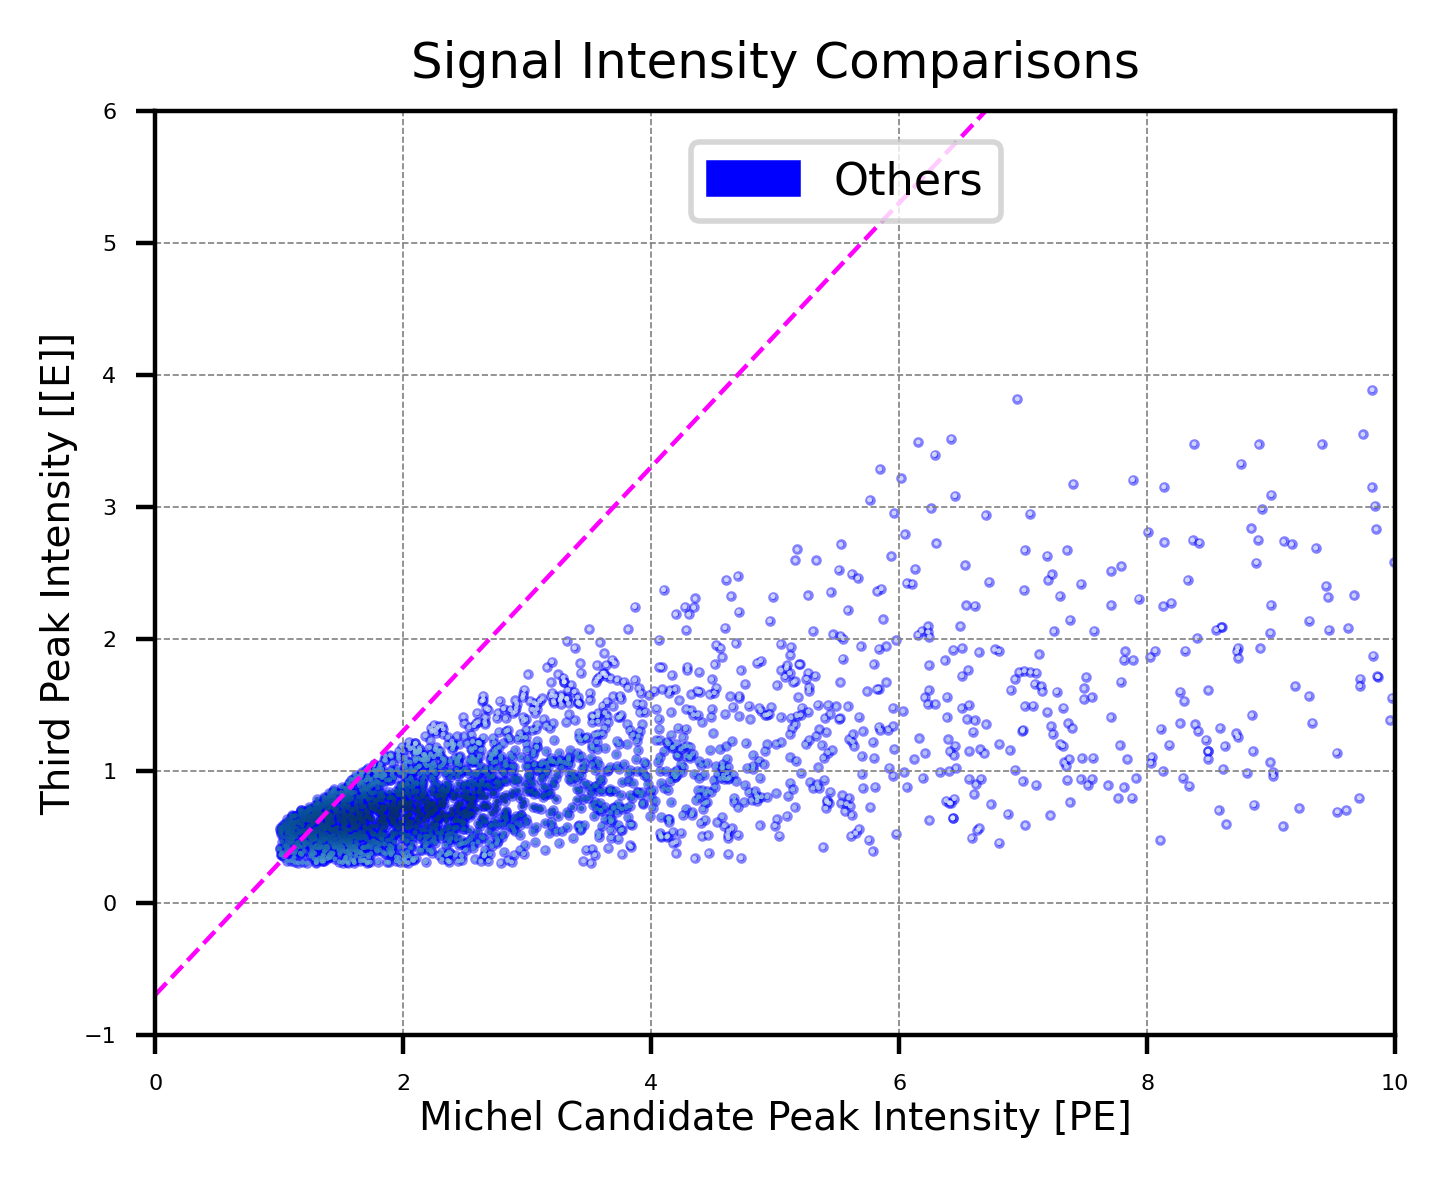

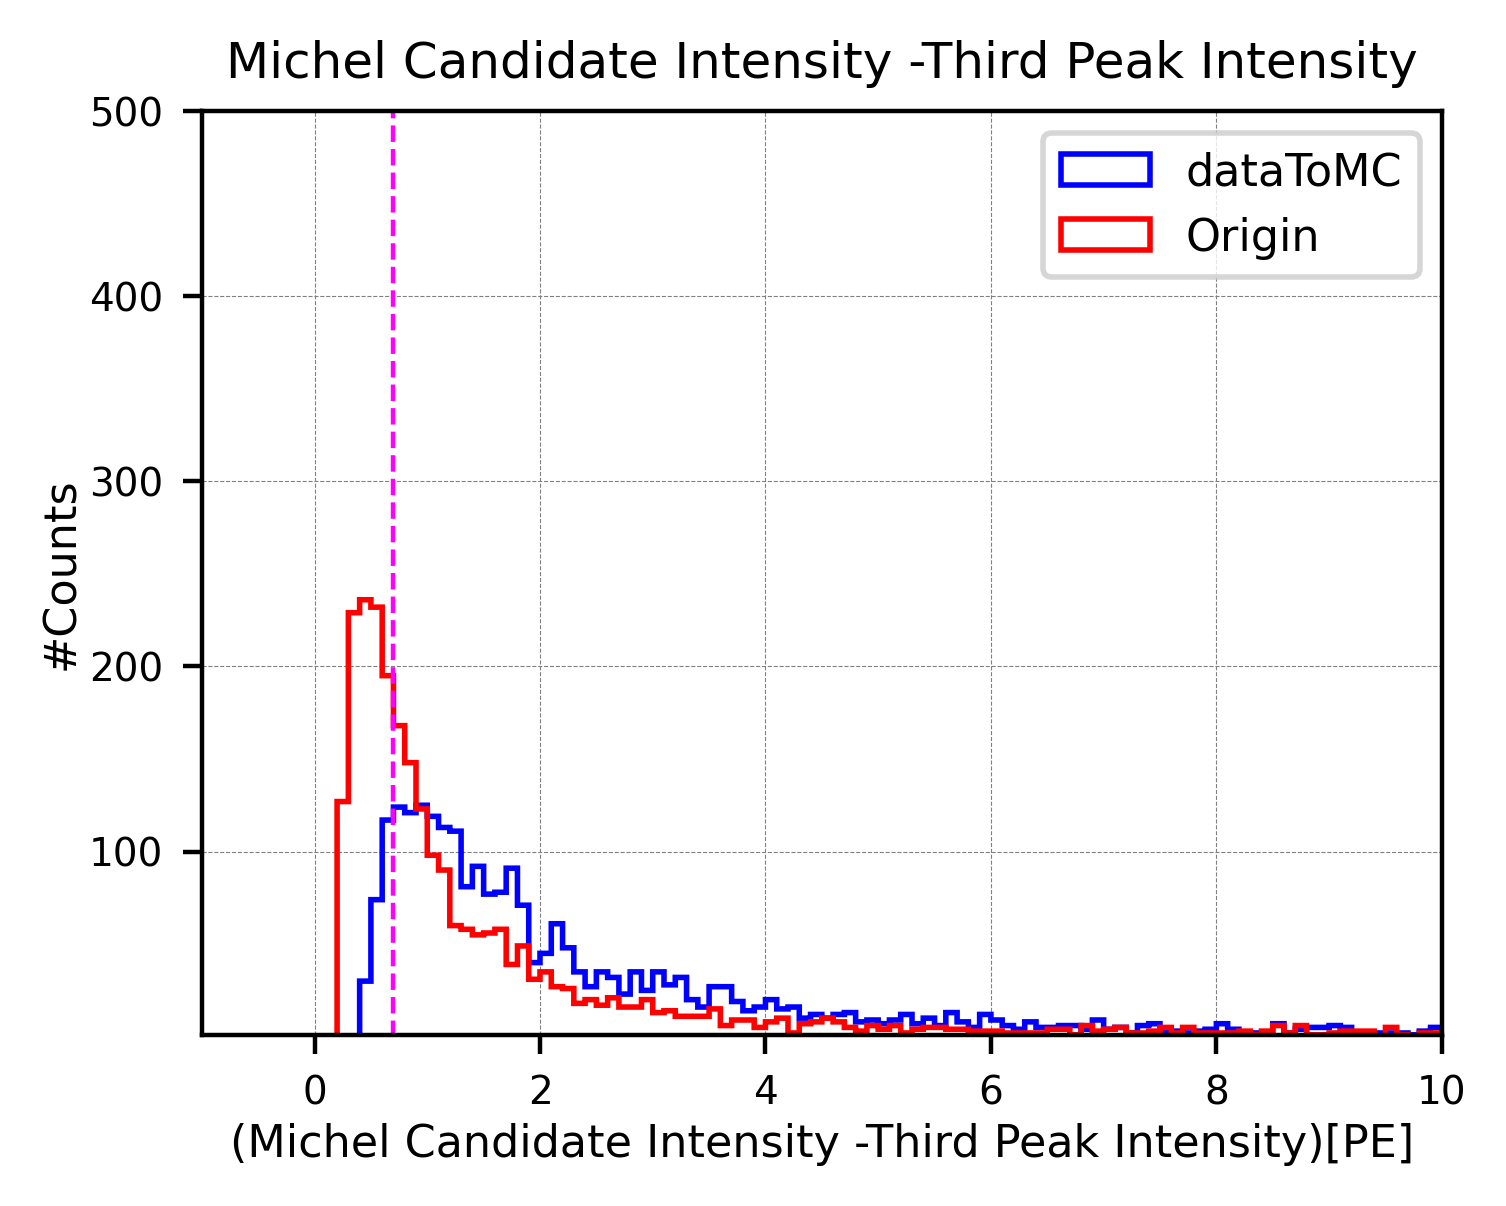

In [256]:
print("\nAfter Cut 7:--------------")

print("#event   : ", len(events_total_purify7))

miInt_tmp = [ev.michel_intensity for ev in events_total_purify7]
miInt_tmp = np.array(miInt_tmp, dtype=float)
miInt_total_purity7 = michel_dataToMC(miInt_tmp)

third_tmp = [ev.third_intensity for ev in events_total_purify7]
third_tmp = np.array(third_tmp, dtype=float)
thInt_total_purity7 = third_dataToMC(third_tmp)



# Element-by-element difference (thInt - miInt)
subtract_total_purity7 = [mi - th for th, mi in zip(thInt_total_purity7, miInt_total_purity7)]
subtract_initial_purity7 = [mi - th for th, mi in zip(third_tmp, miInt_tmp)]

thre_diff = 0.7


# filter the actual events
events_total_purify8 = [
    ev for ev in events_total_purify7
#    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
    if thre_diff <  (michel_dataToMC(ev.michel_intensity) - third_dataToMC(ev.third_intensity))    
]
#-------------------------------


print("\nMichel 3rd Peaks intensity Diff (Cut 8):--------------")

print("Efficiency (cut8 / cut7): ", len(events_total_purify8), "/", len(events_total_purify7),
      "({:.2f}%)".format(len(events_total_purify8)/len(events_total_purify7)*100))










# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_total_purity7), np.array(thInt_total_purity7)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

plt.plot([0, 10], [-0.7, 9.3], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Others")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()









#(Michel Candidate Intensity -Third Peak Intensity) Distributions====================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(subtract_total_purity7, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="dataToMC")
plt.hist(subtract_initial_purity7, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Origin")

plt.plot([0.7, 0.7], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-1, 10)
plt.xlabel('(Michel Candidate Intensity -Third Peak Intensity)[PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

### Cut 9: Space Cut along drift direction


After Cut 8:--------------
Event    :  2458

Drift Direction Cut (Cut 9):--------------
Efficiency (cut9 / cut8):  2348 / 2458 (95.52%)

Decay points distribution: 


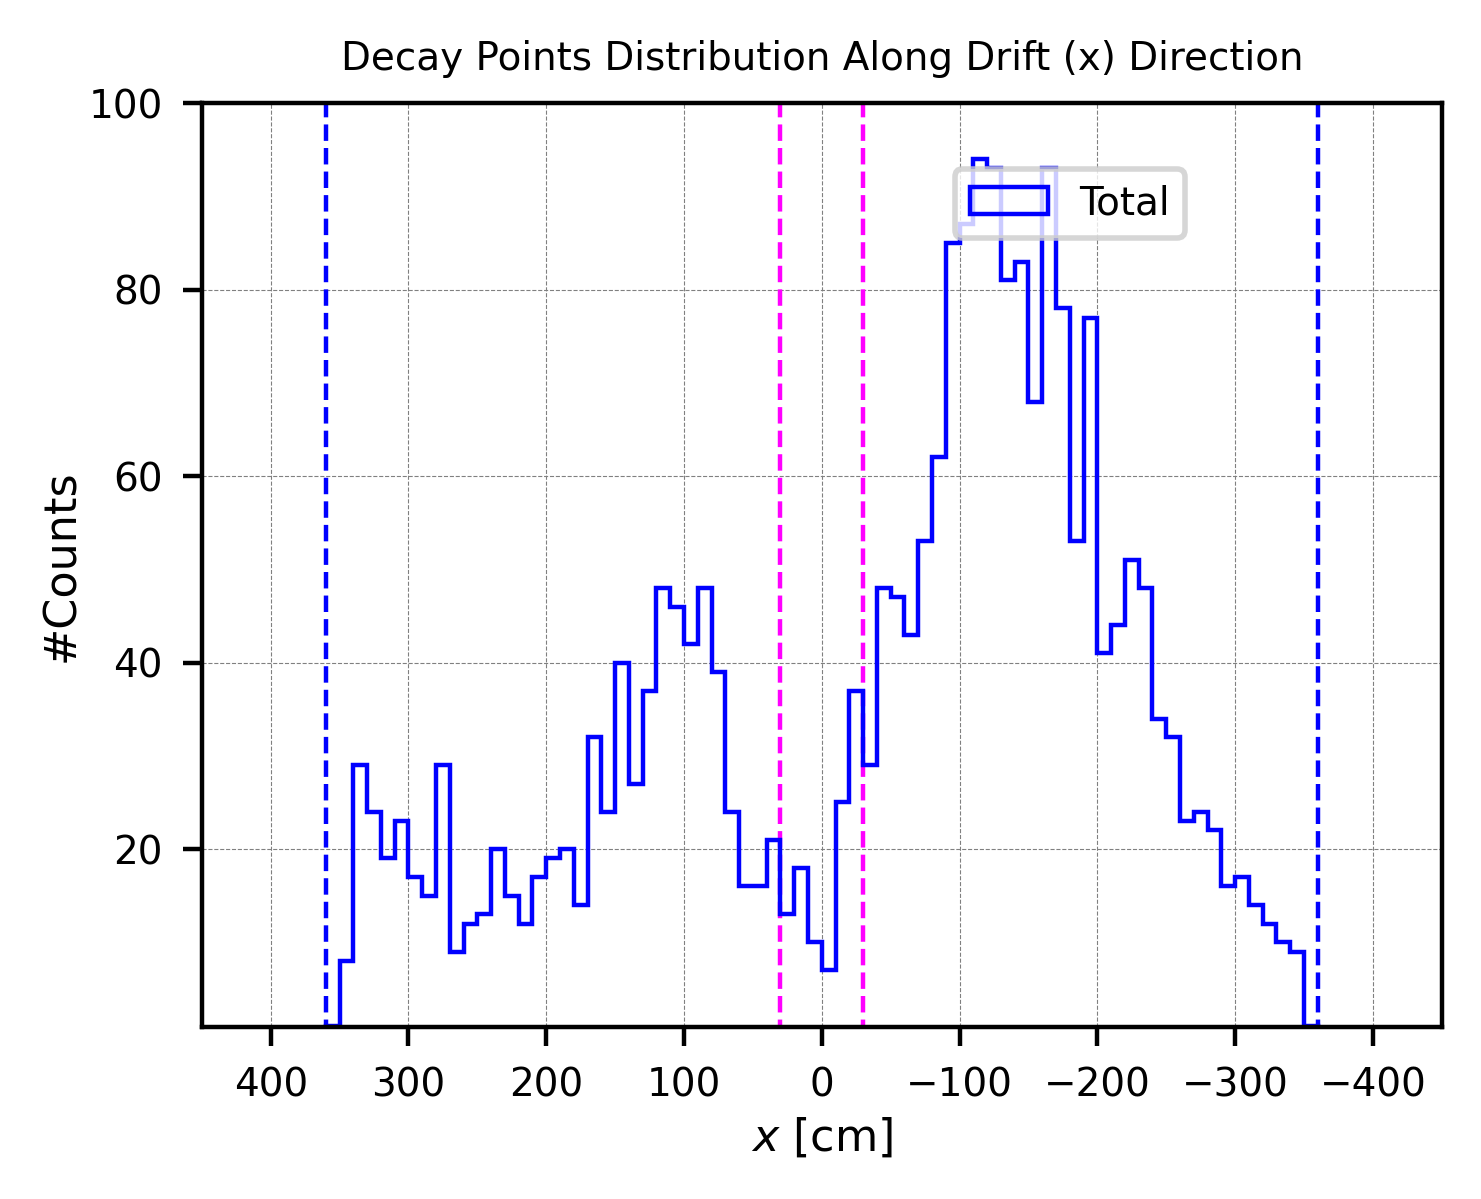

In [264]:
print("\nAfter Cut 8:--------------")

print("Event    : ", len(events_total_purify8))





posX_cut = 30

#Shu (20260311): manually new threshold for beam side
negX_cut = -30

# filter the actual events
events_total_purify9 = [
    ev for ev in events_total_purify8
    if posX_cut < ev.posX  or  ev.posX < negX_cut
]
#-------------------------------


print("\nDrift Direction Cut (Cut 9):--------------")

print("Efficiency (cut9 / cut8): ", len(events_total_purify9), "/", len(events_total_purify8),
      "({:.2f}%)".format(len(events_total_purify9)/len(events_total_purify8)*100))










posX_total_purify8 = [ev.posX for ev in events_total_purify8]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Cut line------
plt.plot([posX_cut, posX_cut], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([negX_cut, negX_cut], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify8, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




<br />

#### Single Event Inspection:

In [261]:
# "Signal"
for ev in events_total_purify9:
    if ev.reco_lifetime >10000:
        print(ev)



PdsEventNew(muon_time=59, michel_time=867, muon_intensity=6.38487, michel_intensity=1.41424, third_intensity=0.381256, posX=110.164, posY=289.601, posZ=176.421, eventID=100271, trackID=1, date=202602, michel_score=0.433426, michel_hits=20, reco_lifetime=12928, michel_rise=0.19706250000000003, michel_drop=0.1469333333333333)
PdsEventNew(muon_time=60, michel_time=1014, muon_intensity=25.9907, michel_intensity=3.51014, third_intensity=1.07458, posX=-245.35, posY=43.3947, posZ=363.818, eventID=103696, trackID=0, date=202602, michel_score=0.732491, michel_hits=18, reco_lifetime=15264, michel_rise=0.5550233333333333, michel_drop=1.2153800000000001)
PdsEventNew(muon_time=60, michel_time=854, muon_intensity=29.1228, michel_intensity=3.33246, third_intensity=0.815616, posX=-181.009, posY=340.286, posZ=402.983, eventID=1045, trackID=7, date=202602, michel_score=0.756173, michel_hits=20, reco_lifetime=12704, michel_rise=0.4434802631578948, michel_drop=0.2814696428571429)
PdsEventNew(muon_time=62,

<br />
<br />

#### Features of final dataset (after purification 9):


Decay points distribution: 


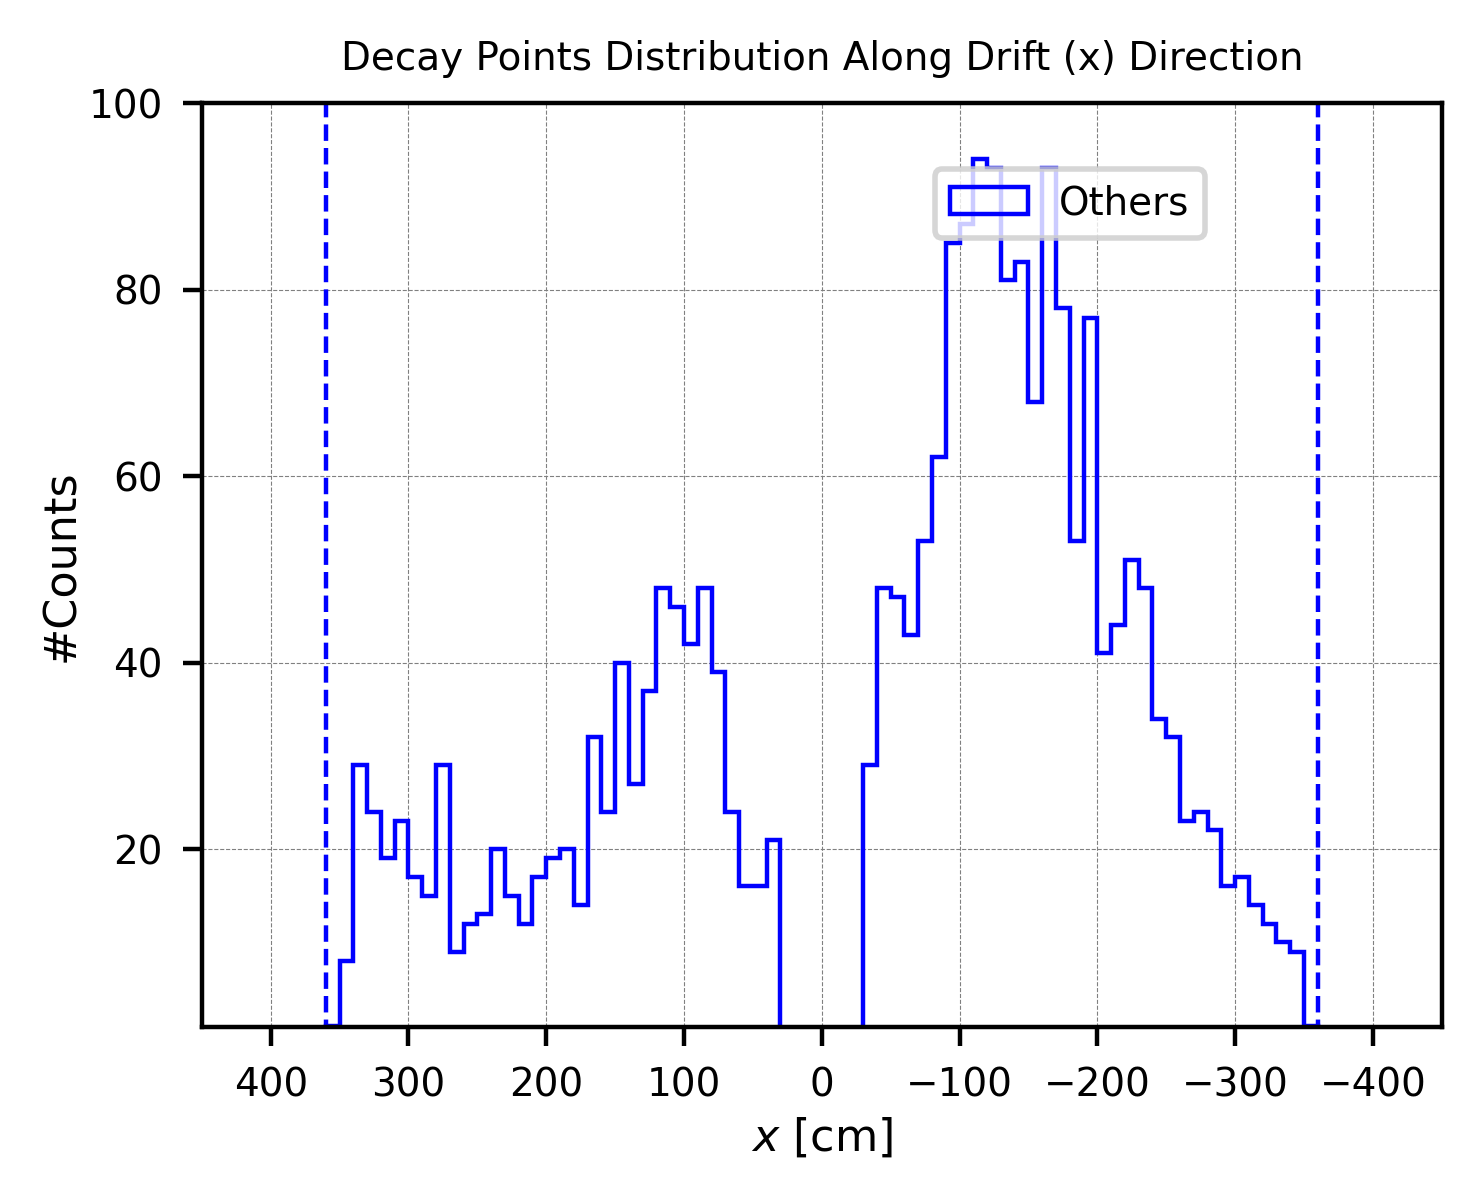

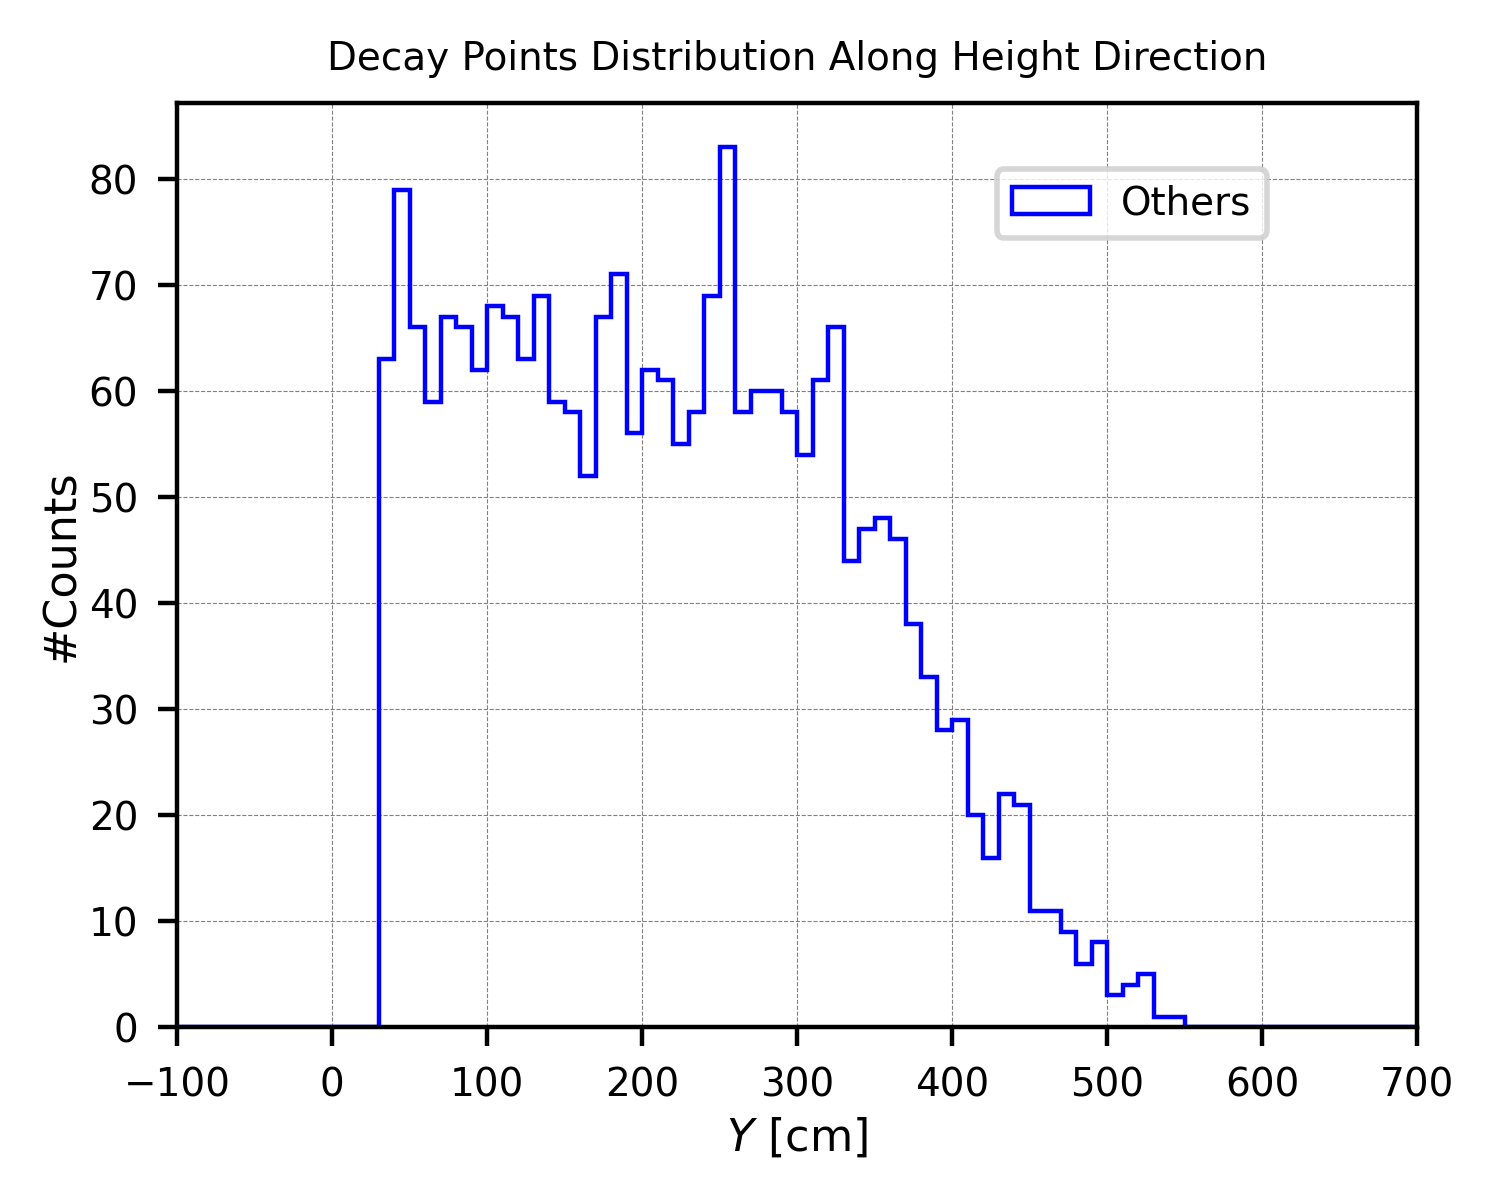

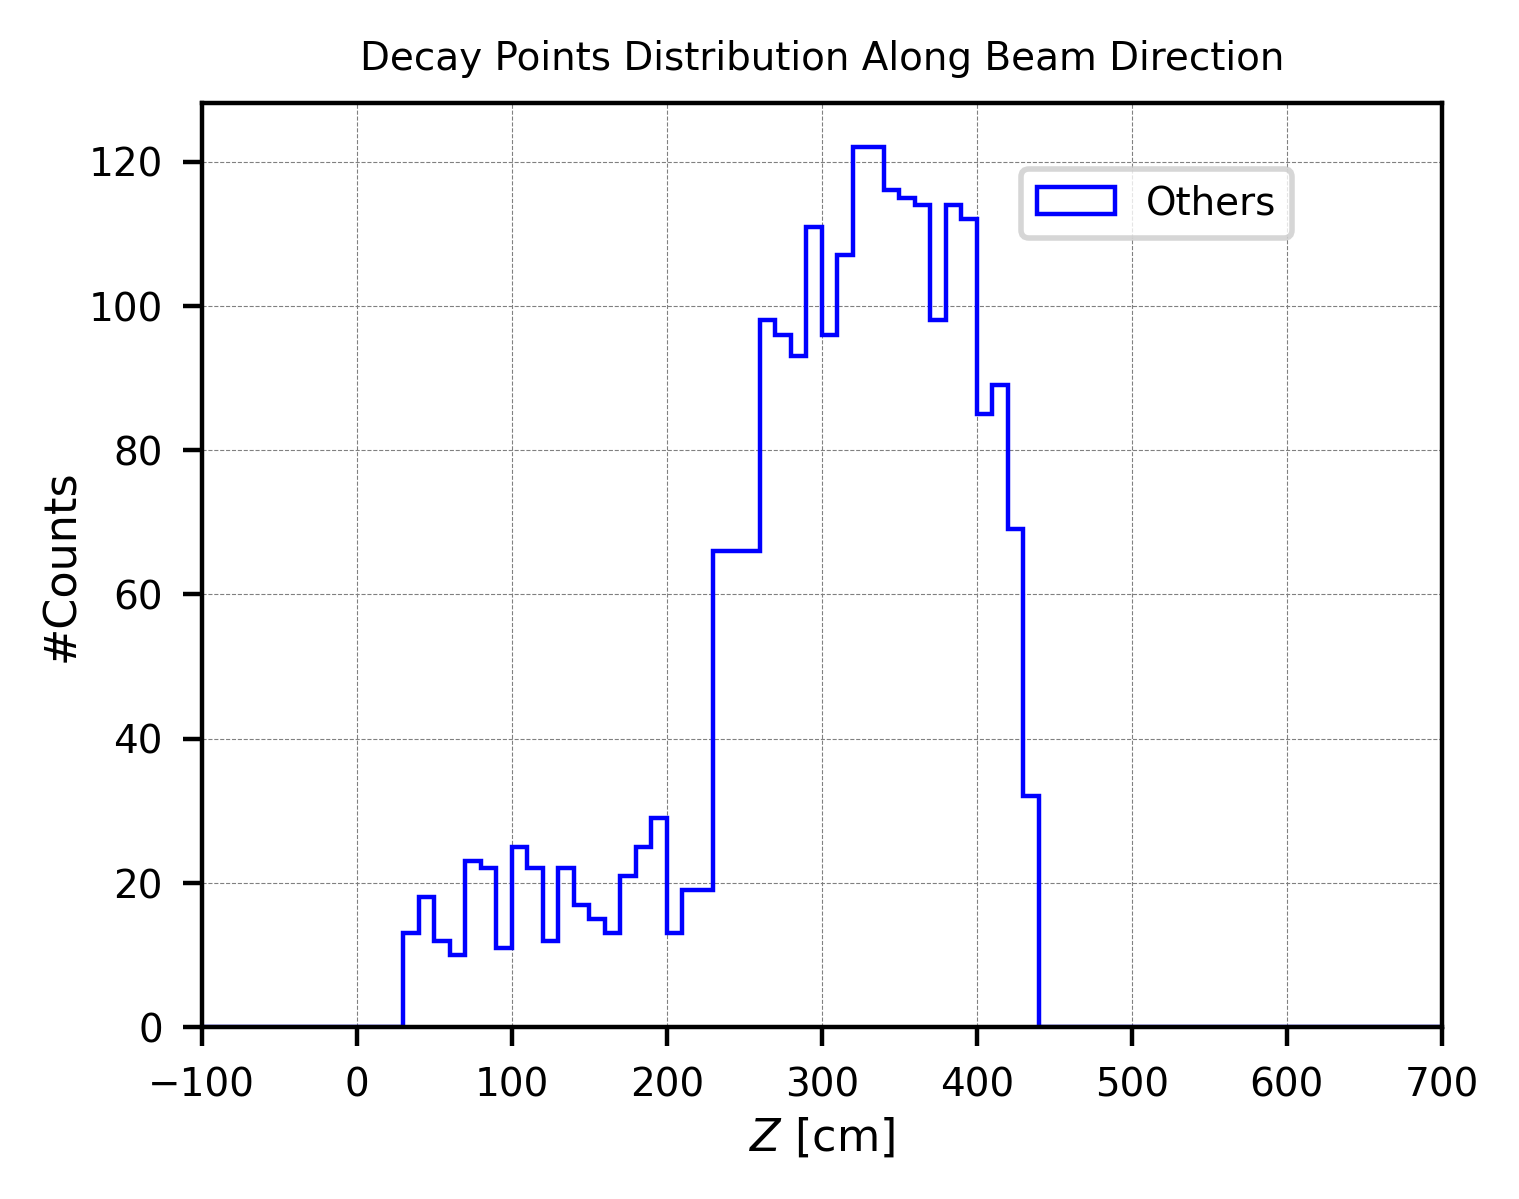

In [267]:

posX_total_purify9 = [ev.posX for ev in events_total_purify9]
posY_total_purify9 = [ev.posY for ev in events_total_purify9]
posZ_total_purify9 = [ev.posZ for ev in events_total_purify9]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Y distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posY_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Y$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Height Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posZ_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Z$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 











# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line for field cage
# aux2 = [0, 610, 610, 0, 0]
# aux1 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(xmin, xmax)
# plt.ylim(-50, 660)
# plt.gca().invert_xaxis()  # Flip x-axis
# plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Front View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux1 = [0, 465, 465, 0, 0]
# aux2 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.ylim(xmin, xmax)
# plt.xlim(-50, 515)
# plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.title('Top View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()




# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
# aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(-50, 515)
# plt.ylim(-50, 660)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Side View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


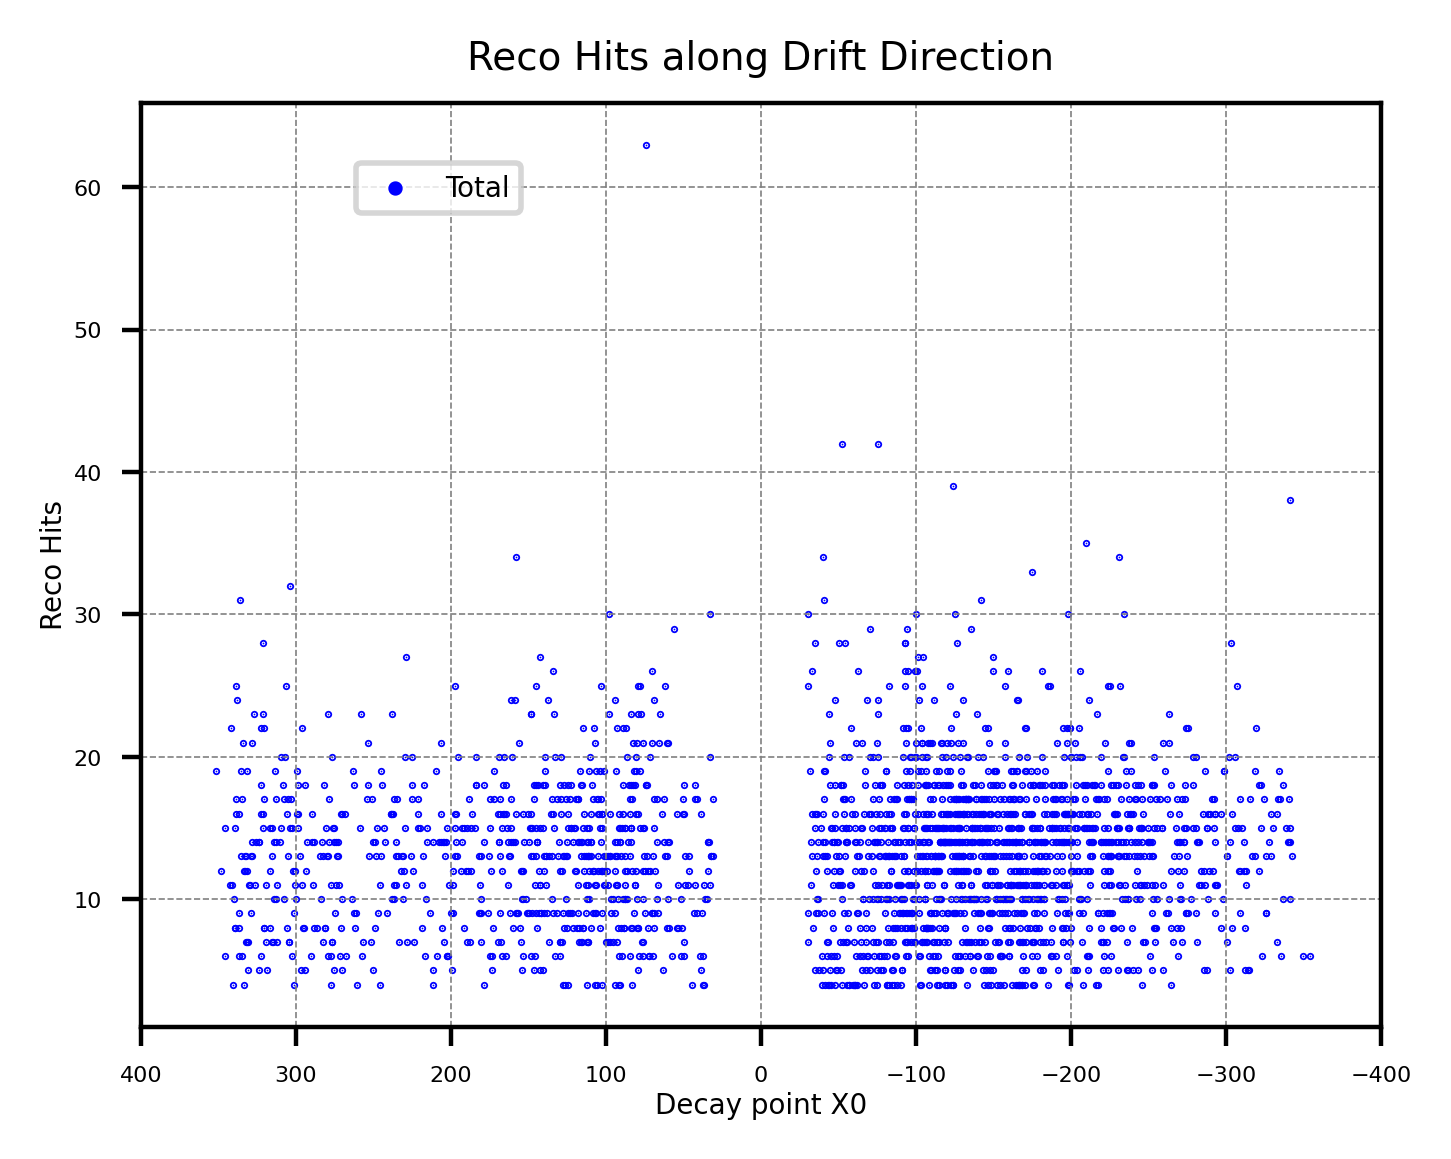


Michel Score Distribution: 


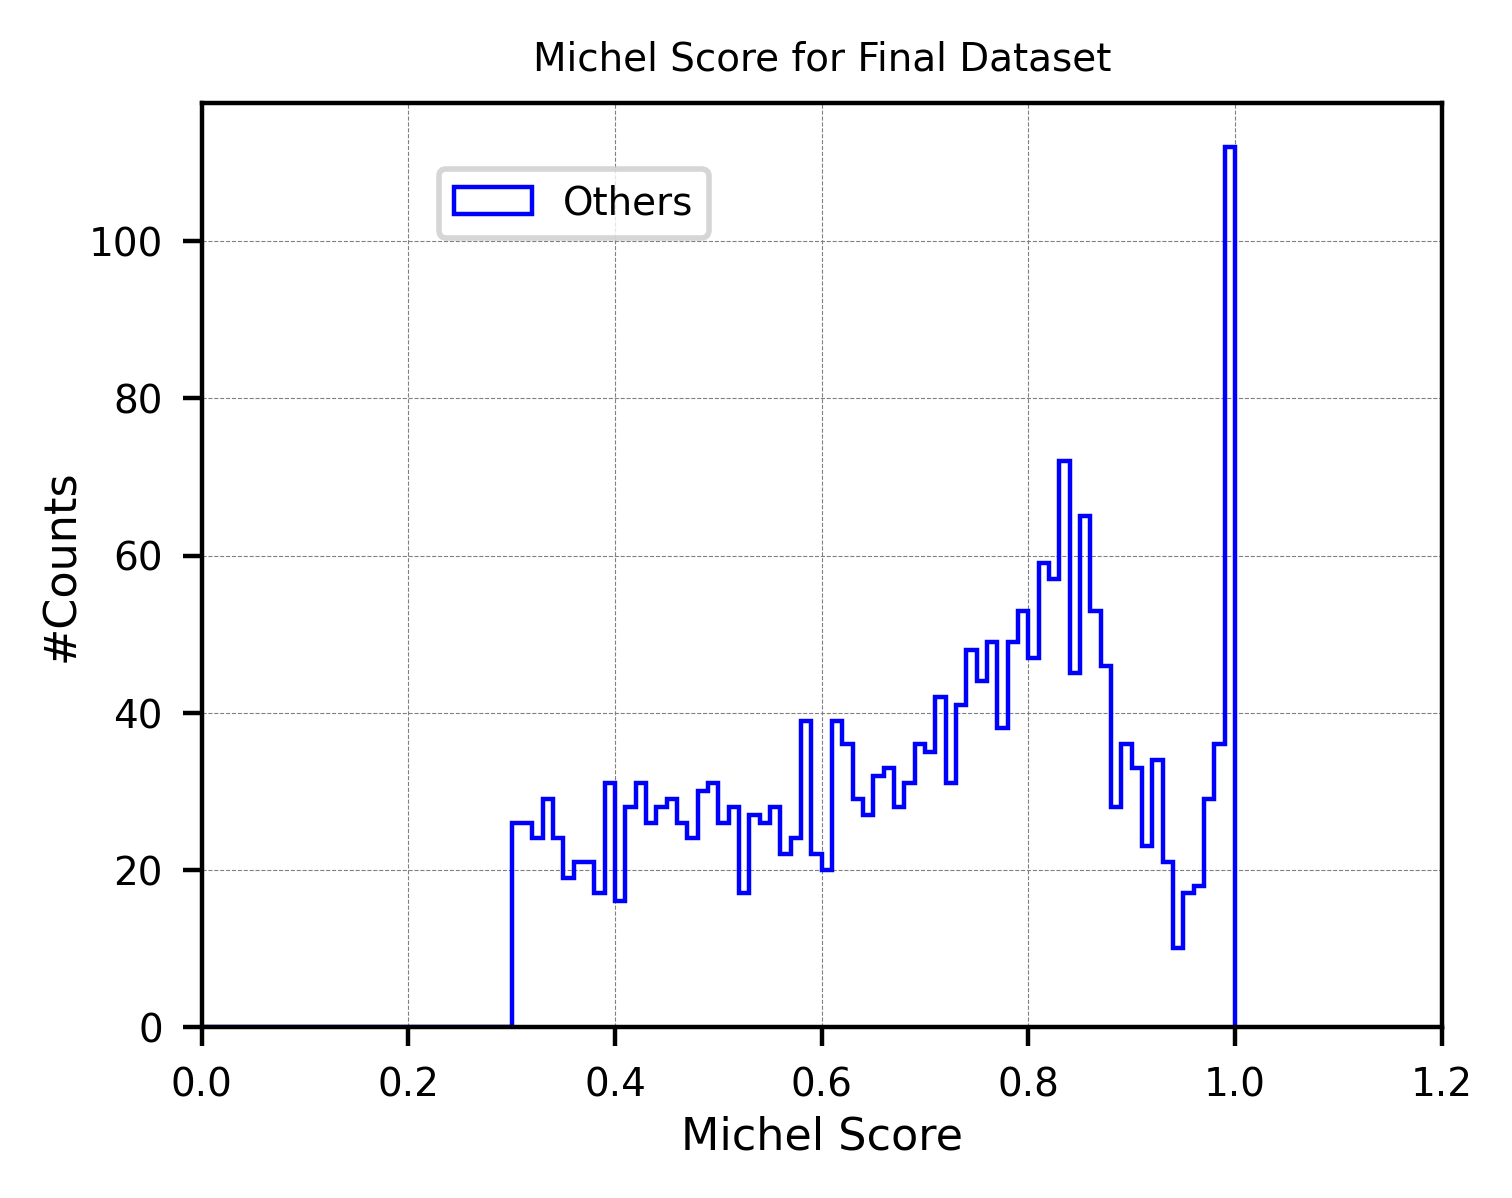


Michel Hits Distribution: 


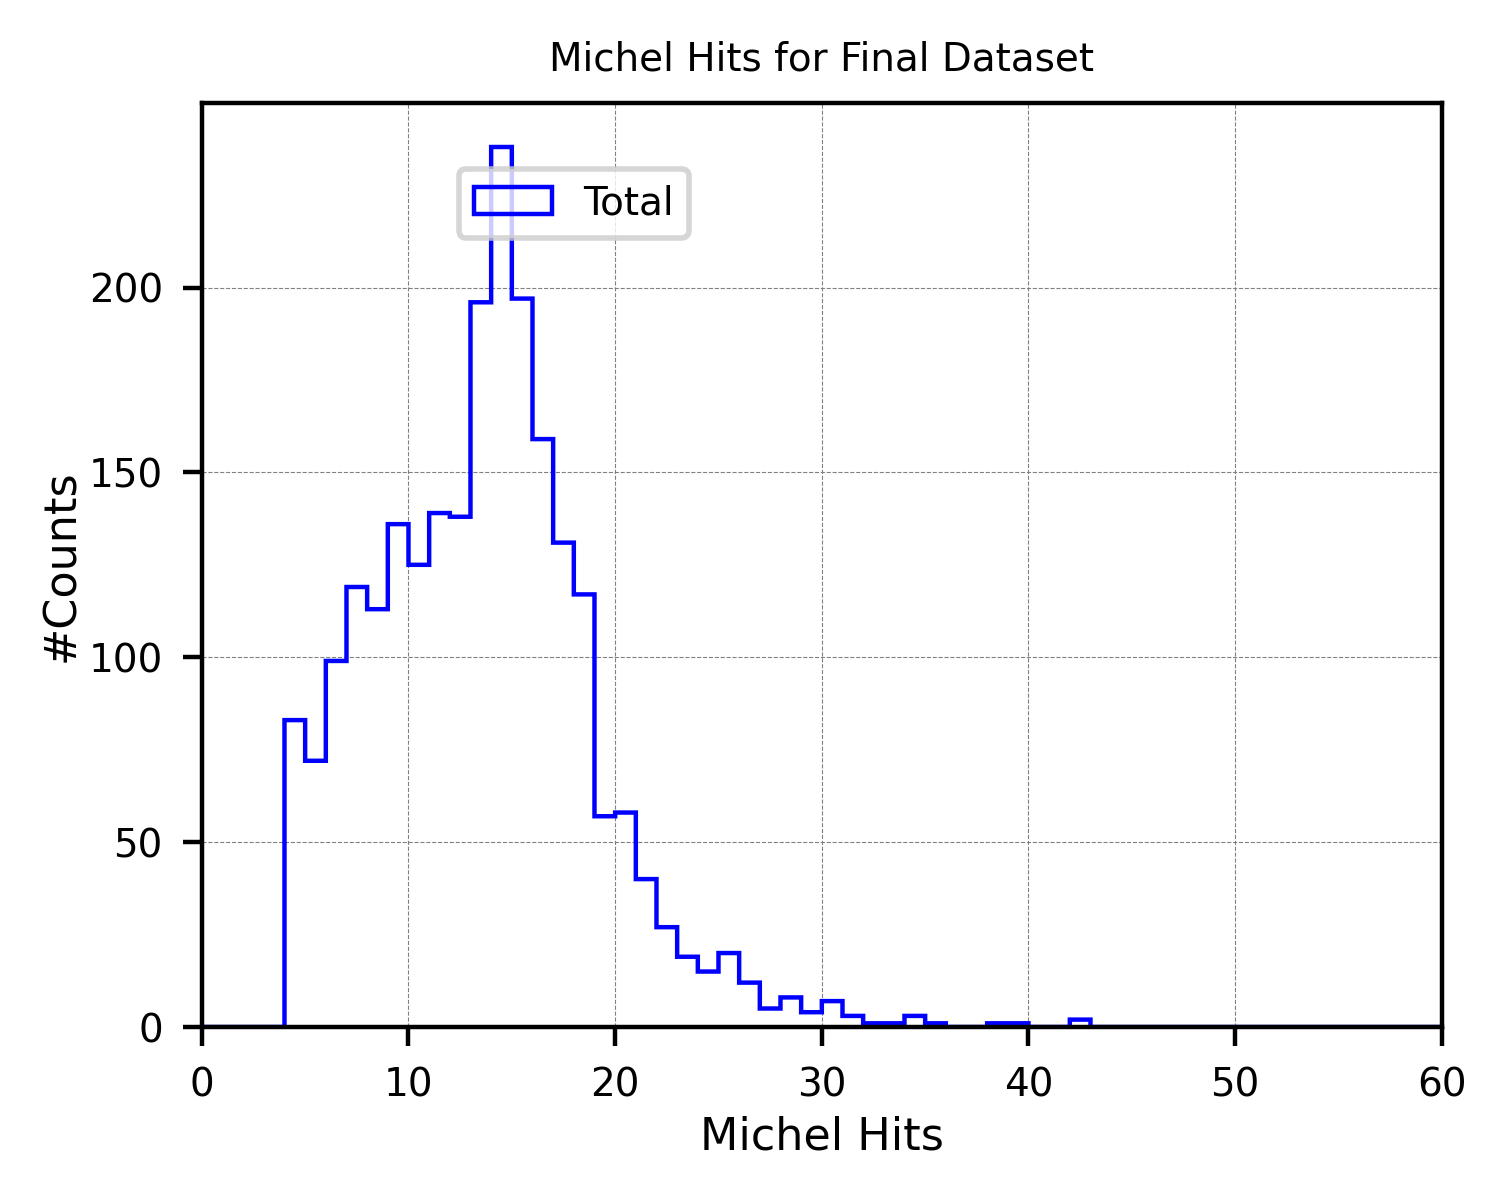

In [268]:

hits_total_purify9 = [ev.michel_hits for ev in events_total_purify9]

score_total_purify9 = [ev.michel_score for ev in events_total_purify9]











# ==========================================================
# reco hits VS posX
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(posX_total_purify9, hits_total_purify9, s=0.1, c='blue', alpha=1.0, label="Total")
#-----------------------

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0, 2000)
plt.ylabel('Reco Hits', labelpad=1, fontsize=5)
plt.xlabel('Decay point X0', labelpad=1, fontsize=5)
plt.title('Reco Hits along Drift Direction', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()








#Michel Score distribution:==========================================
print("\nMichel Score Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min =-1
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(score_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 1.2)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Score for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 







#Michel Hits distribution:==========================================
print("\nMichel Hits Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min =0
range_max = 600
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(hits_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")

#--------------------------------

plt.xlim(0, 60)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Hits for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 





<br />
<br />
<br />

#### Lifetime Distribution of Final Dataset (purification 9):



For each event, +40ns for reco time


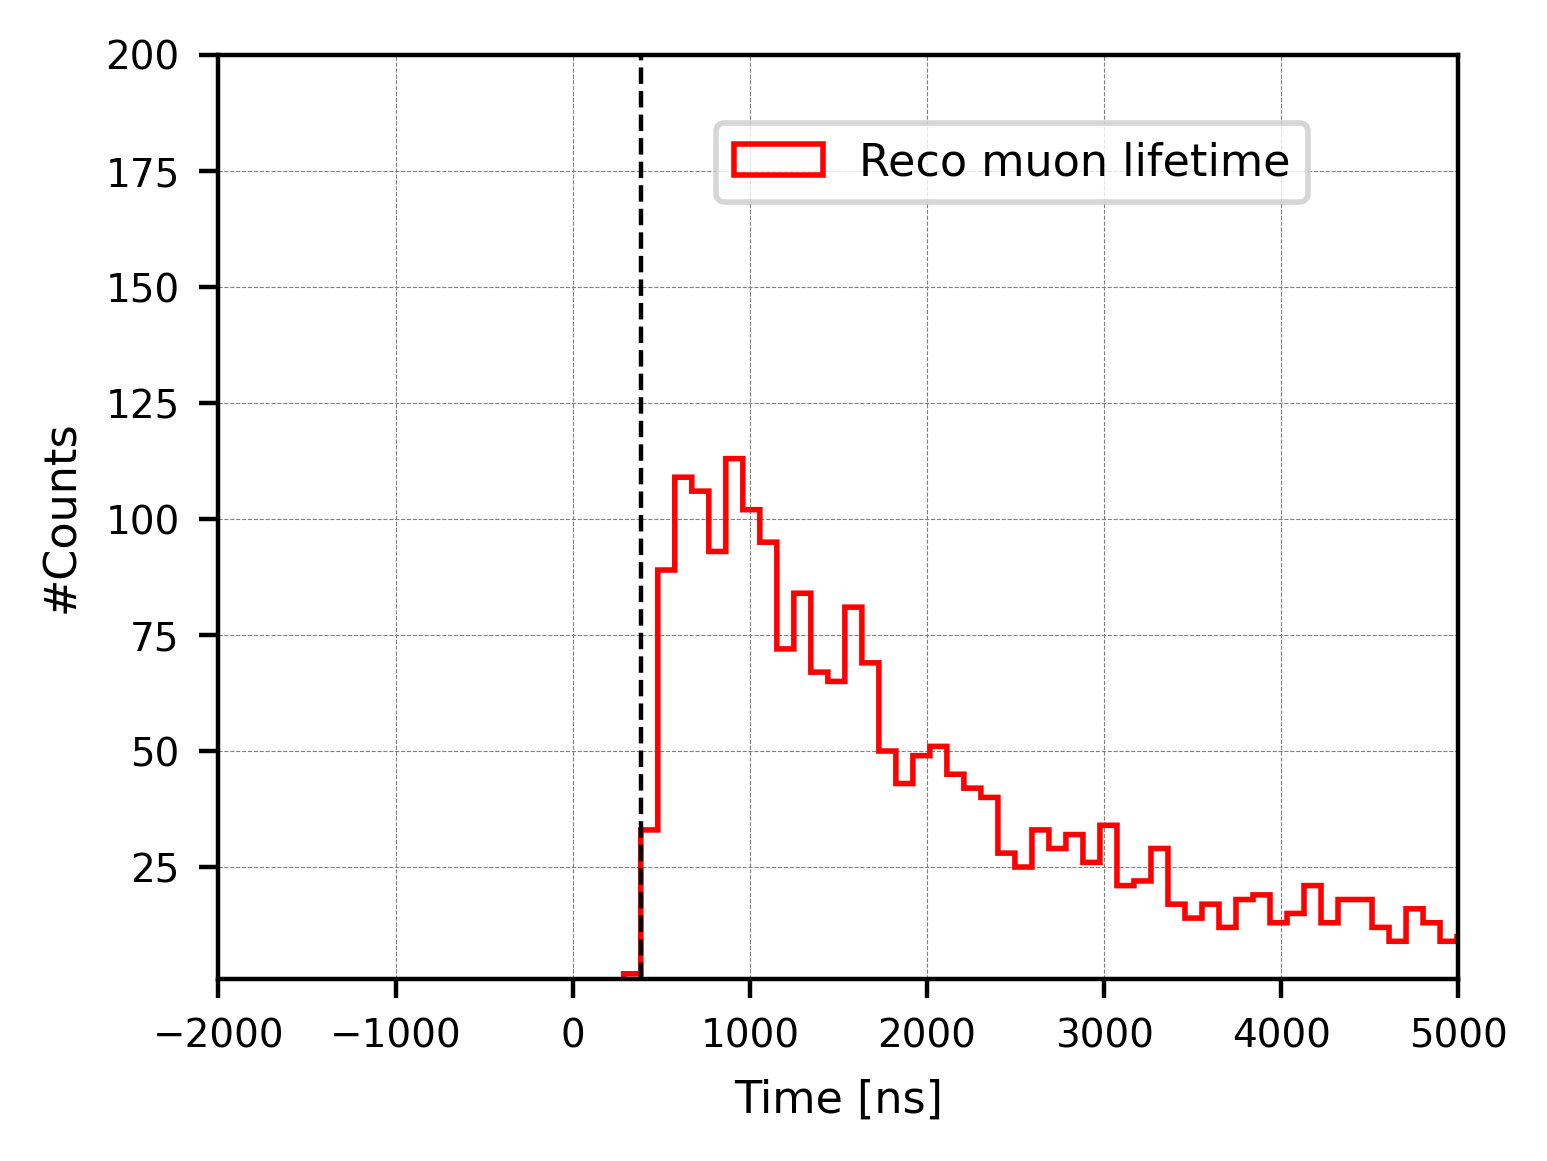

In [279]:

recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]






#Shift +40ns=========================================
print("\n\n===================================")
print("For each event, +40ns for reco time")
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]


bin_width = 96
range_min = -96000
range_max = 96000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.figure(figsize=(4, 3), dpi=400)
#plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
#         edgecolor='blue', histtype='step', linewidth=1.0,
#         label='Reco muon lifetime')

plt.hist(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.axvline(384, linestyle='--', color='k', linewidth=0.8)

plt.xlim(-2000, 5000)
plt.ylim(0.9, 200)
#plt.yscale("log")
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()





<br />
<br />
<br />

### Shu: The following is OLD and NOT reliable (20260312)

<br />

### Apply detection efficiency:


Loaded efficiency ratio data.
[ 48. 144. 240. 336. 432.] [0.00586458 0.00811516 0.0083168  0.01181003 0.06751742] [0.00071976 0.00075367 0.00079329 0.00098869 0.00238708]


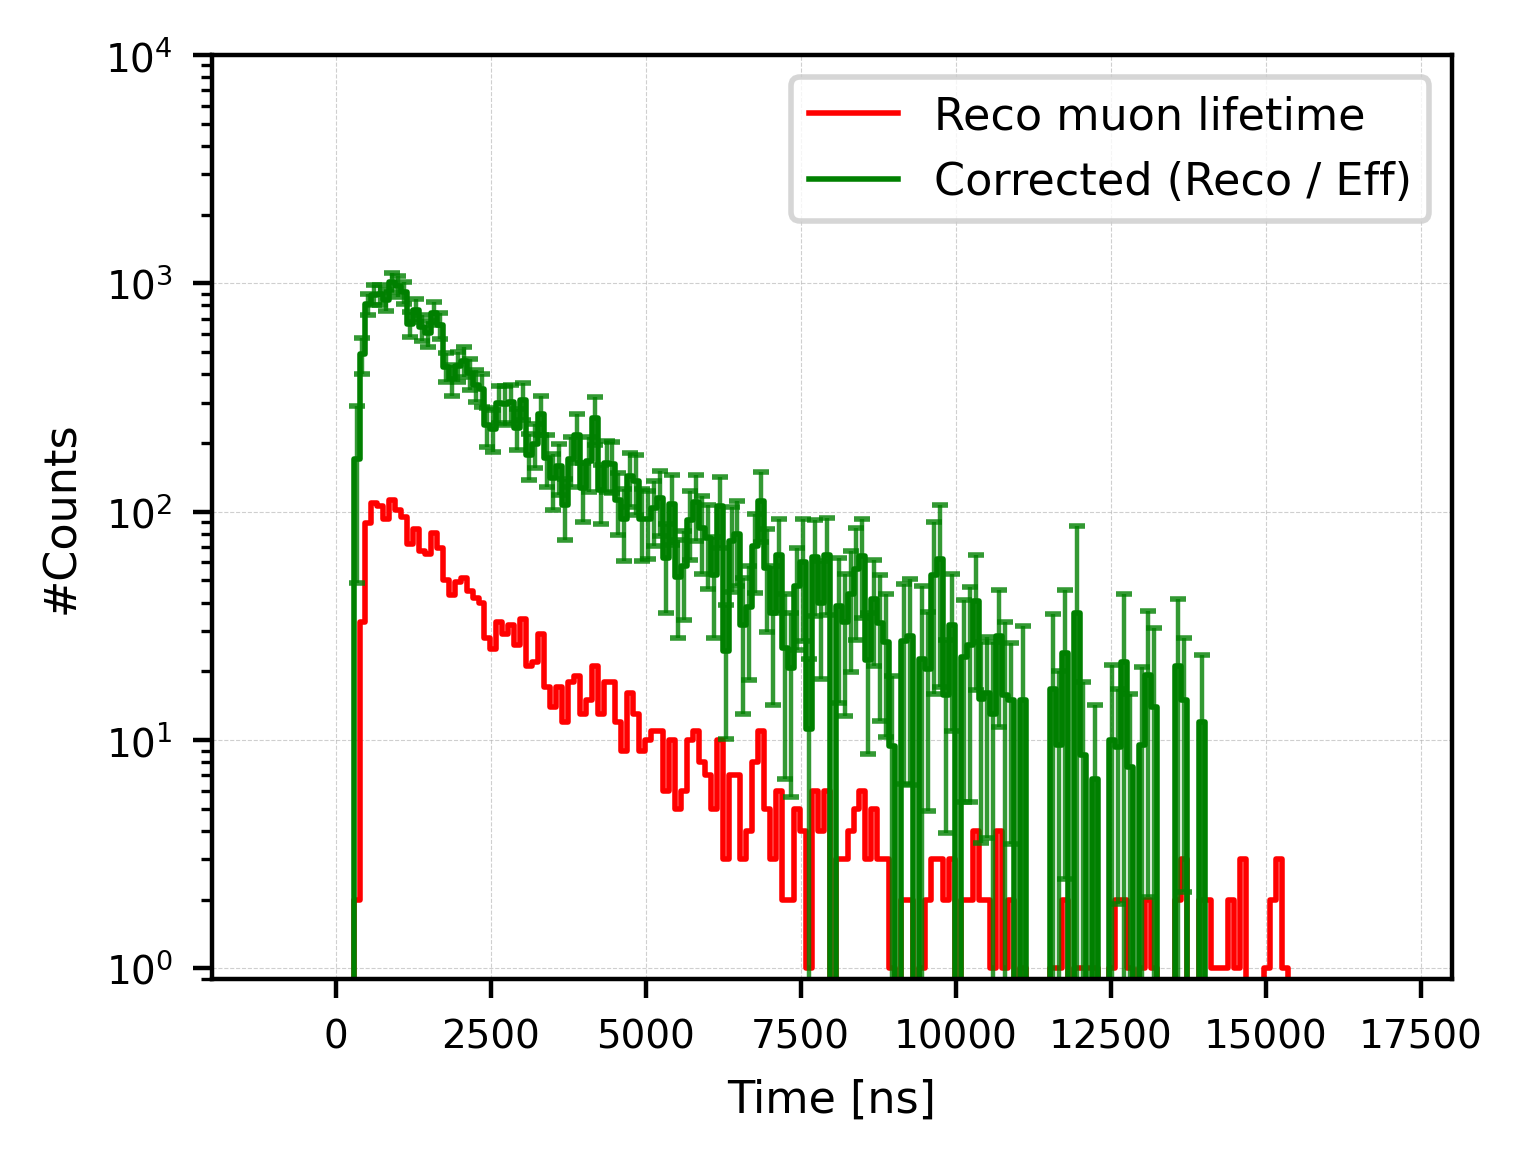

In [272]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Define bins (simple because range_min = 0)
# ============================================================
bin_width  = 96
range_min  = -96000
range_max  = 96000

bins    = np.arange(range_min, range_max + bin_width, bin_width)
centers = (bins[:-1] + bins[1:]) / 2
nbins   = len(centers)

# ============================================================
# 2. Load lifetime efficiency values
# ============================================================
data = np.load("../../MC_new20251070s/michel_efficiency_ratios.npz")

eff_bins  = data["bins"]     # e.g. [50,150,250,...]
eff_ratio = data["ratio"]    # Final / Initial
eff_err   = data["error"]    # Uncertainty

print("Loaded efficiency ratio data.")
print(eff_bins[:5], eff_ratio[:5], eff_err[:5])

# ============================================================
# 3. Reco histogram (before correction)
# ============================================================
counts_reco, _ = np.histogram(
    recoT_total_purify9_shift40,
    bins=bins,
    range=(range_min, range_max)
)

sigma_reco = np.sqrt(counts_reco)

# ============================================================
# 4. Align efficiency values with histogram bins
# ============================================================
eff_full     = np.zeros(nbins)
eff_err_full = np.zeros(nbins)

# Direct index matching (valid because centers begin at 50,150,...)
for i, c in enumerate(centers):
    idx = np.where(eff_bins == c)[0]
    if len(idx) > 0:
        eff_full[i]     = eff_ratio[idx[0]]
        eff_err_full[i] = eff_err[idx[0]]

# ============================================================
# 5. Efficiency correction with full A/B error propagation
# ============================================================
R_corr       = np.zeros(nbins)
sigma_R_corr = np.zeros(nbins)

valid = eff_full > 0

R_corr[valid] = counts_reco[valid] / eff_full[valid]

sigma_R_corr[valid] = np.sqrt(
    (sigma_reco[valid] / eff_full[valid])**2 +
    ((counts_reco[valid] * eff_err_full[valid]) /
     eff_full[valid]**2)**2
)

# ============================================================
# 6. Plot raw and corrected histograms
# ============================================================
plt.figure(figsize=(4, 3), dpi=400)

# -- Raw reco histogram --
plt.step(bins, np.append(counts_reco, counts_reco[-1]),
         where='post', color='red', lw=1.0, label='Reco muon lifetime')

# -- Corrected histogram --
plt.step(bins, np.append(R_corr, R_corr[-1]),
         where='post', color='green', lw=1.0, label='Corrected (Reco / Eff)')

plt.errorbar(
    centers, R_corr, sigma_R_corr,
    fmt='none', ecolor='green', elinewidth=0.8, capsize=1.5, alpha=0.8
)

# Style
plt.xlim(-2000, 18000)
plt.ylim(0.9, 10000)
plt.yscale('log')
plt.xlabel("Time [ns]", fontsize=8)
plt.ylabel("#Counts", fontsize=8)
plt.grid(ls="--", lw=0.2, alpha=0.6)
plt.tick_params(labelsize=7)
plt.legend(fontsize=8, loc='upper right')

plt.show()




<br />

### Apply fitting:

#### Fitting function:

In [273]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Integrated double exponential model
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# ============================================================
# χ² least-squares fit with custom range
# ============================================================
def fit_double_exp(bin_edges, y, yerr, fit_range=(400, 10000), tau2=2197.0):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width   = bin_edges[1] - bin_edges[0]

    # Select χ² fit region
    mask = (
        (bin_centers >= fit_range[0]) &
        (bin_centers <= fit_range[1]) &
        (y > 0) & np.isfinite(y)
    )

    if not np.any(mask):
        raise RuntimeError("❌ No valid bins in selected fit range.")

    i0, i1 = np.where(mask)[0][[0, -1]]
    edges_fit = bin_edges[i0 : i1 + 2]
    y_fit     = y[mask]
    sigma_fit = np.clip(yerr[mask], 1.0, None)

    # Initial guesses
    N0 = np.sum(y_fit)
    tau1_0 = 1000.0
    ratio_0 = 4.5

    # Perform fit
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y_fit,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma_fit,
        absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, 20.0])
    )

    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # Compute χ²
    model_fit = exp2_integrated(edges_fit, *popt, tau2)
    chi2 = np.sum(((y_fit - model_fit) / sigma_fit)**2)
    ndf = len(y_fit) - len(popt)

    # ---------------- Plot ----------------
    plt.figure(figsize=(4,3), dpi=400)

    # Data
    centers = bin_centers
    plt.step(bin_edges, np.append(y, y[-1]),
             where='post', color='green', lw=1.0, label='Corrected μ lifetime')
    plt.errorbar(centers, y, yerr, fmt='none', ecolor='green', alpha=0.7)

    # Fit curve
    xs = np.linspace(fit_range[0], fit_range[1], 500)
    ys = (
        (N_fit/tau1_fit)*np.exp(-xs/tau1_fit)*bin_width +
        (N_fit*ratio_fit/tau2)*np.exp(-xs/tau2)*bin_width
    )

    plt.plot(xs, ys, 'r--', lw=1.2,
             label=(r"Fit: $N(e^{-t/\tau_1} + r e^{-t/\tau_2})$" "\n"
                    + rf"$\tau_1 = {tau1_fit:.1f} \pm {tau1_err:.1f}$ ns" "\n"
                    + rf"$r = {ratio_fit:.2f} \pm {ratio_err:.2f}$" "\n"
                    + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    plt.xlim(0, 10000)
    plt.ylim(0.9, 1000)
    #plt.yscale("log")
    plt.grid(ls='--', lw=0.3, alpha=0.6)
    plt.xlabel("Time [ns]")
    plt.ylabel("#Counts")
    plt.legend(fontsize=8)
    plt.show()

    # Return results
    return {
        "N": (N_fit, N_err),
        "tau1": (tau1_fit, tau1_err),
        "ratio": (ratio_fit, ratio_err),
        "tau2": tau2,
        "chi2": chi2,
        "ndf": ndf,
        "chi2_ndf": chi2/ndf
    }


In [274]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Integrated double exponential model
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# ============================================================
# χ² least-squares fit with robust bin/edge masking
# ============================================================
def fit_double_exp(bin_edges, y, yerr, fit_range=(400, 10000), tau2=2197.0):

    # --- basic definitions
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width   = bin_edges[1] - bin_edges[0]

    # --- clean inputs
    valid_global = (y > 0) & np.isfinite(y)
    y_clean = y.astype(float).copy()
    yerr_clean = yerr.astype(float).copy()

    # Clean invalid bins:
    y_clean[~valid_global] = np.nan
    yerr_clean[~valid_global] = np.nan

    # --- mask for *fit* region
    mask = (
        (bin_centers >= fit_range[0]) &
        (bin_centers <= fit_range[1]) &
        valid_global
    )

    idx = np.where(mask)[0]
    if len(idx) == 0:
        raise RuntimeError("❌ No valid bins in selected fit range.")

    # ============================================================
    # Robust edges: choose edges matching exactly selected bins
    # ============================================================
    # left edges of each selected bin
    edges_left = bin_edges[idx]
    # right edge of the last selected bin
    last_right_edge = bin_edges[idx[-1] + 1]
    # full edges array (length = N_bins + 1)
    edges_fit = np.concatenate([edges_left, [last_right_edge]])

    y_fit = y_clean[idx]
    sigma_fit = np.clip(yerr_clean[idx], 1.0, None)

    # Safety check
    if len(edges_fit) != len(y_fit) + 1:
        raise RuntimeError(
            f"Edge/bin mismatch: edges={len(edges_fit)}, bins={len(y_fit)}"
        )

    # ============================================================
    # Initial guesses
    # ============================================================
    N0      = np.sum(y_fit)
    tau1_0  = 1000.0
    ratio_0 = 4.5

    # ============================================================
    # Perform fit
    # ============================================================
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y_fit,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma_fit,
        absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, 20.0])
    )

    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # Compute χ²
    model_fit = exp2_integrated(edges_fit, *popt, tau2)
    chi2 = np.sum(((y_fit - model_fit) / sigma_fit) ** 2)
    ndf  = len(y_fit) - len(popt)

    # ============================================================
    # Plot
    # ============================================================
    plt.figure(figsize=(4,3), dpi=400)

    # Plot corrected histogram
    plt.step(bin_edges, np.append(y, y[-1]),
             where='post', color='green', lw=1.0, label='Corrected μ lifetime')
    plt.errorbar(bin_centers, y, yerr,
                 fmt='none', ecolor='green', alpha=0.6)

    # Fit curve (smooth)
    xs = np.linspace(fit_range[0], fit_range[1], 500)
    ys = (
        (N_fit/tau1_fit)*np.exp(-xs/tau1_fit)*bin_width +
        (N_fit*ratio_fit/tau2)*np.exp(-xs/tau2)*bin_width
    )

    plt.plot(xs, ys, 'r--', lw=1.1,
             label=(r"Fit: $N(e^{-t/\tau_1} + r e^{-t/\tau_2})$" "\n"
                    + rf"$\tau_1 = {tau1_fit:.1f} \pm {tau1_err:.1f}$ ns" "\n"
                    + rf"$r = {ratio_fit:.2f} \pm {ratio_err:.2f}$" "\n"
                    + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    plt.xlim(0, 10000)
    plt.ylim(0.9, max(y_fit) * 1.4)
    plt.grid(ls='--', lw=0.3, alpha=0.6)
    plt.xlabel("Time [ns]")
    plt.ylabel("#Counts")
    plt.legend(fontsize=8)
    plt.show()

    # ============================================================
    # Return results
    # ============================================================
    return {
        "N": (N_fit, N_err),
        "tau1": (tau1_fit, tau1_err),
        "ratio": (ratio_fit, ratio_err),
        "tau2": tau2,
        "chi2": chi2,
        "ndf": ndf,
        "chi2_ndf": chi2 / ndf
    }


####  Apply fitting:

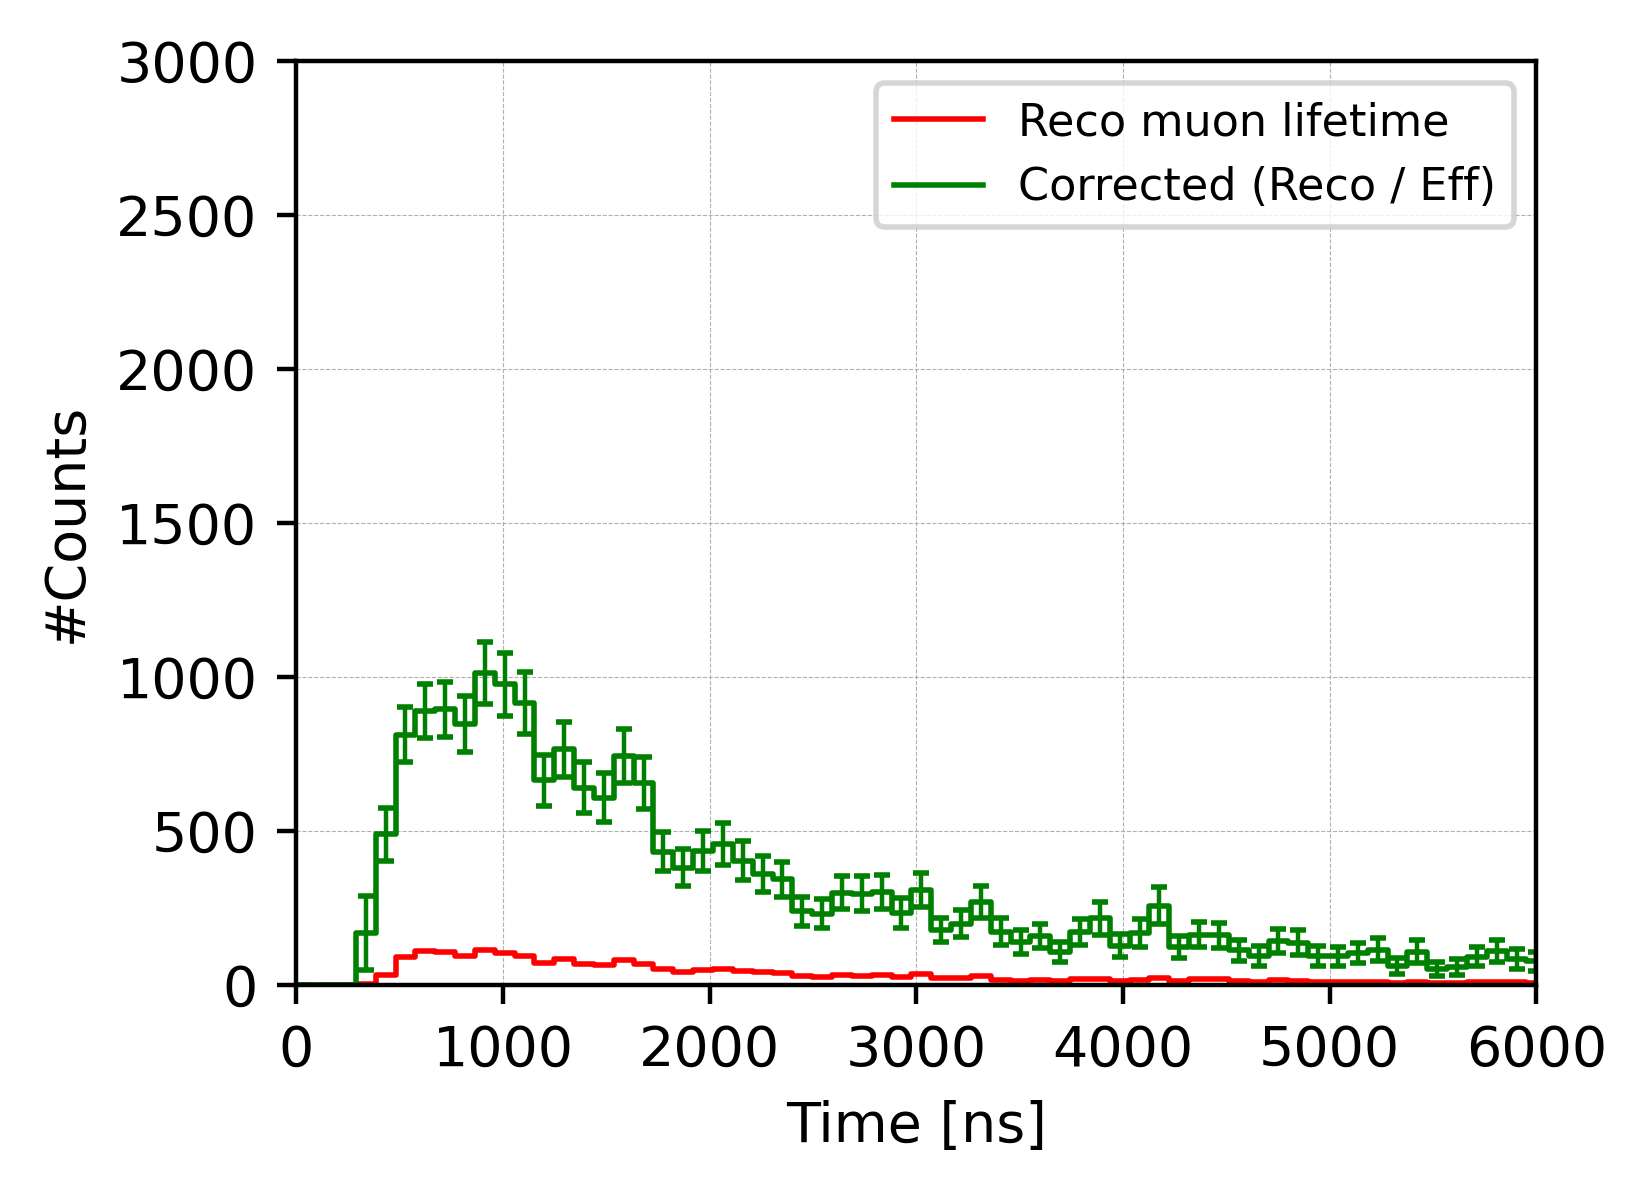

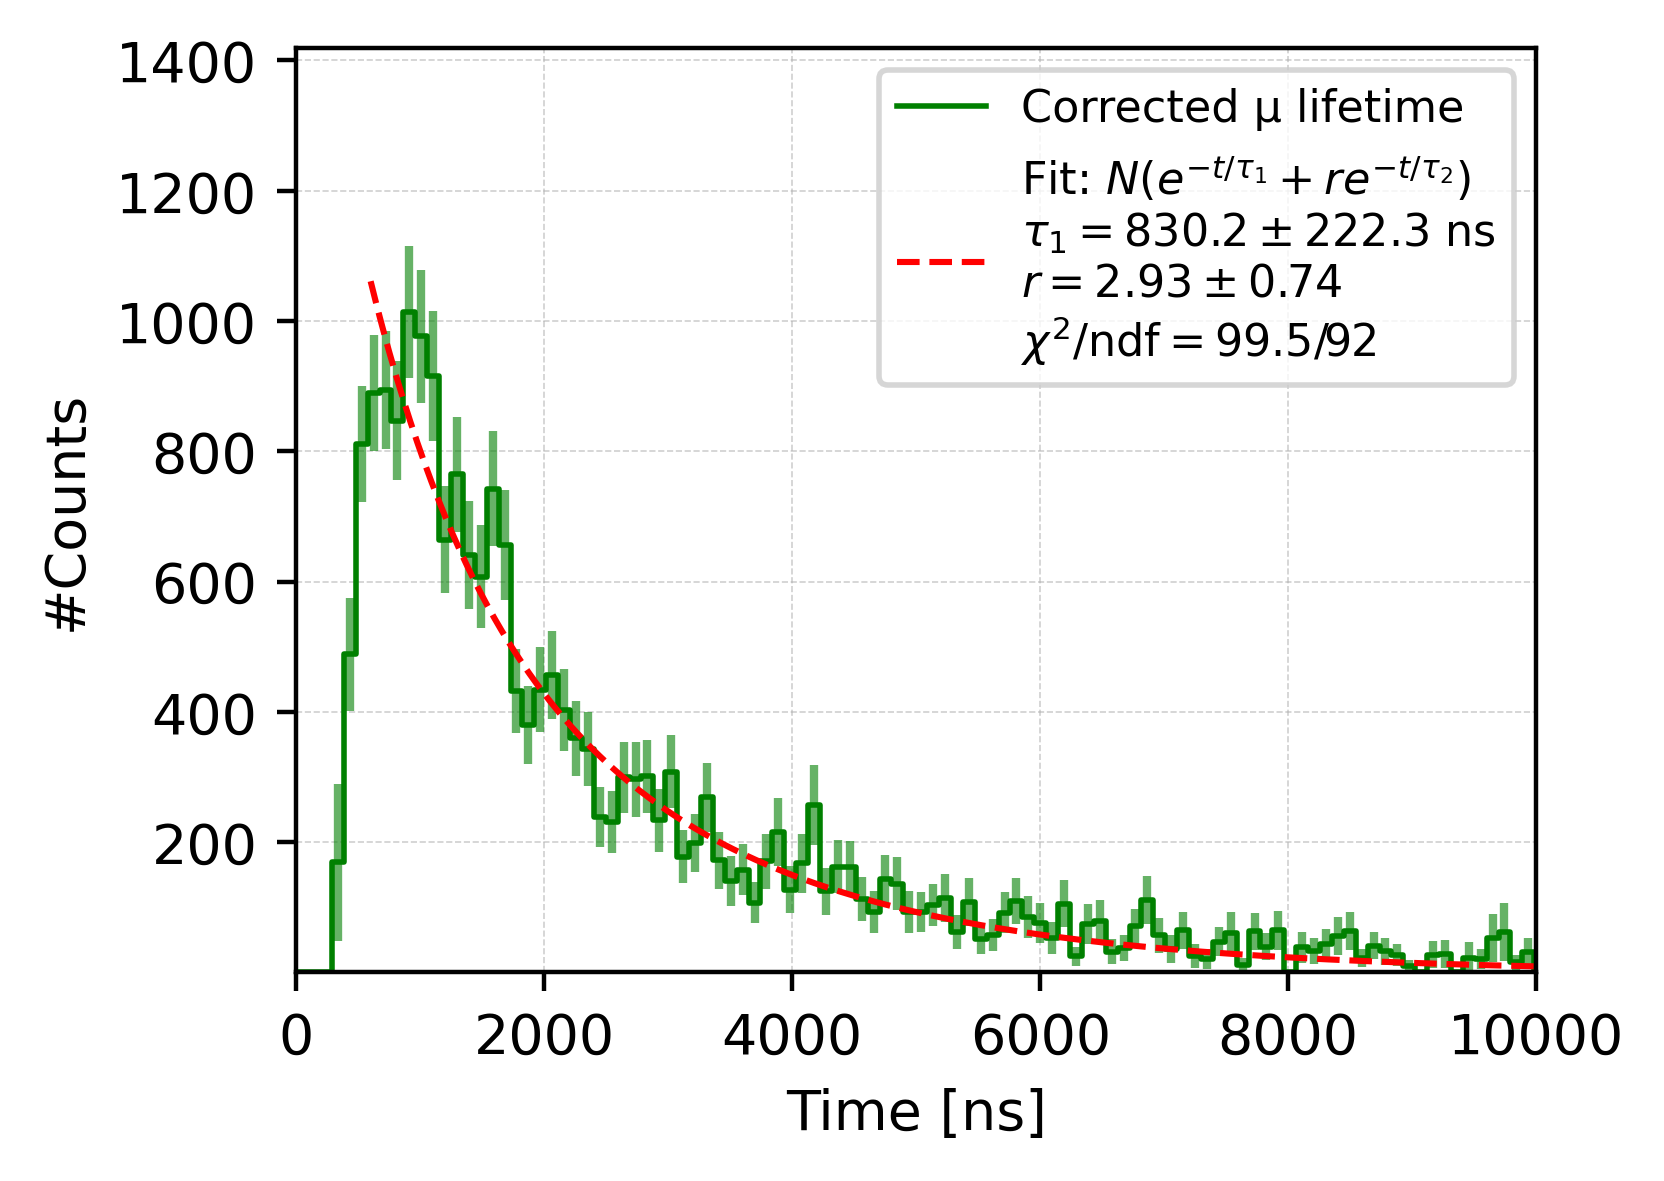


Fit summary:
N: (6916.172257774003, 1302.7765491080338)
tau1: (830.1720290824582, 222.25707716249622)
ratio: (2.925492778354295, 0.7407151532445059)
tau2: 2197.0
chi2: 99.51540197013763
ndf: 92
chi2_ndf: 1.0816891518493221


In [275]:
# --------------------------------------------------------------
# 1. Plot raw vs corrected histogram (your existing code)
# --------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

plt.step(bins, np.append(counts_reco, counts_reco[-1]),
         where='post', color='red', lw=1.0, label='Reco muon lifetime')

plt.step(bins, np.append(R_corr, R_corr[-1]),
         where='post', color='green', lw=1.0, label='Corrected (Reco / Eff)')

plt.errorbar(centers, R_corr, sigma_R_corr,
             fmt='none', ecolor='green', lw=0.8, capsize=1.5)

plt.xlim(0, 6000)
plt.ylim(0.0, 3000)
#plt.yscale("log")
plt.xlabel("Time [ns]")
plt.ylabel("#Counts")
plt.grid(ls='--', lw=0.2)
plt.legend(fontsize=8)
plt.show()


# --------------------------------------------------------------
# 2. Perform least-squares fit to corrected spectrum
# --------------------------------------------------------------
results = fit_double_exp(
    bin_edges=bins,
    y=R_corr,
    yerr=sigma_R_corr,
    fit_range=(600, 10000),   # adjust as needed
    tau2=2197.0
)

print("\nFit summary:")
for key, val in results.items():
    print(f"{key}: {val}")


<br />
<br />

### Apply new fitting function  (physics-motivated):


Fit results:
  N⁺        = 20213 ± 1800
  τ(μ⁻)     = 876.7 ± 242.0 ns
  χ²/ndf    = 83.7/75 = 1.12


/var/folders/c9/547_2pf11mv74b226lzvqwj00000gn/T/ipykernel_19247/874366363.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


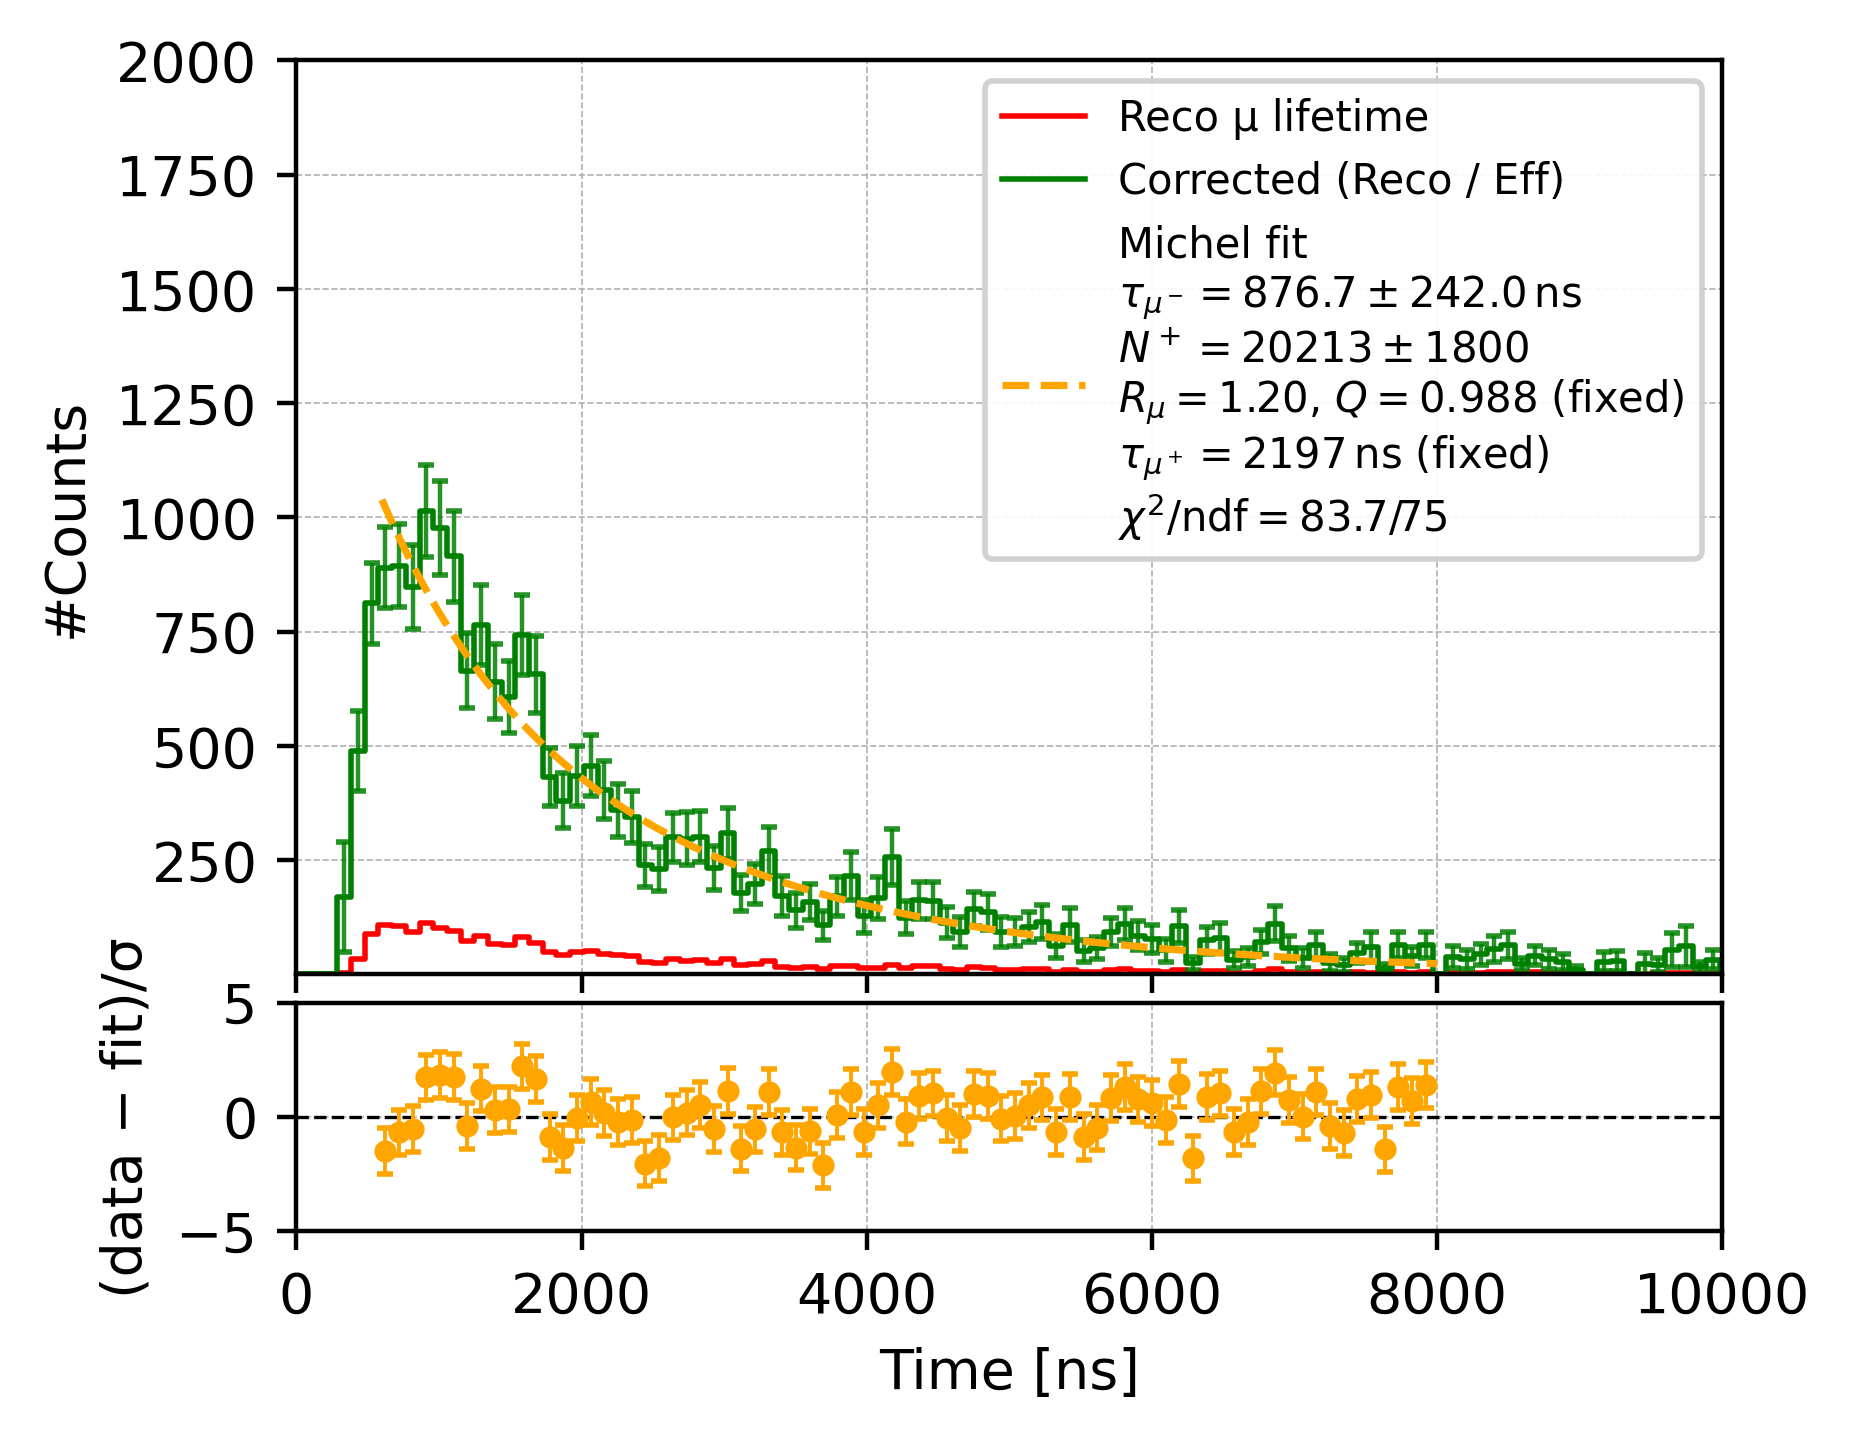

In [277]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Physics constants (FIXED)
# ============================================================
tau_mu_plus = 2197.0   # ns
Q = 0.988
R_mu = 1.2

# ============================================================
# Integrated Michel model (bin-integrated)
# ============================================================
def michel_integrated(bin_edges, N_plus, tau_mu_minus):
    """
    Bin-integrated Michel lifetime model.

    Returns expected counts per bin.
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    term_plus  = np.exp(-a / tau_mu_plus)  - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus) - np.exp(-b / tau_mu_minus)

    prefactor = (Q * tau_mu_minus) / (R_mu * tau_mu_plus)

    return N_plus * (term_plus + prefactor * term_minus)

# ============================================================
# Inputs assumed to exist from previous notebook cells
# ============================================================
# bins            : bin edges (length N+1)
# centers         : bin centers (length N)
# counts_reco     : reco histogram
# R_corr          : efficiency-corrected histogram
# sigma_R_corr    : uncertainties on R_corr

# ============================================================
# 1. Define CONTIGUOUS fit window (critical!)
# ============================================================
fit_range = (600, 8000)  # ns===============================================================

mask_window = (
    (centers >= fit_range[0]) &
    (centers <= fit_range[1])
)

idx = np.where(mask_window)[0]
if len(idx) < 2:
    raise RuntimeError("Fit window too small or empty.")

i0, i1 = idx[0], idx[-1]

# Slice CONTIGUOUS bins
edges_fit = bins[i0 : i1 + 2]         # N+1
y_fit     = R_corr[i0 : i1 + 1]        # N
sigma_fit = sigma_R_corr[i0 : i1 + 1]  # N

# Safety check (now always true)
assert len(edges_fit) == len(y_fit) + 1

# Down-weight invalid bins instead of removing them
valid = (y_fit > 0) & np.isfinite(y_fit)
sigma_fit = np.where(valid, sigma_fit, 1e9)

# ============================================================
# 2. Perform χ² fit
# ============================================================
N0 = np.sum(y_fit[valid])
tau_minus_0 = 600.0  # ns

popt, pcov = curve_fit(
    michel_integrated,
    edges_fit, y_fit,
    p0=[N0, tau_minus_0],
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=([0.0, 50.0], [np.inf, 3000.0])
)

N_fit, tau_mu_minus_fit = popt
N_err, tau_mu_minus_err = np.sqrt(np.diag(pcov))

# χ² / ndf
y_model_fit = michel_integrated(edges_fit, *popt)
chi2 = np.sum(((y_fit - y_model_fit) / sigma_fit) ** 2)
ndf  = len(y_fit) - len(popt)

print("\nFit results:")
print(f"  N⁺        = {N_fit:.0f} ± {N_err:.0f}")
print(f"  τ(μ⁻)     = {tau_mu_minus_fit:.1f} ± {tau_mu_minus_err:.1f} ns")
print(f"  χ²/ndf    = {chi2:.1f}/{ndf} = {chi2/ndf:.2f}")

# ============================================================
# 3. Plot: data + fit + residuals
# ============================================================
fig, (ax, ax_resid) = plt.subplots(
    2, 1, figsize=(4.6, 3.8), dpi=400,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05},
    sharex=True
)

# ------------------------------------------------------------
# Main panel
# ------------------------------------------------------------
ax.step(
    bins, np.append(counts_reco, counts_reco[-1]),
    where='post', color='red', lw=1.0,
    label='Reco μ lifetime'
)

ax.step(
    bins, np.append(R_corr, R_corr[-1]),
    where='post', color='green', lw=1.0,
    label='Corrected (Reco / Eff)'
)

ax.errorbar(
    centers, R_corr, yerr=sigma_R_corr,
    fmt='none', ecolor='green',
    elinewidth=0.8, capsize=1.5, alpha=0.85
)

# Smooth fitted curve (visual only)
bin_width = bins[1] - bins[0]
x_smooth = np.linspace(fit_range[0], fit_range[1], 600)

y_smooth = (
    (N_fit / tau_mu_plus) * np.exp(-x_smooth / tau_mu_plus)
    + (N_fit * Q / (R_mu * tau_mu_plus)) * np.exp(-x_smooth / tau_mu_minus_fit)
) * bin_width

ax.plot(
    x_smooth, y_smooth,
    color='orange', ls='--', lw=1.3,
    label=(
        r"Michel fit" "\n"
        + rf"$\tau_{{\mu^-}} = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$" "\n"
        + rf"$N^+ = {N_fit:.0f} \pm {N_err:.0f}$" "\n"
        + rf"$R_\mu = {R_mu:.2f}$, $Q = {Q:.3f}$ (fixed)" "\n"
        + rf"$\tau_{{\mu^+}} = {tau_mu_plus:.0f}\,\mathrm{{ns}}$ (fixed)" "\n"
        + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"
    )
)

#ax.set_yscale('log')
ax.set_ylim(0.9, 2000)
ax.set_ylabel('#Counts')
ax.set_xlim(0.0, 10000)
ax.grid(ls='--', lw=0.3)
ax.legend(fontsize=7.5, framealpha=0.9)

# ------------------------------------------------------------
# Residuals panel (ONLY fit region)
# ------------------------------------------------------------
pulls = (y_fit - y_model_fit) / sigma_fit

ax_resid.axhline(0, color='black', lw=0.6, ls='--')
ax_resid.errorbar(
    centers[i0 : i1 + 1], pulls,
    yerr=np.ones_like(pulls),
    fmt='o', color='orange',
    markersize=3, elinewidth=0.7, capsize=1.5
)

ax_resid.set_xlabel('Time [ns]')
ax_resid.set_ylabel('(data − fit)/σ')
ax_resid.set_ylim(-5, 5)
ax_resid.grid(ls='--', lw=0.3)

plt.tight_layout()
plt.show()


<br />
<br />
<br />
<br />

### Comparison of different measurements:

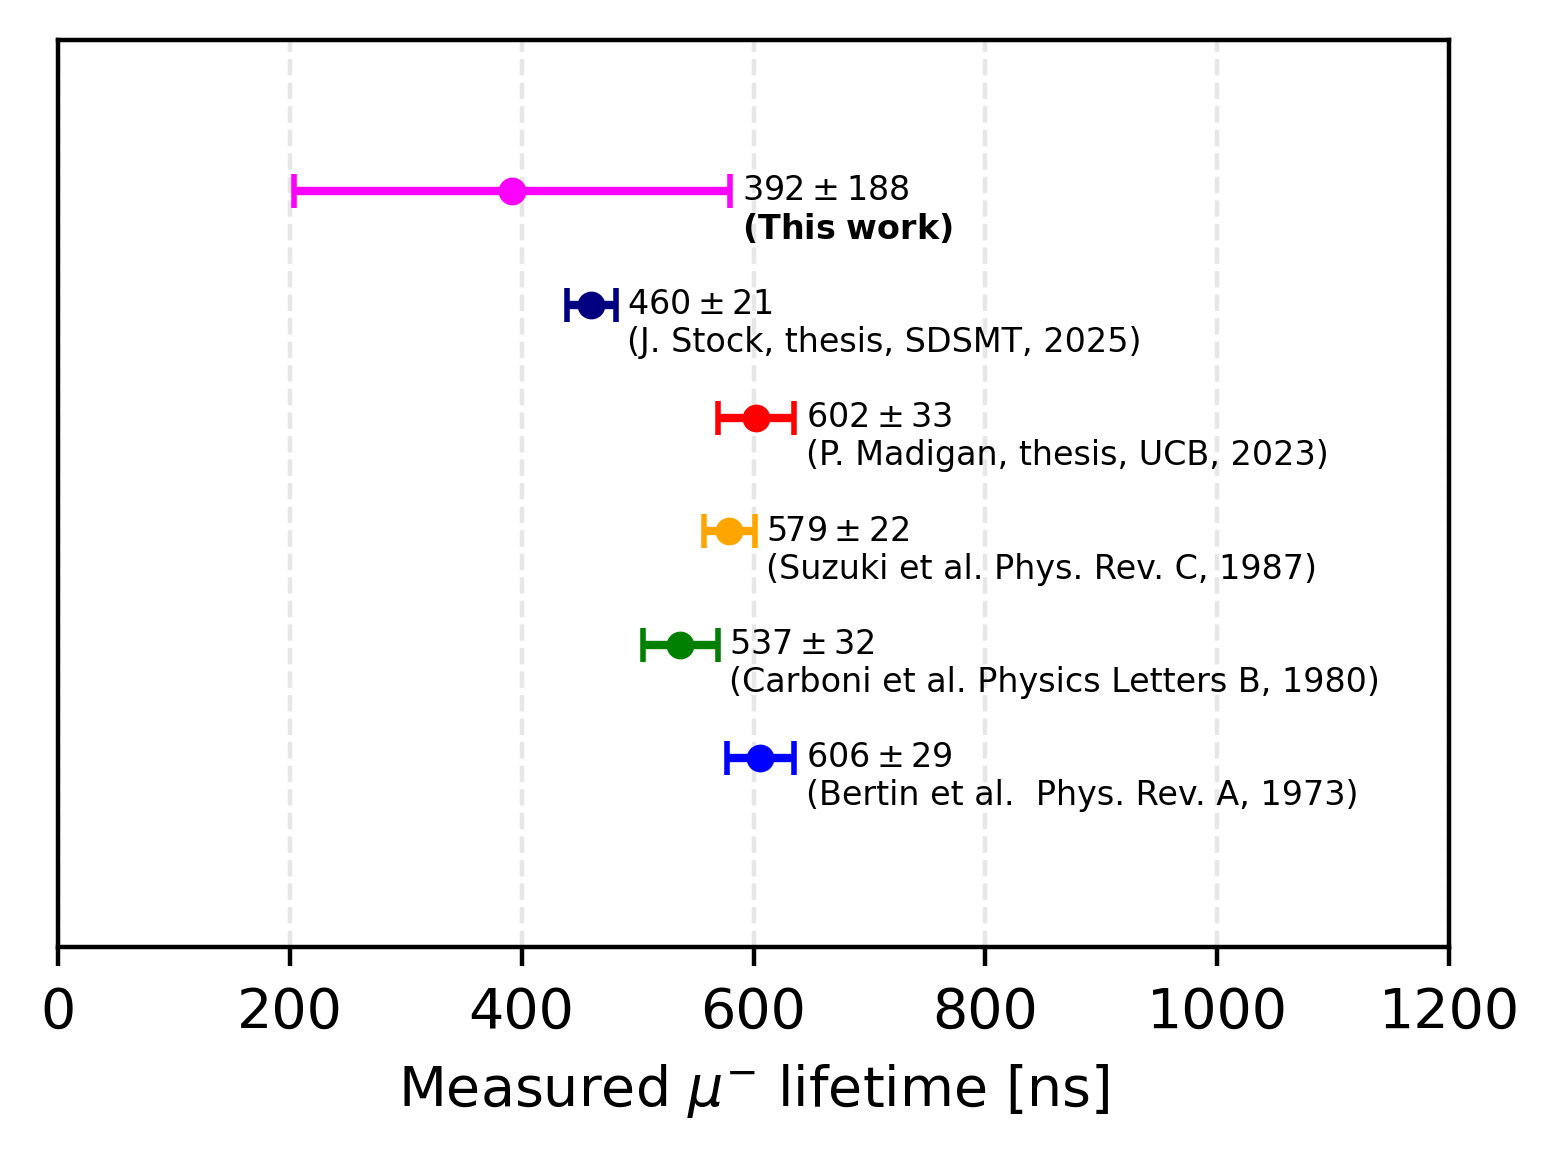

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Measurements
# -----------------------

values = np.array([606, 537, 579, 602, 460, 392])
errors = np.array([29, 32, 22, 33, 21, 188])

y_positions = np.array([0.5, 2, 3.5, 5, 6.5, 8])

labels = [
    "$606 \\pm 29$\n(Bertin et al.  Phys. Rev. A, 1973)",
    "$537 \\pm 32$\n(Carboni et al. Physics Letters B, 1980)",
    "$579 \\pm 22$\n(Suzuki et al. Phys. Rev. C, 1987)",
    "$602 \\pm 33$\n(P. Madigan, thesis, UCB, 2023)",
    "$460 \\pm 21$\n(J. Stock, thesis, SDSMT, 2025)",
    
    "$392 \\pm 188$\n$\\mathbf{(This\ work)}$"
]


# Point colors
point_colors = ["blue", "green", "orange", "red", "navy", "magenta"]

# (dx, dy) offsets for each label
label_offsets = [
    (39, -0.25),
    (42, -0.25),
    (32, -0.25),
    (43, -0.25),
    (31, -0.25),
    (198, -0.25)
]

plt.figure(figsize=(4, 3), dpi=400)

for val, err, y, lab, col, (dx, dy) in zip(values, errors, y_positions, labels, point_colors, label_offsets):
    
    plt.errorbar(
        val, y, xerr=err,
        fmt='o', color=col,
        ecolor=col, capsize=3, markersize=4
    )
    
    # Multi-line label + size control
    plt.text(
        val + dx, y + dy,
        lab,
        fontsize=6,         # <<< set label size here
        va='center'
    )

plt.xlabel(r"Measured $\mu^{-}$ lifetime [ns]")
plt.xlim(0, 1200)
plt.yticks([])
plt.ylim(-2, 10)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()
